In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_parquet("final_time_split_data.parquet")
df

,pickup_hour,PULocationID,trip_count
0,2015-01-01 00:00:00,3,1
1,2015-01-01 00:00:00,4,180
2,2015-01-01 00:00:00,7,119
3,2015-01-01 00:00:00,8,1
4,2015-01-01 00:00:00,12,5
...,...,...,...
2192388,2016-12-31 23:00:00,261,46
2192389,2016-12-31 23:00:00,262,149
2192390,2016-12-31 23:00:00,263,300
2192391,2016-12-31 23:00:00,264,258


In [3]:
df["trip_count"].max()

np.int64(3483)

In [4]:
df[df["trip_count"] > 3400]

,pickup_hour,PULocationID,trip_count
2031647,2016-11-06 01:00:00,79,3483


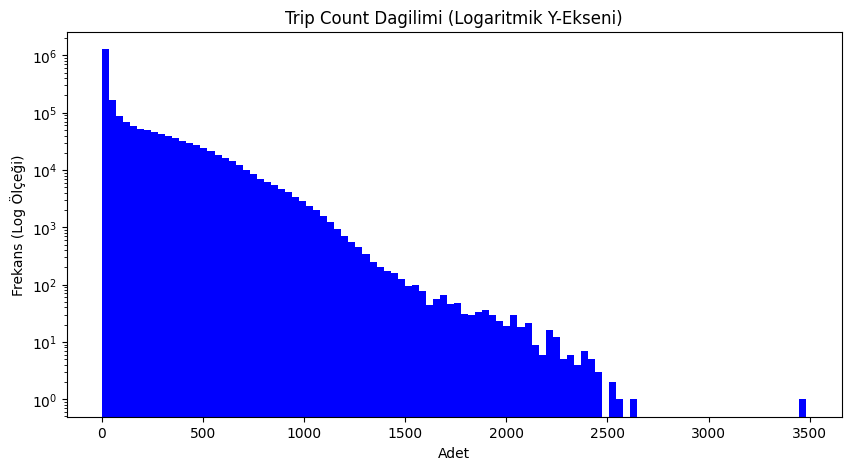

In [5]:
# Logaritmic histogram
plt.figure(figsize=(10, 5))
plt.hist(df['trip_count'], bins=100, color='blue')
plt.yscale('log') # Y eksenini logaritmik yapar
plt.title('Trip Count Dagilimi (Logaritmik Y-Ekseni)')
plt.xlabel('Adet')
plt.ylabel('Frekans (Log Ölçeği)')
plt.show()

#! Aşağıdaki grafik elimizdeki verinin dağılımını göstermektedir.

In [6]:
df[df["trip_count"] > 2500]

,pickup_hour,PULocationID,trip_count
72290,2015-01-25 01:00:00,79,2511
92387,2015-02-01 01:00:00,79,2539
114479,2015-02-08 02:00:00,79,2552
2031647,2016-11-06 01:00:00,79,3483
2031688,2016-11-06 01:00:00,148,2627


In [7]:
df[df["trip_count"] == 0]

,pickup_hour,PULocationID,trip_count


Sonuç: PULocationID 79 bölgesi East Village kısmını gösteriyor. Burası barların ve gençlerin yoğun olduğu bir yer. Bu yerde gece saatinde taksi sayısının fazla olması normaldir. Lakin, "2016-11-06" tarihinde New York'ta saatler geriye alınmış. Yani aslında o tarihte gece 1 iki kere yaşanmış. O yüzden o satırdaki trip count lar ikiye bölünmeli.

In [8]:
df[df["pickup_hour"] == "2016-11-06 01:00:00"]

,pickup_hour,PULocationID,trip_count
2031610,2016-11-06 01:00:00,4,419
2031611,2016-11-06 01:00:00,7,86
2031612,2016-11-06 01:00:00,12,3
2031613,2016-11-06 01:00:00,13,41
2031614,2016-11-06 01:00:00,14,5
...,...,...,...
2031759,2016-11-06 01:00:00,261,87
2031760,2016-11-06 01:00:00,262,103
2031761,2016-11-06 01:00:00,263,414
2031762,2016-11-06 01:00:00,264,311


In [9]:
df[df["pickup_hour"] == "2016-11-06 01:00:00"].max()

pickup_hour     2016-11-06 01:00:00
PULocationID                    265
trip_count                     3483
dtype: object

In [10]:
df.loc[df["pickup_hour"] == "2016-11-06 01:00:00", "trip_count"] //= 2

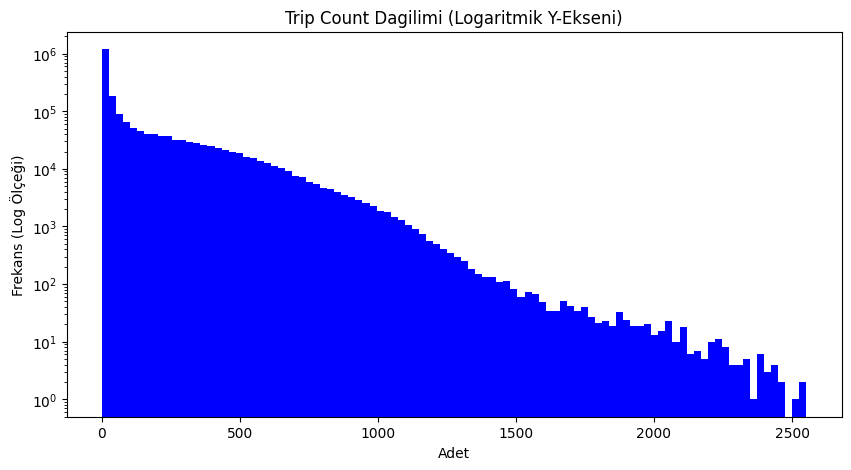

In [11]:
# Logaritmic histogram
plt.figure(figsize=(10, 5))
plt.hist(df['trip_count'], bins=100, color='blue')
plt.yscale('log') # Y eksenini logaritmik yapar
plt.title('Trip Count Dagilimi (Logaritmik Y-Ekseni)')
plt.xlabel('Adet')
plt.ylabel('Frekans (Log Ölçeği)')
plt.show()

#! Aşağıdaki grafik elimizdeki verinin dağılımını göstermektedir.

In [12]:
df[df["trip_count"] > 2500]

,pickup_hour,PULocationID,trip_count
72290,2015-01-25 01:00:00,79,2511
92387,2015-02-01 01:00:00,79,2539
114479,2015-02-08 02:00:00,79,2552


Önemli: Bu kısım bir anomali gibi gözükse de aslında bu tablo cumartesi gecesini, pazar sabahına bağlayan gecede East Village (barlar bölgesi) taxi çağrılıma sayısnı gösteriyor. Bunun yüksek olması konum açısından gayet normal ve model eğitiminde East Village bölgesi için tahmin yaparken işimize çok yarayacak.

Daha önce saatler geriye alındığı için veri düzenlemesi yapmıştım. Aynısı saatler ileriye alındığı için de olabilir ve bunun için spesifik iki tarih incelemeliyim.

In [13]:
df[df["pickup_hour"] == "2015-03-08 02:00:00"]

,pickup_hour,PULocationID,trip_count
202662,2015-03-08 02:00:00,41,1
202663,2015-03-08 02:00:00,43,1
202664,2015-03-08 02:00:00,48,11
202665,2015-03-08 02:00:00,50,6
202666,2015-03-08 02:00:00,68,6
202667,2015-03-08 02:00:00,74,1
202668,2015-03-08 02:00:00,79,9
202669,2015-03-08 02:00:00,82,1
202670,2015-03-08 02:00:00,87,1
202671,2015-03-08 02:00:00,90,4


In [14]:
df[df["pickup_hour"] == "2016-03-13 02:00:00"]

,pickup_hour,PULocationID,trip_count
1324861,2016-03-13 02:00:00,48,3
1324862,2016-03-13 02:00:00,50,1
1324863,2016-03-13 02:00:00,79,5
1324864,2016-03-13 02:00:00,113,1
1324865,2016-03-13 02:00:00,114,2
1324866,2016-03-13 02:00:00,125,1
1324867,2016-03-13 02:00:00,137,1
1324868,2016-03-13 02:00:00,144,2
1324869,2016-03-13 02:00:00,148,2
1324870,2016-03-13 02:00:00,158,1


Bu tarihlerde saatler ileriye alındığı için hatalı veriler var. 200 den fazla bölgenin verisi de eksik.

In [15]:
locations = df["PULocationID"].unique()
first_date = df["pickup_hour"].min()
last_date = df["pickup_hour"].max()

In [16]:
flawless_time_series = pd.date_range(start=first_date, end=last_date, freq='h')
flawless_time_series

DatetimeIndex(['2015-01-01 00:00:00', '2015-01-01 01:00:00',
               '2015-01-01 02:00:00', '2015-01-01 03:00:00',
               '2015-01-01 04:00:00', '2015-01-01 05:00:00',
               '2015-01-01 06:00:00', '2015-01-01 07:00:00',
               '2015-01-01 08:00:00', '2015-01-01 09:00:00',
               ...
               '2016-12-31 14:00:00', '2016-12-31 15:00:00',
               '2016-12-31 16:00:00', '2016-12-31 17:00:00',
               '2016-12-31 18:00:00', '2016-12-31 19:00:00',
               '2016-12-31 20:00:00', '2016-12-31 21:00:00',
               '2016-12-31 22:00:00', '2016-12-31 23:00:00'],
              dtype='datetime64[ns]', length=17544, freq='h')

In [17]:
master_index = pd.MultiIndex.from_product(
    [flawless_time_series, locations], 
    names=["pickup_hour", "PULocationID"]
)   # olması muhtemel tüm zaman ve mekan kombinasyonları    (kartezyen çarpım)

In [18]:
df = df.set_index(["pickup_hour", "PULocationID"]).reindex(master_index).reset_index()

DataFrame eskiden boşluk içeriyor idi. Şimdi o kısımlarda NaN değerler var.

In [19]:
df["trip_count"] = df["trip_count"].fillna(0)   # NaN değerleri 0 yap

In [20]:
df.loc[df["pickup_hour"] == "2015-03-08 02:00:00", "trip_count"] = 0
df.loc[df["pickup_hour"] == "2016-03-13 02:00:00", "trip_count"] = 0

Saatin ileri alındığı zamanlarda hatalı taksi verileri vardı. New York'ta hiç yaşanmamış saatlerde taksi sayısını sıfırladım.

### New Columns

In [21]:
df.dtypes

pickup_hour     datetime64[ns]
PULocationID             int64
trip_count             float64
dtype: object

In [22]:
#* Pandas'ın otomatik verdiği bileşenler
df["hour"] = df["pickup_hour"].dt.hour  # (0 - 23)
df["day_of_week"] = df["pickup_hour"].dt.dayofweek # (0 - 6)
df["month"] = df["pickup_hour"].dt.month    # (1 - 12)

In [23]:
df

,pickup_hour,PULocationID,trip_count,hour,day_of_week,month
0,2015-01-01 00:00:00,3,1.0,0,3,1
1,2015-01-01 00:00:00,4,180.0,0,3,1
2,2015-01-01 00:00:00,7,119.0,0,3,1
3,2015-01-01 00:00:00,8,1.0,0,3,1
4,2015-01-01 00:00:00,12,5.0,0,3,1
...,...,...,...,...,...,...
4649155,2016-12-31 23:00:00,44,0.0,23,5,12
4649156,2016-12-31 23:00:00,84,0.0,23,5,12
4649157,2016-12-31 23:00:00,110,0.0,23,5,12
4649158,2016-12-31 23:00:00,99,0.0,23,5,12


In [24]:
df[df["day_of_week"] == 6]  # Pazar günü

,pickup_hour,PULocationID,trip_count,hour,day_of_week,month
19080,2015-01-04 00:00:00,3,0.0,0,6,1
19081,2015-01-04 00:00:00,4,152.0,0,6,1
19082,2015-01-04 00:00:00,7,100.0,0,6,1
19083,2015-01-04 00:00:00,8,0.0,0,6,1
19084,2015-01-04 00:00:00,12,2.0,0,6,1
...,...,...,...,...,...,...
4610995,2016-12-25 23:00:00,44,0.0,23,6,12
4610996,2016-12-25 23:00:00,84,0.0,23,6,12
4610997,2016-12-25 23:00:00,110,0.0,23,6,12
4610998,2016-12-25 23:00:00,99,0.0,23,6,12


In [25]:
#* Boolean tarzı sütunlar
df["is_weekdays"] = df["day_of_week"].isin([0,1,2,3,4]).astype(int)
df["is_weekend"] = df["day_of_week"].isin([5,6]).astype(int)
df["is_working_hours"] = ((df["hour"] >= 8) & (df["hour"] <= 16)).astype(int)
df["is_business_hour"] = (df["is_working_hours"] & df["is_weekdays"]).astype(int)   # iş saati olması için hem haftaiçi olmalı hem de belli saatler arasında olmalı

Daha önce East Village gibi bölgelerde gece hayatı yaşandığını gördük, bunun için ayrı metrik çıkarabilirim.

In [26]:
friday_night = (df["day_of_week"] == 4) & (df["hour"] >= 22)
saturday = (df["day_of_week"] == 5) & ((df["hour"] >= 22) | df["hour"] <= 3)
sunday_night = (df["day_of_week"] == 6) & (df["hour"] <= 3)
df["is_night_life"] = (friday_night | saturday | sunday_night).astype(int)
df

,pickup_hour,PULocationID,trip_count,hour,day_of_week,month,is_weekdays,is_weekend,is_working_hours,is_business_hour,is_night_life
0,2015-01-01 00:00:00,3,1.0,0,3,1,1,0,0,0,0
1,2015-01-01 00:00:00,4,180.0,0,3,1,1,0,0,0,0
2,2015-01-01 00:00:00,7,119.0,0,3,1,1,0,0,0,0
3,2015-01-01 00:00:00,8,1.0,0,3,1,1,0,0,0,0
4,2015-01-01 00:00:00,12,5.0,0,3,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
4649155,2016-12-31 23:00:00,44,0.0,23,5,12,0,1,0,0,1
4649156,2016-12-31 23:00:00,84,0.0,23,5,12,0,1,0,0,1
4649157,2016-12-31 23:00:00,110,0.0,23,5,12,0,1,0,0,1
4649158,2016-12-31 23:00:00,99,0.0,23,5,12,0,1,0,0,1


In [27]:
df[df["is_business_hour"] == 1]

,pickup_hour,PULocationID,trip_count,hour,day_of_week,month,is_weekdays,is_weekend,is_working_hours,is_business_hour,is_night_life
2120,2015-01-01 08:00:00,3,0.0,8,3,1,1,0,1,1,0
2121,2015-01-01 08:00:00,4,40.0,8,3,1,1,0,1,1,0
2122,2015-01-01 08:00:00,7,57.0,8,3,1,1,0,1,1,0
2123,2015-01-01 08:00:00,8,0.0,8,3,1,1,0,1,1,0
2124,2015-01-01 08:00:00,12,1.0,8,3,1,1,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...
4640940,2016-12-30 16:00:00,44,0.0,16,4,12,1,0,1,1,0
4640941,2016-12-30 16:00:00,84,0.0,16,4,12,1,0,1,1,0
4640942,2016-12-30 16:00:00,110,0.0,16,4,12,1,0,1,1,0
4640943,2016-12-30 16:00:00,99,0.0,16,4,12,1,0,1,1,0


In [28]:
df.columns

Index(['pickup_hour', 'PULocationID', 'trip_count', 'hour', 'day_of_week',
       'month', 'is_weekdays', 'is_weekend', 'is_working_hours',
       'is_business_hour', 'is_night_life'],
      dtype='object')

In [29]:
#* Mevsimler
# 0 -> Spring   1 -> Summer 2-> Fall    3 -> Winter

# Spring -> 3 4 5
# Summer -> 6 7 8
# Fall ->   9 10 11
# Winter -> 12 1 2

spring_boolean = df["month"].isin([3,4,5])
summer_boolean = df["month"].isin([6,7,8])
fall_boolean = df["month"].isin([9,10,11])
winter_boolean = df["month"].isin([12,1,2])

df.loc[spring_boolean, "seasons"] = 0
df.loc[summer_boolean, "seasons"] = 1
df.loc[fall_boolean, "seasons"] = 2
df.loc[winter_boolean, "seasons"] = 3


In [30]:
df

,pickup_hour,PULocationID,trip_count,hour,day_of_week,month,is_weekdays,is_weekend,is_working_hours,is_business_hour,is_night_life,seasons
0,2015-01-01 00:00:00,3,1.0,0,3,1,1,0,0,0,0,3.0
1,2015-01-01 00:00:00,4,180.0,0,3,1,1,0,0,0,0,3.0
2,2015-01-01 00:00:00,7,119.0,0,3,1,1,0,0,0,0,3.0
3,2015-01-01 00:00:00,8,1.0,0,3,1,1,0,0,0,0,3.0
4,2015-01-01 00:00:00,12,5.0,0,3,1,1,0,0,0,0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...
4649155,2016-12-31 23:00:00,44,0.0,23,5,12,0,1,0,0,1,3.0
4649156,2016-12-31 23:00:00,84,0.0,23,5,12,0,1,0,0,1,3.0
4649157,2016-12-31 23:00:00,110,0.0,23,5,12,0,1,0,0,1,3.0
4649158,2016-12-31 23:00:00,99,0.0,23,5,12,0,1,0,0,1,3.0


- iş saati parçalara bölünmeli mi?

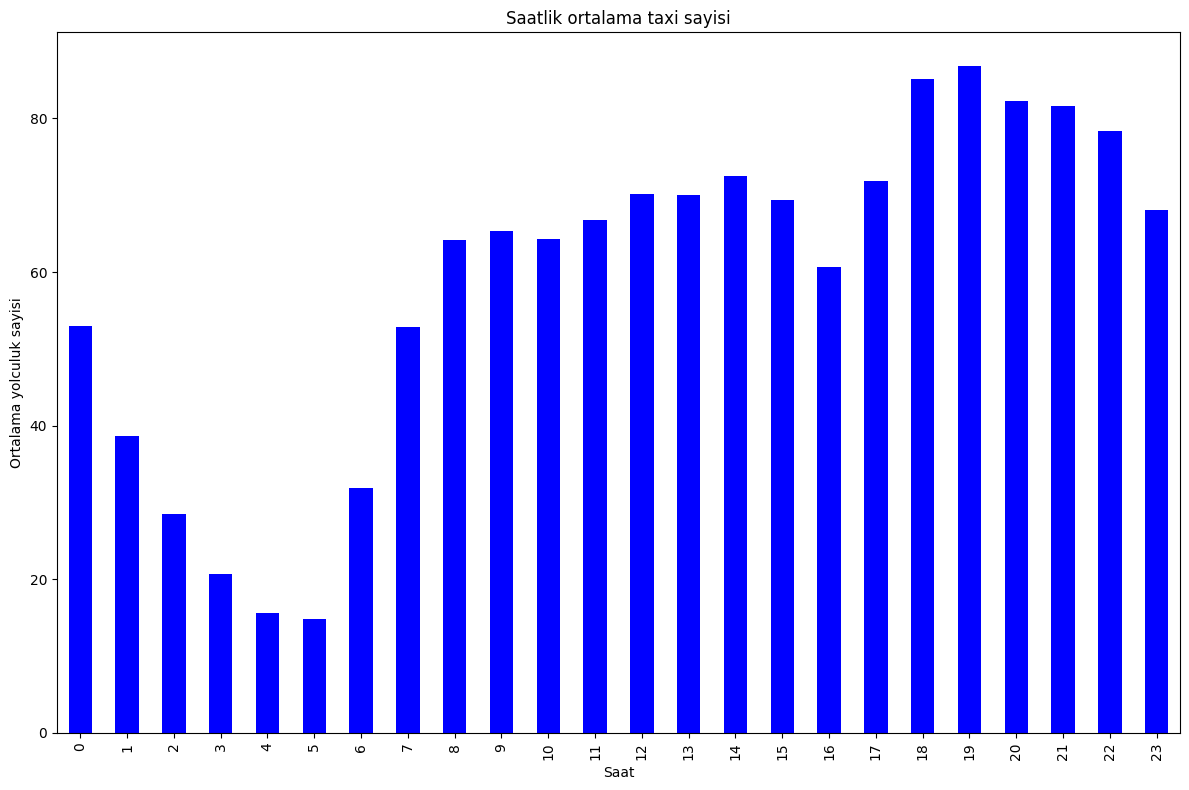

In [31]:
df.groupby("hour")["trip_count"].mean().plot(
    kind="bar",
    figsize=(12,8),
    color="blue", 
    title="Saatlik ortalama taxi sayisi"
)

plt.xticks(range(24), range(24))
plt.xlabel("Saat")
plt.ylabel("Ortalama yolculuk sayisi")
plt.tight_layout()
plt.show()

In [32]:
df["is_morning_rush"] = (((df["hour"] >= 7) & (df["hour"] <= 9)) & (df["is_weekdays"] == 1)).astype(int)
df["is_evening_rush"] = (((df["hour"] >= 17) & (df["hour"] <= 19)) & (df["is_weekdays"] == 1)).astype(int)
df["is_midday_break"] = (((df["hour"] >= 11) & (df["hour"] <= 13)) & (df["is_weekdays"] == 1)).astype(int)

In [33]:
df

,pickup_hour,PULocationID,trip_count,hour,day_of_week,month,is_weekdays,is_weekend,is_working_hours,is_business_hour,is_night_life,seasons,is_morning_rush,is_evening_rush,is_midday_break
0,2015-01-01 00:00:00,3,1.0,0,3,1,1,0,0,0,0,3.0,0,0,0
1,2015-01-01 00:00:00,4,180.0,0,3,1,1,0,0,0,0,3.0,0,0,0
2,2015-01-01 00:00:00,7,119.0,0,3,1,1,0,0,0,0,3.0,0,0,0
3,2015-01-01 00:00:00,8,1.0,0,3,1,1,0,0,0,0,3.0,0,0,0
4,2015-01-01 00:00:00,12,5.0,0,3,1,1,0,0,0,0,3.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4649155,2016-12-31 23:00:00,44,0.0,23,5,12,0,1,0,0,1,3.0,0,0,0
4649156,2016-12-31 23:00:00,84,0.0,23,5,12,0,1,0,0,1,3.0,0,0,0
4649157,2016-12-31 23:00:00,110,0.0,23,5,12,0,1,0,0,1,3.0,0,0,0
4649158,2016-12-31 23:00:00,99,0.0,23,5,12,0,1,0,0,1,3.0,0,0,0


In [34]:
df[df["is_morning_rush"] == 1]

,pickup_hour,PULocationID,trip_count,hour,day_of_week,month,is_weekdays,is_weekend,is_working_hours,is_business_hour,is_night_life,seasons,is_morning_rush,is_evening_rush,is_midday_break
1855,2015-01-01 07:00:00,3,0.0,7,3,1,1,0,0,0,0,3.0,1,0,0
1856,2015-01-01 07:00:00,4,40.0,7,3,1,1,0,0,0,0,3.0,1,0,0
1857,2015-01-01 07:00:00,7,74.0,7,3,1,1,0,0,0,0,3.0,1,0,0
1858,2015-01-01 07:00:00,8,0.0,7,3,1,1,0,0,0,0,3.0,1,0,0
1859,2015-01-01 07:00:00,12,1.0,7,3,1,1,0,0,0,0,3.0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4639085,2016-12-30 09:00:00,44,0.0,9,4,12,1,0,1,1,0,3.0,1,0,0
4639086,2016-12-30 09:00:00,84,0.0,9,4,12,1,0,1,1,0,3.0,1,0,0
4639087,2016-12-30 09:00:00,110,0.0,9,4,12,1,0,1,1,0,3.0,1,0,0
4639088,2016-12-30 09:00:00,99,0.0,9,4,12,1,0,1,1,0,3.0,1,0,0


In [35]:
df.columns

Index(['pickup_hour', 'PULocationID', 'trip_count', 'hour', 'day_of_week',
       'month', 'is_weekdays', 'is_weekend', 'is_working_hours',
       'is_business_hour', 'is_night_life', 'seasons', 'is_morning_rush',
       'is_evening_rush', 'is_midday_break'],
      dtype='object')

In [36]:
df.dtypes

pickup_hour         datetime64[ns]
PULocationID                 int64
trip_count                 float64
hour                         int32
day_of_week                  int32
month                        int32
is_weekdays                  int64
is_weekend                   int64
is_working_hours             int64
is_business_hour             int64
is_night_life                int64
seasons                    float64
is_morning_rush              int64
is_evening_rush              int64
is_midday_break              int64
dtype: object

In [37]:
df["seasons"] = df["seasons"].astype(int)

In [38]:
df.dtypes

pickup_hour         datetime64[ns]
PULocationID                 int64
trip_count                 float64
hour                         int32
day_of_week                  int32
month                        int32
is_weekdays                  int64
is_weekend                   int64
is_working_hours             int64
is_business_hour             int64
is_night_life                int64
seasons                      int64
is_morning_rush              int64
is_evening_rush              int64
is_midday_break              int64
dtype: object

"hour", "day_of_week", "month", "seasons" circular hale getirmeliyim

In [39]:
#* For hour
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

#* For day_of_week
df["day_of_week_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["day_of_week_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

#* For month
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

#* For seasons
df["seasons_sin"] = np.sin(2 * np.pi * df["seasons"] / 4)
df["seasons_cos"] = np.cos(2 * np.pi * df["seasons"] / 4)

ÖNEMLİ: Cyclical Feature Encoding Deep Learning ve Neural Networks kullanılacaksa iyi çalışır. Karar ağaçları tek seferde 1 feature işleyebildiğinden eskiden tek seferde işlediği veriyi şimdi 2 seferde işleyecek.

In [40]:
df

,pickup_hour,PULocationID,trip_count,hour,day_of_week,month,is_weekdays,is_weekend,is_working_hours,is_business_hour,...,is_evening_rush,is_midday_break,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,month_sin,month_cos,seasons_sin,seasons_cos
0,2015-01-01 00:00:00,3,1.0,0,3,1,1,0,0,0,...,0,0,0.000000,1.000000,0.433884,-0.900969,5.000000e-01,0.866025,-1.0,-1.836970e-16
1,2015-01-01 00:00:00,4,180.0,0,3,1,1,0,0,0,...,0,0,0.000000,1.000000,0.433884,-0.900969,5.000000e-01,0.866025,-1.0,-1.836970e-16
2,2015-01-01 00:00:00,7,119.0,0,3,1,1,0,0,0,...,0,0,0.000000,1.000000,0.433884,-0.900969,5.000000e-01,0.866025,-1.0,-1.836970e-16
3,2015-01-01 00:00:00,8,1.0,0,3,1,1,0,0,0,...,0,0,0.000000,1.000000,0.433884,-0.900969,5.000000e-01,0.866025,-1.0,-1.836970e-16
4,2015-01-01 00:00:00,12,5.0,0,3,1,1,0,0,0,...,0,0,0.000000,1.000000,0.433884,-0.900969,5.000000e-01,0.866025,-1.0,-1.836970e-16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4649155,2016-12-31 23:00:00,44,0.0,23,5,12,0,1,0,0,...,0,0,-0.258819,0.965926,-0.974928,-0.222521,-2.449294e-16,1.000000,-1.0,-1.836970e-16
4649156,2016-12-31 23:00:00,84,0.0,23,5,12,0,1,0,0,...,0,0,-0.258819,0.965926,-0.974928,-0.222521,-2.449294e-16,1.000000,-1.0,-1.836970e-16
4649157,2016-12-31 23:00:00,110,0.0,23,5,12,0,1,0,0,...,0,0,-0.258819,0.965926,-0.974928,-0.222521,-2.449294e-16,1.000000,-1.0,-1.836970e-16
4649158,2016-12-31 23:00:00,99,0.0,23,5,12,0,1,0,0,...,0,0,-0.258819,0.965926,-0.974928,-0.222521,-2.449294e-16,1.000000,-1.0,-1.836970e-16


In [41]:
df["trip_count"] = df["trip_count"].astype(int)
df

,pickup_hour,PULocationID,trip_count,hour,day_of_week,month,is_weekdays,is_weekend,is_working_hours,is_business_hour,...,is_evening_rush,is_midday_break,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,month_sin,month_cos,seasons_sin,seasons_cos
0,2015-01-01 00:00:00,3,1,0,3,1,1,0,0,0,...,0,0,0.000000,1.000000,0.433884,-0.900969,5.000000e-01,0.866025,-1.0,-1.836970e-16
1,2015-01-01 00:00:00,4,180,0,3,1,1,0,0,0,...,0,0,0.000000,1.000000,0.433884,-0.900969,5.000000e-01,0.866025,-1.0,-1.836970e-16
2,2015-01-01 00:00:00,7,119,0,3,1,1,0,0,0,...,0,0,0.000000,1.000000,0.433884,-0.900969,5.000000e-01,0.866025,-1.0,-1.836970e-16
3,2015-01-01 00:00:00,8,1,0,3,1,1,0,0,0,...,0,0,0.000000,1.000000,0.433884,-0.900969,5.000000e-01,0.866025,-1.0,-1.836970e-16
4,2015-01-01 00:00:00,12,5,0,3,1,1,0,0,0,...,0,0,0.000000,1.000000,0.433884,-0.900969,5.000000e-01,0.866025,-1.0,-1.836970e-16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4649155,2016-12-31 23:00:00,44,0,23,5,12,0,1,0,0,...,0,0,-0.258819,0.965926,-0.974928,-0.222521,-2.449294e-16,1.000000,-1.0,-1.836970e-16
4649156,2016-12-31 23:00:00,84,0,23,5,12,0,1,0,0,...,0,0,-0.258819,0.965926,-0.974928,-0.222521,-2.449294e-16,1.000000,-1.0,-1.836970e-16
4649157,2016-12-31 23:00:00,110,0,23,5,12,0,1,0,0,...,0,0,-0.258819,0.965926,-0.974928,-0.222521,-2.449294e-16,1.000000,-1.0,-1.836970e-16
4649158,2016-12-31 23:00:00,99,0,23,5,12,0,1,0,0,...,0,0,-0.258819,0.965926,-0.974928,-0.222521,-2.449294e-16,1.000000,-1.0,-1.836970e-16


In [42]:
df.head()

,pickup_hour,PULocationID,trip_count,hour,day_of_week,month,is_weekdays,is_weekend,is_working_hours,is_business_hour,...,is_evening_rush,is_midday_break,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,month_sin,month_cos,seasons_sin,seasons_cos
0,2015-01-01,3,1,0,3,1,1,0,0,0,...,0,0,0.0,1.0,0.433884,-0.900969,0.5,0.866025,-1.0,-1.836970e-16
1,2015-01-01,4,180,0,3,1,1,0,0,0,...,0,0,0.0,1.0,0.433884,-0.900969,0.5,0.866025,-1.0,-1.836970e-16
2,2015-01-01,7,119,0,3,1,1,0,0,0,...,0,0,0.0,1.0,0.433884,-0.900969,0.5,0.866025,-1.0,-1.836970e-16
3,2015-01-01,8,1,0,3,1,1,0,0,0,...,0,0,0.0,1.0,0.433884,-0.900969,0.5,0.866025,-1.0,-1.836970e-16
4,2015-01-01,12,5,0,3,1,1,0,0,0,...,0,0,0.0,1.0,0.433884,-0.900969,0.5,0.866025,-1.0,-1.836970e-16


In [43]:
df = df.sort_values(by=["PULocationID", "pickup_hour"])

In [44]:
df

,pickup_hour,PULocationID,trip_count,hour,day_of_week,month,is_weekdays,is_weekend,is_working_hours,is_business_hour,...,is_evening_rush,is_midday_break,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,month_sin,month_cos,seasons_sin,seasons_cos
233,2015-01-01 00:00:00,1,0,0,3,1,1,0,0,0,...,0,0,0.000000,1.000000,0.433884,-0.900969,5.000000e-01,0.866025,-1.0,-1.836970e-16
498,2015-01-01 01:00:00,1,0,1,3,1,1,0,0,0,...,0,0,0.258819,0.965926,0.433884,-0.900969,5.000000e-01,0.866025,-1.0,-1.836970e-16
763,2015-01-01 02:00:00,1,0,2,3,1,1,0,0,0,...,0,0,0.500000,0.866025,0.433884,-0.900969,5.000000e-01,0.866025,-1.0,-1.836970e-16
1028,2015-01-01 03:00:00,1,0,3,3,1,1,0,0,0,...,0,0,0.707107,0.707107,0.433884,-0.900969,5.000000e-01,0.866025,-1.0,-1.836970e-16
1293,2015-01-01 04:00:00,1,0,4,3,1,1,0,0,0,...,0,0,0.866025,0.500000,0.433884,-0.900969,5.000000e-01,0.866025,-1.0,-1.836970e-16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4648002,2016-12-31 19:00:00,265,4,19,5,12,0,1,0,0,...,0,0,-0.965926,0.258819,-0.974928,-0.222521,-2.449294e-16,1.000000,-1.0,-1.836970e-16
4648267,2016-12-31 20:00:00,265,5,20,5,12,0,1,0,0,...,0,0,-0.866025,0.500000,-0.974928,-0.222521,-2.449294e-16,1.000000,-1.0,-1.836970e-16
4648532,2016-12-31 21:00:00,265,2,21,5,12,0,1,0,0,...,0,0,-0.707107,0.707107,-0.974928,-0.222521,-2.449294e-16,1.000000,-1.0,-1.836970e-16
4648797,2016-12-31 22:00:00,265,2,22,5,12,0,1,0,0,...,0,0,-0.500000,0.866025,-0.974928,-0.222521,-2.449294e-16,1.000000,-1.0,-1.836970e-16


Bana rolling çalışırken garbage value üretmemesi için location ve zaman bazlı veriyi sıraladım.

In [45]:
df.reset_index(drop=True, inplace=True)
df

,pickup_hour,PULocationID,trip_count,hour,day_of_week,month,is_weekdays,is_weekend,is_working_hours,is_business_hour,...,is_evening_rush,is_midday_break,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,month_sin,month_cos,seasons_sin,seasons_cos
0,2015-01-01 00:00:00,1,0,0,3,1,1,0,0,0,...,0,0,0.000000,1.000000,0.433884,-0.900969,5.000000e-01,0.866025,-1.0,-1.836970e-16
1,2015-01-01 01:00:00,1,0,1,3,1,1,0,0,0,...,0,0,0.258819,0.965926,0.433884,-0.900969,5.000000e-01,0.866025,-1.0,-1.836970e-16
2,2015-01-01 02:00:00,1,0,2,3,1,1,0,0,0,...,0,0,0.500000,0.866025,0.433884,-0.900969,5.000000e-01,0.866025,-1.0,-1.836970e-16
3,2015-01-01 03:00:00,1,0,3,3,1,1,0,0,0,...,0,0,0.707107,0.707107,0.433884,-0.900969,5.000000e-01,0.866025,-1.0,-1.836970e-16
4,2015-01-01 04:00:00,1,0,4,3,1,1,0,0,0,...,0,0,0.866025,0.500000,0.433884,-0.900969,5.000000e-01,0.866025,-1.0,-1.836970e-16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4649155,2016-12-31 19:00:00,265,4,19,5,12,0,1,0,0,...,0,0,-0.965926,0.258819,-0.974928,-0.222521,-2.449294e-16,1.000000,-1.0,-1.836970e-16
4649156,2016-12-31 20:00:00,265,5,20,5,12,0,1,0,0,...,0,0,-0.866025,0.500000,-0.974928,-0.222521,-2.449294e-16,1.000000,-1.0,-1.836970e-16
4649157,2016-12-31 21:00:00,265,2,21,5,12,0,1,0,0,...,0,0,-0.707107,0.707107,-0.974928,-0.222521,-2.449294e-16,1.000000,-1.0,-1.836970e-16
4649158,2016-12-31 22:00:00,265,2,22,5,12,0,1,0,0,...,0,0,-0.500000,0.866025,-0.974928,-0.222521,-2.449294e-16,1.000000,-1.0,-1.836970e-16


### Lag Features

In [46]:
df[df["PULocationID"] == 132]   # JFK havalimanı

,pickup_hour,PULocationID,trip_count,hour,day_of_week,month,is_weekdays,is_weekend,is_working_hours,is_business_hour,...,is_evening_rush,is_midday_break,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,month_sin,month_cos,seasons_sin,seasons_cos
2298264,2015-01-01 00:00:00,132,217,0,3,1,1,0,0,0,...,0,0,0.000000,1.000000,0.433884,-0.900969,5.000000e-01,0.866025,-1.0,-1.836970e-16
2298265,2015-01-01 01:00:00,132,117,1,3,1,1,0,0,0,...,0,0,0.258819,0.965926,0.433884,-0.900969,5.000000e-01,0.866025,-1.0,-1.836970e-16
2298266,2015-01-01 02:00:00,132,5,2,3,1,1,0,0,0,...,0,0,0.500000,0.866025,0.433884,-0.900969,5.000000e-01,0.866025,-1.0,-1.836970e-16
2298267,2015-01-01 03:00:00,132,21,3,3,1,1,0,0,0,...,0,0,0.707107,0.707107,0.433884,-0.900969,5.000000e-01,0.866025,-1.0,-1.836970e-16
2298268,2015-01-01 04:00:00,132,24,4,3,1,1,0,0,0,...,0,0,0.866025,0.500000,0.433884,-0.900969,5.000000e-01,0.866025,-1.0,-1.836970e-16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2315803,2016-12-31 19:00:00,132,369,19,5,12,0,1,0,0,...,0,0,-0.965926,0.258819,-0.974928,-0.222521,-2.449294e-16,1.000000,-1.0,-1.836970e-16
2315804,2016-12-31 20:00:00,132,520,20,5,12,0,1,0,0,...,0,0,-0.866025,0.500000,-0.974928,-0.222521,-2.449294e-16,1.000000,-1.0,-1.836970e-16
2315805,2016-12-31 21:00:00,132,502,21,5,12,0,1,0,0,...,0,0,-0.707107,0.707107,-0.974928,-0.222521,-2.449294e-16,1.000000,-1.0,-1.836970e-16
2315806,2016-12-31 22:00:00,132,405,22,5,12,0,1,0,0,...,0,0,-0.500000,0.866025,-0.974928,-0.222521,-2.449294e-16,1.000000,-1.0,-1.836970e-16


In [47]:
df[df["PULocationID"] == 236]   # Manhattan Merkez

,pickup_hour,PULocationID,trip_count,hour,day_of_week,month,is_weekdays,is_weekend,is_working_hours,is_business_hour,...,is_evening_rush,is_midday_break,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,month_sin,month_cos,seasons_sin,seasons_cos
4122840,2015-01-01 00:00:00,236,633,0,3,1,1,0,0,0,...,0,0,0.000000,1.000000,0.433884,-0.900969,5.000000e-01,0.866025,-1.0,-1.836970e-16
4122841,2015-01-01 01:00:00,236,650,1,3,1,1,0,0,0,...,0,0,0.258819,0.965926,0.433884,-0.900969,5.000000e-01,0.866025,-1.0,-1.836970e-16
4122842,2015-01-01 02:00:00,236,519,2,3,1,1,0,0,0,...,0,0,0.500000,0.866025,0.433884,-0.900969,5.000000e-01,0.866025,-1.0,-1.836970e-16
4122843,2015-01-01 03:00:00,236,249,3,3,1,1,0,0,0,...,0,0,0.707107,0.707107,0.433884,-0.900969,5.000000e-01,0.866025,-1.0,-1.836970e-16
4122844,2015-01-01 04:00:00,236,137,4,3,1,1,0,0,0,...,0,0,0.866025,0.500000,0.433884,-0.900969,5.000000e-01,0.866025,-1.0,-1.836970e-16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4140379,2016-12-31 19:00:00,236,660,19,5,12,0,1,0,0,...,0,0,-0.965926,0.258819,-0.974928,-0.222521,-2.449294e-16,1.000000,-1.0,-1.836970e-16
4140380,2016-12-31 20:00:00,236,613,20,5,12,0,1,0,0,...,0,0,-0.866025,0.500000,-0.974928,-0.222521,-2.449294e-16,1.000000,-1.0,-1.836970e-16
4140381,2016-12-31 21:00:00,236,543,21,5,12,0,1,0,0,...,0,0,-0.707107,0.707107,-0.974928,-0.222521,-2.449294e-16,1.000000,-1.0,-1.836970e-16
4140382,2016-12-31 22:00:00,236,493,22,5,12,0,1,0,0,...,0,0,-0.500000,0.866025,-0.974928,-0.222521,-2.449294e-16,1.000000,-1.0,-1.836970e-16


In [48]:
past_request = df.groupby("PULocationID")["trip_count"].shift(1)

Farklı farklı lokasyonlar farklı saat verileri içeriyor. Konumların birbiri ile olan saat verileri karışmasın diye onları grupladım ve içinde bulunduğumuz anı ortalamaya katıp modelin kafasını karıştırmamak için 1 saat geri gittim.

In [49]:
#! Short term data analysis
df["rollin_mean_3h"] = past_request.rolling(window=3).mean()    # son 3 saating ortalaması
df["rolling_sum_6h"] = past_request.rolling(window=6).sum() # son 6 saatin toplamı
df["rolling_std_12h"] = past_request.rolling(window=12).std()   # son 12 saatteki standard sapma

In [50]:
#! Long term data analysis
df["rolling_mean_24h"] = past_request.rolling(window=24).mean() # son 24 saating ortalaması
df["rolling_mean_168h"] = past_request.rolling(window=168).mean()   # 1 haftanın ortalaması

#* LAG  # zaten 1 tane shift past_request için yapmıştım
df["lag_24h"] = past_request.shift(23)  # tam 1 gün önceki değer
df["lag_168h"] = past_request.shift(167)    # tam 1 hafta öncesi

In [51]:
df

,pickup_hour,PULocationID,trip_count,hour,day_of_week,month,is_weekdays,is_weekend,is_working_hours,is_business_hour,...,month_cos,seasons_sin,seasons_cos,rollin_mean_3h,rolling_sum_6h,rolling_std_12h,rolling_mean_24h,rolling_mean_168h,lag_24h,lag_168h
0,2015-01-01 00:00:00,1,0,0,3,1,1,0,0,0,...,0.866025,-1.0,-1.836970e-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-01 01:00:00,1,0,1,3,1,1,0,0,0,...,0.866025,-1.0,-1.836970e-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2015-01-01 02:00:00,1,0,2,3,1,1,0,0,0,...,0.866025,-1.0,-1.836970e-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2015-01-01 03:00:00,1,0,3,3,1,1,0,0,0,...,0.866025,-1.0,-1.836970e-16,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
4,2015-01-01 04:00:00,1,0,4,3,1,1,0,0,0,...,0.866025,-1.0,-1.836970e-16,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4649155,2016-12-31 19:00:00,265,4,19,5,12,0,1,0,0,...,1.000000,-1.0,-1.836970e-16,2.333333,12.0,1.055290,2.000000,1.517857,2.0,0.0
4649156,2016-12-31 20:00:00,265,5,20,5,12,0,1,0,0,...,1.000000,-1.0,-1.836970e-16,3.000000,13.0,1.087115,2.083333,1.541667,0.0,1.0
4649157,2016-12-31 21:00:00,265,2,21,5,12,0,1,0,0,...,1.000000,-1.0,-1.836970e-16,4.000000,16.0,1.240112,2.291667,1.565476,2.0,4.0
4649158,2016-12-31 22:00:00,265,2,22,5,12,0,1,0,0,...,1.000000,-1.0,-1.836970e-16,3.666667,18.0,1.240112,2.291667,1.553571,2.0,2.0


In [52]:
# Exponential Weighted Math
df["ewm_12h"] = past_request.groupby(df["PULocationID"]).ewm(span=12).mean().reset_index(level=0, drop=True)

Expoenential moving average ile weighted average yaptık. Bu ortalama tekniği yakın zamanlara, daha geçmişse göre daha fazla önem verir.

In [53]:
df

,pickup_hour,PULocationID,trip_count,hour,day_of_week,month,is_weekdays,is_weekend,is_working_hours,is_business_hour,...,seasons_sin,seasons_cos,rollin_mean_3h,rolling_sum_6h,rolling_std_12h,rolling_mean_24h,rolling_mean_168h,lag_24h,lag_168h,ewm_12h
0,2015-01-01 00:00:00,1,0,0,3,1,1,0,0,0,...,-1.0,-1.836970e-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-01 01:00:00,1,0,1,3,1,1,0,0,0,...,-1.0,-1.836970e-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
2,2015-01-01 02:00:00,1,0,2,3,1,1,0,0,0,...,-1.0,-1.836970e-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
3,2015-01-01 03:00:00,1,0,3,3,1,1,0,0,0,...,-1.0,-1.836970e-16,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
4,2015-01-01 04:00:00,1,0,4,3,1,1,0,0,0,...,-1.0,-1.836970e-16,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4649155,2016-12-31 19:00:00,265,4,19,5,12,0,1,0,0,...,-1.0,-1.836970e-16,2.333333,12.0,1.055290,2.000000,1.517857,2.0,0.0,2.122501
4649156,2016-12-31 20:00:00,265,5,20,5,12,0,1,0,0,...,-1.0,-1.836970e-16,3.000000,13.0,1.087115,2.083333,1.541667,0.0,1.0,2.411347
4649157,2016-12-31 21:00:00,265,2,21,5,12,0,1,0,0,...,-1.0,-1.836970e-16,4.000000,16.0,1.240112,2.291667,1.565476,2.0,4.0,2.809601
4649158,2016-12-31 22:00:00,265,2,22,5,12,0,1,0,0,...,-1.0,-1.836970e-16,3.666667,18.0,1.240112,2.291667,1.553571,2.0,2.0,2.685047


In [54]:
df = df.dropna().reset_index(drop=True)

In [55]:
df

,pickup_hour,PULocationID,trip_count,hour,day_of_week,month,is_weekdays,is_weekend,is_working_hours,is_business_hour,...,seasons_sin,seasons_cos,rollin_mean_3h,rolling_sum_6h,rolling_std_12h,rolling_mean_24h,rolling_mean_168h,lag_24h,lag_168h,ewm_12h
0,2015-01-08 00:00:00,1,0,0,3,1,1,0,0,0,...,-1.0,-1.836970e-16,0.000000,0.0,0.288675,0.166667,0.160714,0.0,0.0,0.076671
1,2015-01-08 01:00:00,1,0,1,3,1,1,0,0,0,...,-1.0,-1.836970e-16,0.000000,0.0,0.288675,0.166667,0.160714,0.0,0.0,0.064875
2,2015-01-08 02:00:00,1,0,2,3,1,1,0,0,0,...,-1.0,-1.836970e-16,0.000000,0.0,0.288675,0.166667,0.160714,0.0,0.0,0.054894
3,2015-01-08 03:00:00,1,0,3,3,1,1,0,0,0,...,-1.0,-1.836970e-16,0.000000,0.0,0.288675,0.166667,0.160714,1.0,0.0,0.046449
4,2015-01-08 04:00:00,1,0,4,3,1,1,0,0,0,...,-1.0,-1.836970e-16,0.000000,0.0,0.000000,0.125000,0.160714,0.0,0.0,0.039303
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4604635,2016-12-31 19:00:00,265,4,19,5,12,0,1,0,0,...,-1.0,-1.836970e-16,2.333333,12.0,1.055290,2.000000,1.517857,2.0,0.0,2.122501
4604636,2016-12-31 20:00:00,265,5,20,5,12,0,1,0,0,...,-1.0,-1.836970e-16,3.000000,13.0,1.087115,2.083333,1.541667,0.0,1.0,2.411347
4604637,2016-12-31 21:00:00,265,2,21,5,12,0,1,0,0,...,-1.0,-1.836970e-16,4.000000,16.0,1.240112,2.291667,1.565476,2.0,4.0,2.809601
4604638,2016-12-31 22:00:00,265,2,22,5,12,0,1,0,0,...,-1.0,-1.836970e-16,3.666667,18.0,1.240112,2.291667,1.553571,2.0,2.0,2.685047


In [56]:
df.columns

Index(['pickup_hour', 'PULocationID', 'trip_count', 'hour', 'day_of_week',
       'month', 'is_weekdays', 'is_weekend', 'is_working_hours',
       'is_business_hour', 'is_night_life', 'seasons', 'is_morning_rush',
       'is_evening_rush', 'is_midday_break', 'hour_sin', 'hour_cos',
       'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos',
       'seasons_sin', 'seasons_cos', 'rollin_mean_3h', 'rolling_sum_6h',
       'rolling_std_12h', 'rolling_mean_24h', 'rolling_mean_168h', 'lag_24h',
       'lag_168h', 'ewm_12h'],
      dtype='object')

In [57]:
df

,pickup_hour,PULocationID,trip_count,hour,day_of_week,month,is_weekdays,is_weekend,is_working_hours,is_business_hour,...,seasons_sin,seasons_cos,rollin_mean_3h,rolling_sum_6h,rolling_std_12h,rolling_mean_24h,rolling_mean_168h,lag_24h,lag_168h,ewm_12h
0,2015-01-08 00:00:00,1,0,0,3,1,1,0,0,0,...,-1.0,-1.836970e-16,0.000000,0.0,0.288675,0.166667,0.160714,0.0,0.0,0.076671
1,2015-01-08 01:00:00,1,0,1,3,1,1,0,0,0,...,-1.0,-1.836970e-16,0.000000,0.0,0.288675,0.166667,0.160714,0.0,0.0,0.064875
2,2015-01-08 02:00:00,1,0,2,3,1,1,0,0,0,...,-1.0,-1.836970e-16,0.000000,0.0,0.288675,0.166667,0.160714,0.0,0.0,0.054894
3,2015-01-08 03:00:00,1,0,3,3,1,1,0,0,0,...,-1.0,-1.836970e-16,0.000000,0.0,0.288675,0.166667,0.160714,1.0,0.0,0.046449
4,2015-01-08 04:00:00,1,0,4,3,1,1,0,0,0,...,-1.0,-1.836970e-16,0.000000,0.0,0.000000,0.125000,0.160714,0.0,0.0,0.039303
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4604635,2016-12-31 19:00:00,265,4,19,5,12,0,1,0,0,...,-1.0,-1.836970e-16,2.333333,12.0,1.055290,2.000000,1.517857,2.0,0.0,2.122501
4604636,2016-12-31 20:00:00,265,5,20,5,12,0,1,0,0,...,-1.0,-1.836970e-16,3.000000,13.0,1.087115,2.083333,1.541667,0.0,1.0,2.411347
4604637,2016-12-31 21:00:00,265,2,21,5,12,0,1,0,0,...,-1.0,-1.836970e-16,4.000000,16.0,1.240112,2.291667,1.565476,2.0,4.0,2.809601
4604638,2016-12-31 22:00:00,265,2,22,5,12,0,1,0,0,...,-1.0,-1.836970e-16,3.666667,18.0,1.240112,2.291667,1.553571,2.0,2.0,2.685047


### Train and Test Split

Ocak 2015 ve Ocak 2016 birbirnden farklı ve aralarında 12 ay olan zamanlar. Bu farkı kapatmak için month index kullanabilirim.

In [58]:
df["month_index"] = (df["pickup_hour"].dt.year - 2015) * 12 + df["month"]   # [1 - 24]
df

,pickup_hour,PULocationID,trip_count,hour,day_of_week,month,is_weekdays,is_weekend,is_working_hours,is_business_hour,...,seasons_cos,rollin_mean_3h,rolling_sum_6h,rolling_std_12h,rolling_mean_24h,rolling_mean_168h,lag_24h,lag_168h,ewm_12h,month_index
0,2015-01-08 00:00:00,1,0,0,3,1,1,0,0,0,...,-1.836970e-16,0.000000,0.0,0.288675,0.166667,0.160714,0.0,0.0,0.076671,1
1,2015-01-08 01:00:00,1,0,1,3,1,1,0,0,0,...,-1.836970e-16,0.000000,0.0,0.288675,0.166667,0.160714,0.0,0.0,0.064875,1
2,2015-01-08 02:00:00,1,0,2,3,1,1,0,0,0,...,-1.836970e-16,0.000000,0.0,0.288675,0.166667,0.160714,0.0,0.0,0.054894,1
3,2015-01-08 03:00:00,1,0,3,3,1,1,0,0,0,...,-1.836970e-16,0.000000,0.0,0.288675,0.166667,0.160714,1.0,0.0,0.046449,1
4,2015-01-08 04:00:00,1,0,4,3,1,1,0,0,0,...,-1.836970e-16,0.000000,0.0,0.000000,0.125000,0.160714,0.0,0.0,0.039303,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4604635,2016-12-31 19:00:00,265,4,19,5,12,0,1,0,0,...,-1.836970e-16,2.333333,12.0,1.055290,2.000000,1.517857,2.0,0.0,2.122501,24
4604636,2016-12-31 20:00:00,265,5,20,5,12,0,1,0,0,...,-1.836970e-16,3.000000,13.0,1.087115,2.083333,1.541667,0.0,1.0,2.411347,24
4604637,2016-12-31 21:00:00,265,2,21,5,12,0,1,0,0,...,-1.836970e-16,4.000000,16.0,1.240112,2.291667,1.565476,2.0,4.0,2.809601,24
4604638,2016-12-31 22:00:00,265,2,22,5,12,0,1,0,0,...,-1.836970e-16,3.666667,18.0,1.240112,2.291667,1.553571,2.0,2.0,2.685047,24


In [59]:
df.columns

Index(['pickup_hour', 'PULocationID', 'trip_count', 'hour', 'day_of_week',
       'month', 'is_weekdays', 'is_weekend', 'is_working_hours',
       'is_business_hour', 'is_night_life', 'seasons', 'is_morning_rush',
       'is_evening_rush', 'is_midday_break', 'hour_sin', 'hour_cos',
       'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos',
       'seasons_sin', 'seasons_cos', 'rollin_mean_3h', 'rolling_sum_6h',
       'rolling_std_12h', 'rolling_mean_24h', 'rolling_mean_168h', 'lag_24h',
       'lag_168h', 'ewm_12h', 'month_index'],
      dtype='object')

- correlation matrix

In [60]:
target_correlation_matrix = df.corr()
target_correlation_matrix

,pickup_hour,PULocationID,trip_count,hour,day_of_week,month,is_weekdays,is_weekend,is_working_hours,is_business_hour,...,seasons_cos,rollin_mean_3h,rolling_sum_6h,rolling_std_12h,rolling_mean_24h,rolling_mean_168h,lag_24h,lag_168h,ewm_12h,month_index
pickup_hour,1.000000e+00,-2.208428e-13,-0.029216,1.380016e-03,-1.186039e-03,4.830126e-01,7.386063e-04,-7.386063e-04,7.721229e-05,3.429155e-04,...,-3.119281e-01,-0.029756,-0.030773,-0.032638,-0.034067,-3.371788e-02,-0.029095,-0.027013,-0.032859,9.991154e-01
PULocationID,-2.208428e-13,1.000000e+00,0.142859,3.569045e-14,-6.566714e-15,8.172733e-14,4.401841e-14,1.336567e-14,2.168111e-14,8.021528e-15,...,-1.277919e-17,0.145392,0.150115,0.155097,0.166023,1.691170e-01,0.142893,0.142969,0.160173,-1.609140e-14
trip_count,-2.921642e-02,1.428590e-01,1.000000,1.118888e-01,1.025189e-02,-2.029766e-02,-1.642811e-03,1.642811e-03,4.026672e-02,3.612377e-02,...,1.719015e-02,0.923699,0.859367,0.747583,0.851373,8.431233e-01,0.939512,0.971008,0.871075,-2.916347e-02
hour,1.380016e-03,3.569045e-14,0.111889,1.000000e+00,5.123919e-19,7.967307e-17,7.343586e-19,1.751409e-20,5.595029e-02,4.368159e-02,...,-1.484949e-17,0.085773,0.053477,-0.056228,-0.000085,-5.800533e-05,0.111943,0.111719,0.029873,1.227005e-16
day_of_week,-1.186039e-03,-6.566714e-15,0.010252,5.123919e-19,1.000000e+00,-6.205333e-03,-7.898333e-01,7.898333e-01,6.097594e-19,-3.022366e-01,...,9.644412e-04,0.016732,0.021378,0.016475,0.031525,-7.377572e-05,0.021193,0.010134,0.024582,-1.303066e-03
month,4.830126e-01,8.172733e-14,-0.020298,7.967307e-17,-6.205333e-03,1.000000e+00,5.941541e-03,-5.941541e-03,4.751118e-17,2.273583e-03,...,-6.226579e-01,-0.020642,-0.021314,-0.027023,-0.023449,-2.187808e-02,-0.020002,-0.015705,-0.022709,4.839560e-01
is_weekdays,7.386063e-04,4.401841e-14,-0.001643,7.343586e-19,-7.898333e-01,5.941541e-03,1.000000e+00,-1.000000e+00,-4.097491e-19,3.826588e-01,...,-1.840877e-03,-0.008147,-0.011801,-0.005678,-0.020009,-4.823533e-05,-0.015986,-0.001746,-0.014236,1.060006e-03
is_weekend,-7.386063e-04,1.336567e-14,0.001643,1.751409e-20,7.898333e-01,-5.941541e-03,-1.000000e+00,1.000000e+00,2.989212e-19,-3.826588e-01,...,1.840877e-03,0.008147,0.011801,0.005678,0.020009,4.823533e-05,0.015986,0.001746,0.014236,-1.060006e-03
is_working_hours,7.721229e-05,2.168111e-14,0.040267,5.595029e-02,6.097594e-19,4.751118e-17,-4.097491e-19,2.989212e-19,1.000000e+00,7.807215e-01,...,-2.676259e-17,0.011982,-0.031215,0.055055,-0.000002,-2.507744e-07,0.040327,0.040130,-0.030495,8.850931e-17
is_business_hour,3.429155e-04,8.021528e-15,0.036124,4.368159e-02,-3.022366e-01,2.273583e-03,3.826588e-01,-3.826588e-01,7.807215e-01,1.000000e+00,...,-7.044276e-04,0.022836,-0.012551,0.038527,-0.007186,-2.080161e-05,0.030621,0.035891,-0.021232,4.056204e-04


In [61]:
target_correlation = target_correlation_matrix["trip_count"].abs().sort_values(ascending=False)
target_correlation

trip_count           1.000000
lag_168h             0.971008
lag_24h              0.939512
rollin_mean_3h       0.923699
ewm_12h              0.871075
rolling_sum_6h       0.859367
rolling_mean_24h     0.851373
rolling_mean_168h    0.843123
rolling_std_12h      0.747583
PULocationID         0.142859
hour                 0.111889
hour_sin             0.104866
is_evening_rush      0.047853
hour_cos             0.043068
is_working_hours     0.040267
is_business_hour     0.036124
pickup_hour          0.029216
month_index          0.029163
is_morning_rush      0.024582
month_sin            0.023430
month                0.020298
day_of_week_cos      0.020221
is_night_life        0.018852
seasons_cos          0.017190
is_midday_break      0.016839
day_of_week          0.010252
seasons              0.009037
seasons_sin          0.008152
month_cos            0.004198
day_of_week_sin      0.003251
is_weekend           0.001643
is_weekdays          0.001643
Name: trip_count, dtype: float64

In [62]:
print("#### Hedefle En Güçlü İlişkisi Olanlar #########")
print(target_correlation.head(15))

#### Hedefle En Güçlü İlişkisi Olanlar #########
trip_count           1.000000
lag_168h             0.971008
lag_24h              0.939512
rollin_mean_3h       0.923699
ewm_12h              0.871075
rolling_sum_6h       0.859367
rolling_mean_24h     0.851373
rolling_mean_168h    0.843123
rolling_std_12h      0.747583
PULocationID         0.142859
hour                 0.111889
hour_sin             0.104866
is_evening_rush      0.047853
hour_cos             0.043068
is_working_hours     0.040267
Name: trip_count, dtype: float64


In [63]:
df.groupby("is_weekend")["trip_count"].mean()

is_weekend
0    58.738817
1    59.308959
Name: trip_count, dtype: float64

In [64]:
df.groupby("is_night_life")["trip_count"].mean()

is_night_life
0    57.519936
1    65.225885
Name: trip_count, dtype: float64

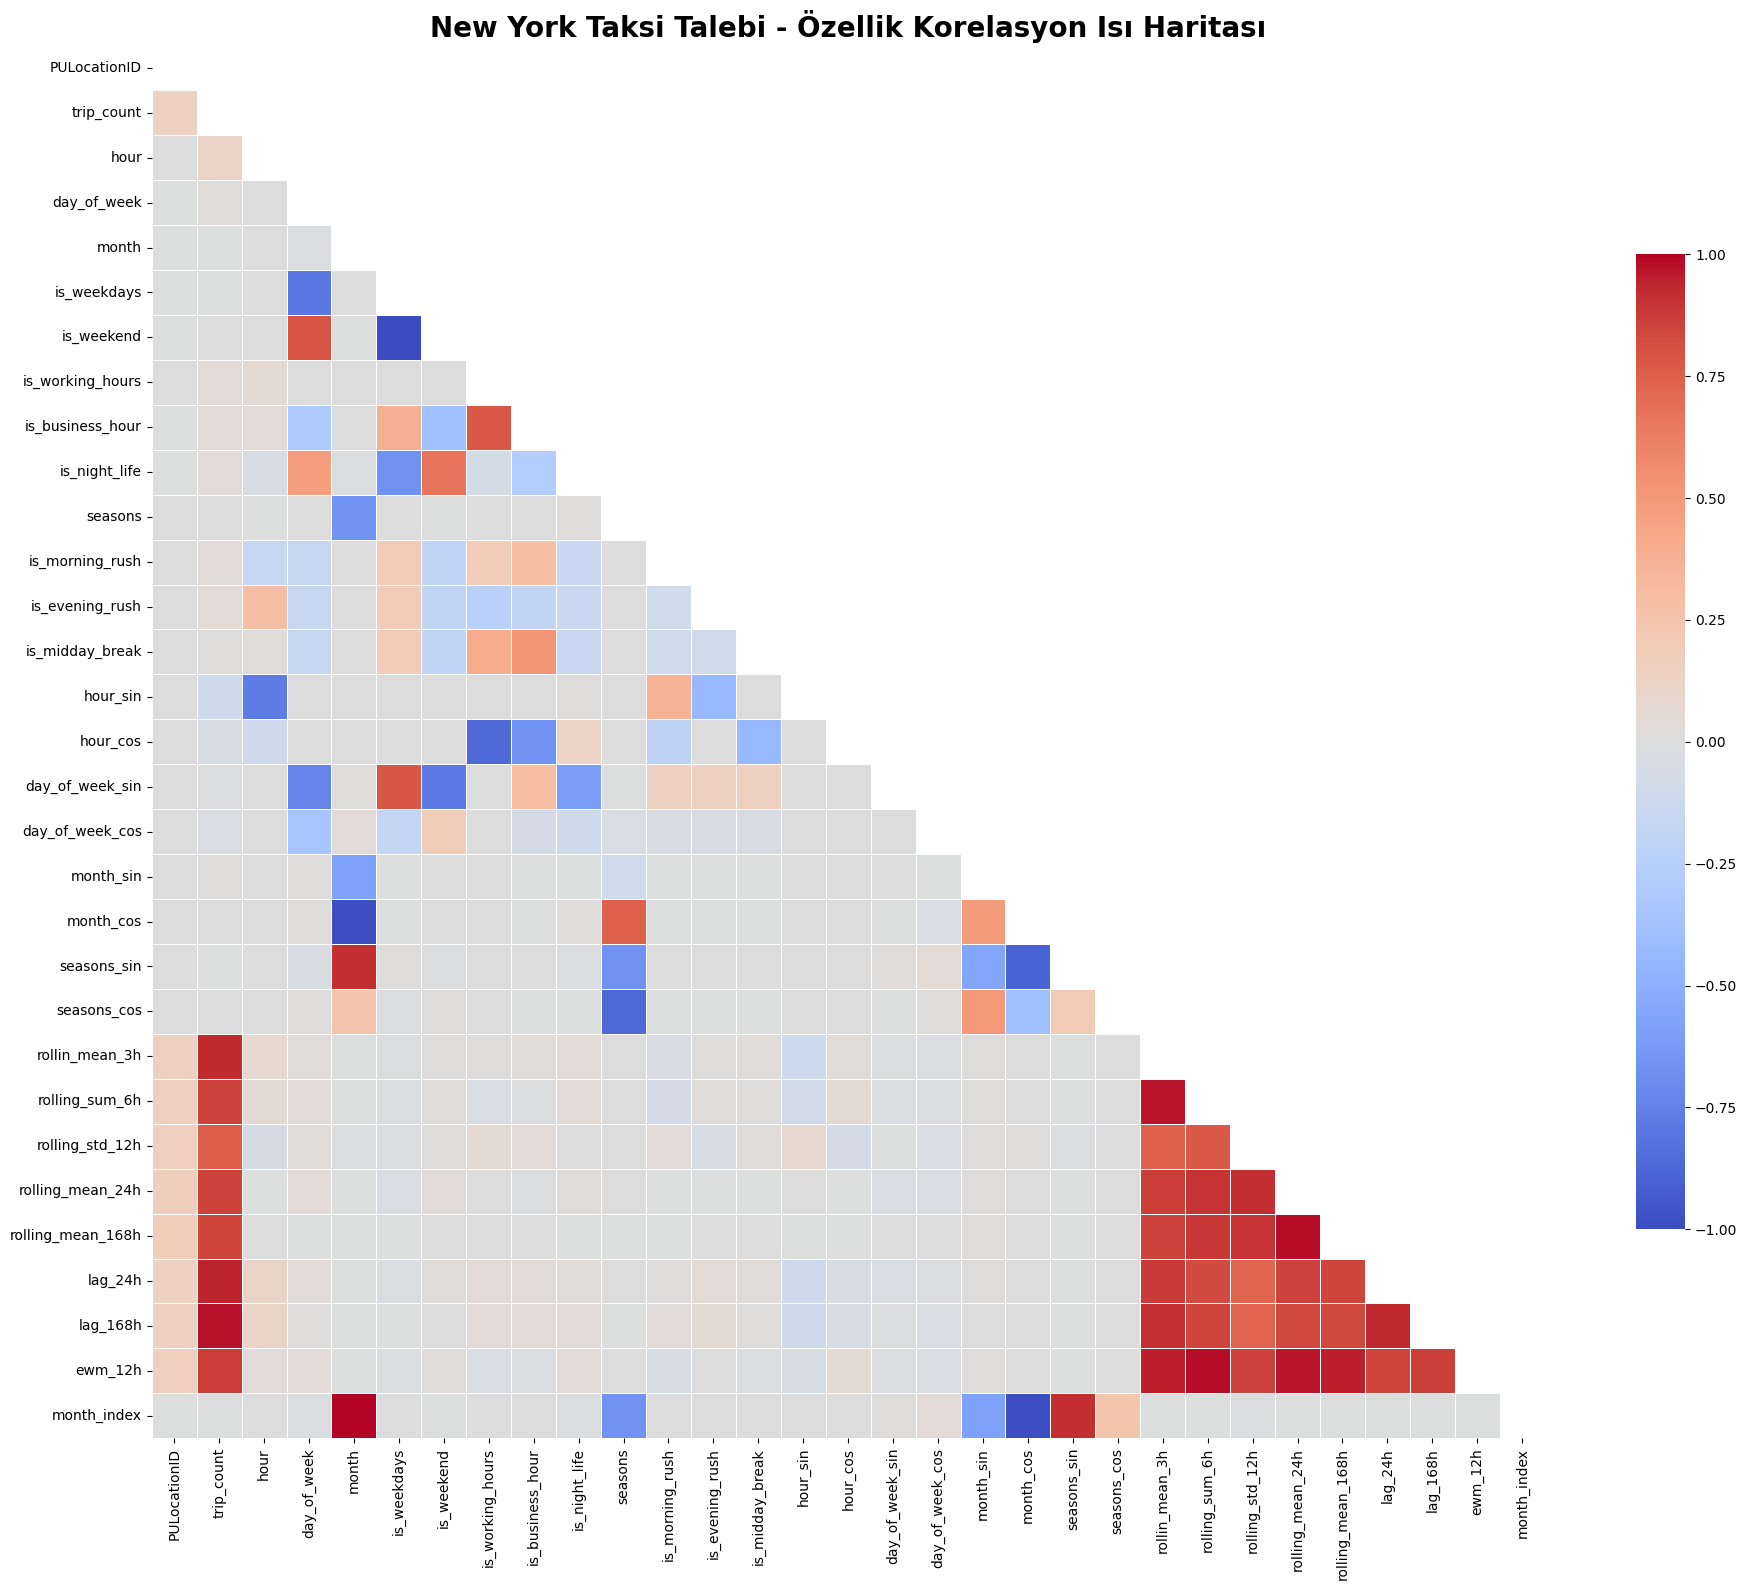

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

train_features = df[df["month_index"] <= 6].select_dtypes(include=[np.number])  # sadece sayısal özellikleri al

corr_matrix = train_features.corr() # correlation matrix
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))   # grafiğin üst üçgenini gizle

plt.figure(figsize=(20, 16))

sns.heatmap(corr_matrix, 
            mask=mask, 
            cmap="coolwarm", 
            vmax=1.0, vmin=-1.0, 
            center=0,
            annot=False, 
            square=True, 
            linewidths=.5, 
            cbar_kws={"shrink": .7})

plt.title("New York Taksi Talebi - Özellik Korelasyon Isı Haritası", fontsize=20, fontweight="bold")
plt.tight_layout()
plt.show()

In [66]:
target_correlation_for_lag_168h = target_correlation_matrix["lag_168h"].abs().sort_values(ascending=False)
target_correlation_for_lag_168h

lag_168h             1.000000
trip_count           0.971008
lag_24h              0.929329
rollin_mean_3h       0.905737
ewm_12h              0.857505
rolling_sum_6h       0.844961
rolling_mean_168h    0.843241
rolling_mean_24h     0.841023
rolling_std_12h      0.735698
PULocationID         0.142969
hour                 0.111719
hour_sin             0.104771
is_evening_rush      0.047898
hour_cos             0.042964
is_working_hours     0.040130
is_business_hour     0.035891
month_index          0.027402
pickup_hour          0.027013
is_morning_rush      0.024705
month_sin            0.021784
day_of_week_cos      0.019856
is_night_life        0.018859
seasons_cos          0.018072
is_midday_break      0.016632
month                0.015705
seasons              0.012156
day_of_week          0.010134
seasons_sin          0.005471
month_cos            0.004884
day_of_week_sin      0.003175
is_weekend           0.001746
is_weekdays          0.001746
Name: lag_168h, dtype: float64

In [67]:
df.columns

Index(['pickup_hour', 'PULocationID', 'trip_count', 'hour', 'day_of_week',
       'month', 'is_weekdays', 'is_weekend', 'is_working_hours',
       'is_business_hour', 'is_night_life', 'seasons', 'is_morning_rush',
       'is_evening_rush', 'is_midday_break', 'hour_sin', 'hour_cos',
       'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos',
       'seasons_sin', 'seasons_cos', 'rollin_mean_3h', 'rolling_sum_6h',
       'rolling_std_12h', 'rolling_mean_24h', 'rolling_mean_168h', 'lag_24h',
       'lag_168h', 'ewm_12h', 'month_index'],
      dtype='object')

In [68]:
df.drop(columns=["rolling_sum_6h", 
                 "rolling_mean_24h", 
                 "rolling_mean_168h"], inplace=True)

In [69]:
df.columns

Index(['pickup_hour', 'PULocationID', 'trip_count', 'hour', 'day_of_week',
       'month', 'is_weekdays', 'is_weekend', 'is_working_hours',
       'is_business_hour', 'is_night_life', 'seasons', 'is_morning_rush',
       'is_evening_rush', 'is_midday_break', 'hour_sin', 'hour_cos',
       'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos',
       'seasons_sin', 'seasons_cos', 'rollin_mean_3h', 'rolling_std_12h',
       'lag_24h', 'lag_168h', 'ewm_12h', 'month_index'],
      dtype='object')

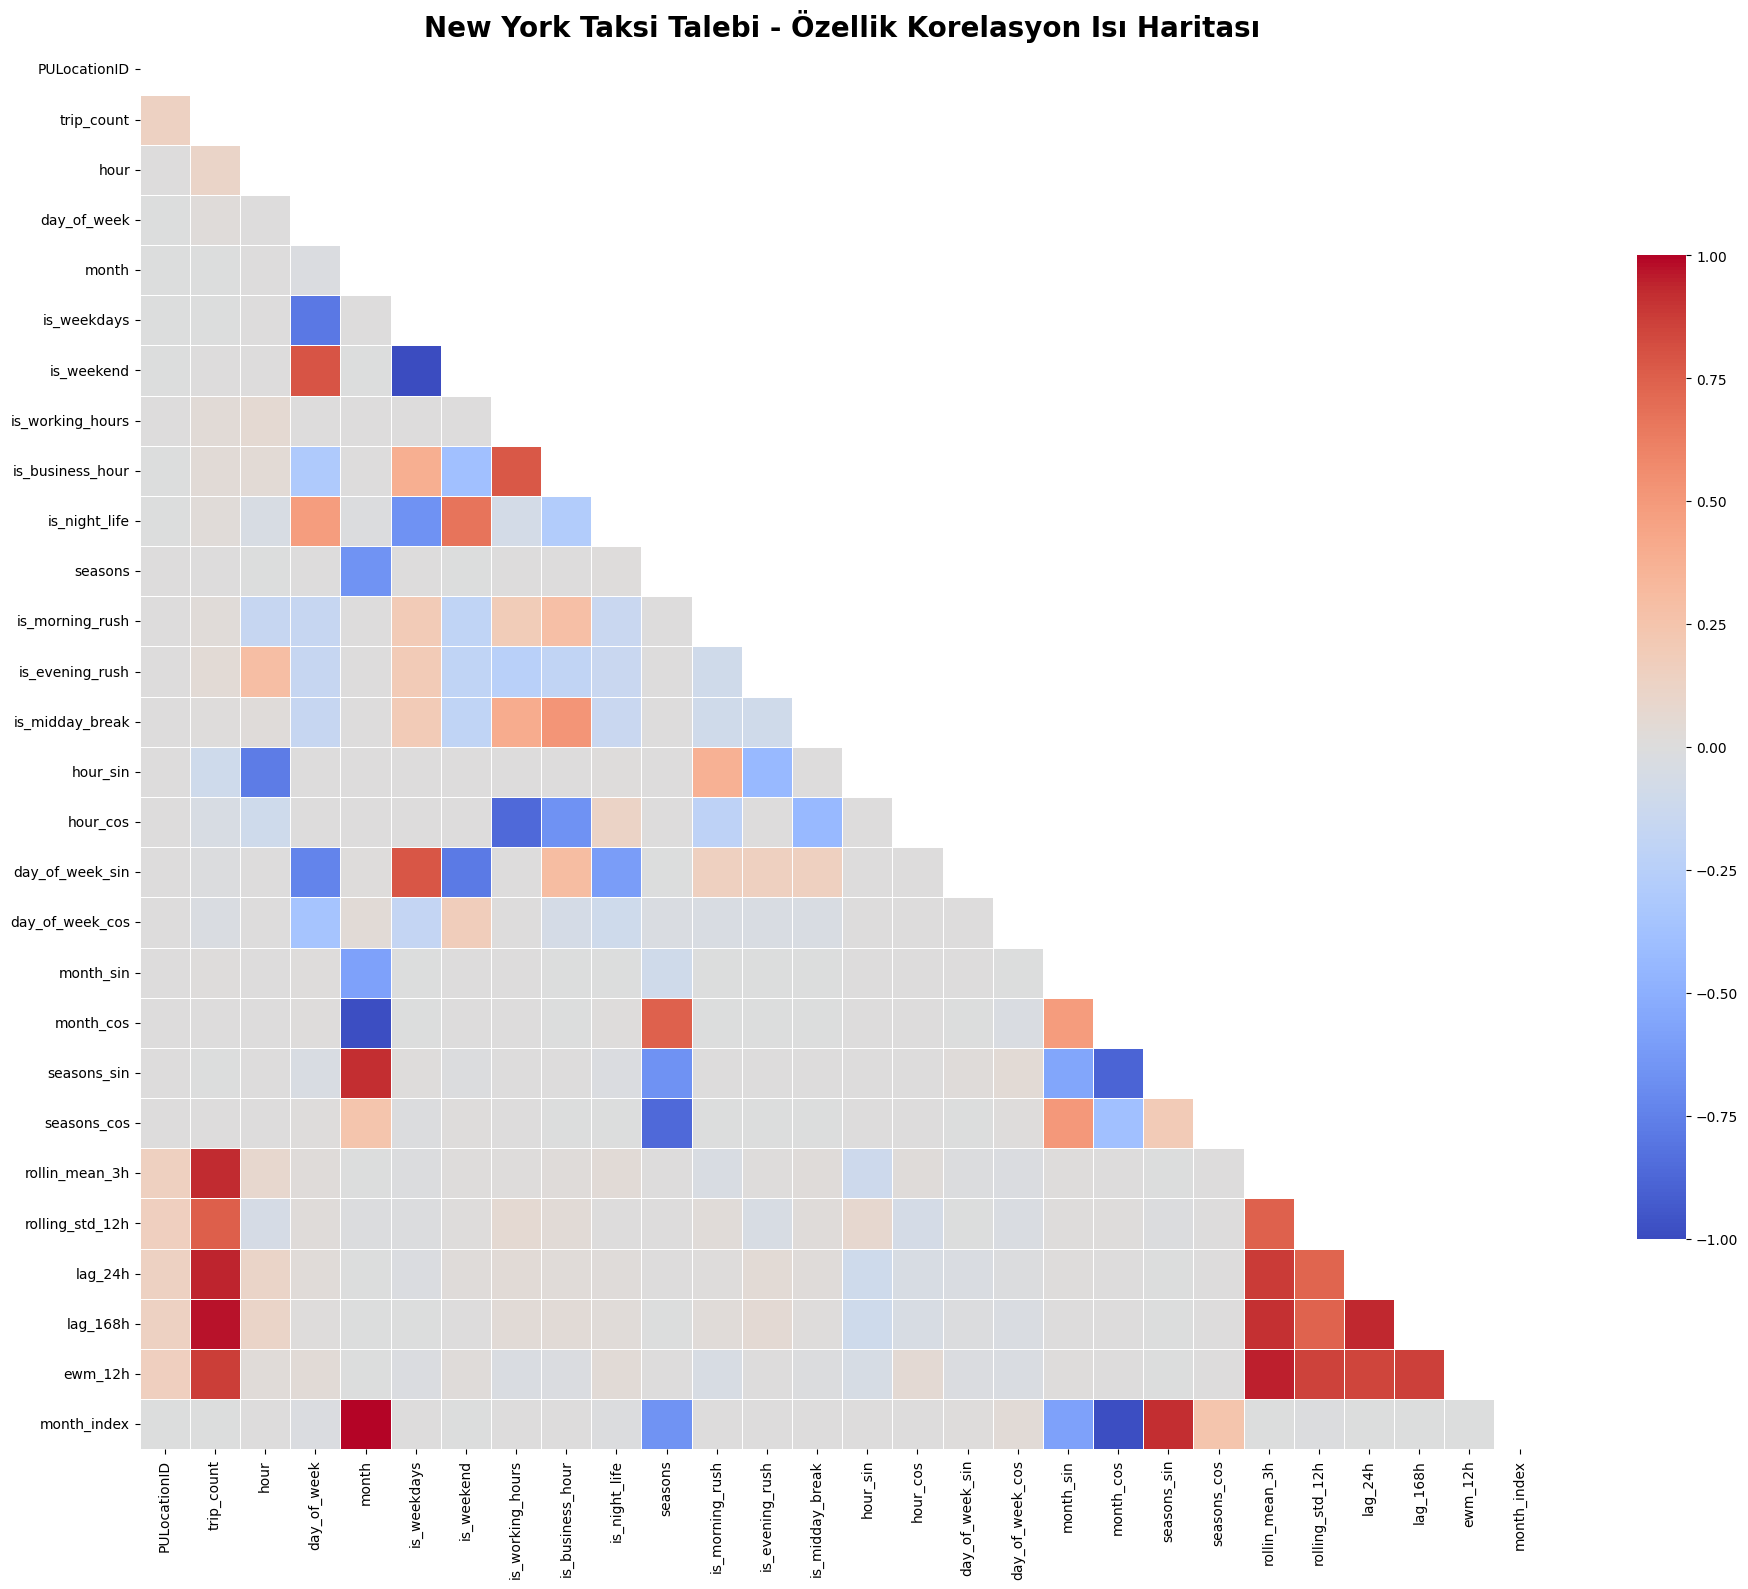

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

train_features = df[df["month_index"] <= 6].select_dtypes(include=[np.number])

corr_matrix = train_features.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(20, 16))

sns.heatmap(corr_matrix, 
            mask=mask, 
            cmap="coolwarm",
            vmax=1.0, vmin=-1.0, 
            center=0,
            annot=False,
            square=True, 
            linewidths=.5, 
            cbar_kws={"shrink": .7})

plt.title("New York Taksi Talebi - Özellik Korelasyon Isı Haritası", fontsize=20, fontweight="bold")
plt.tight_layout()
plt.show()

Son kez "trip_count" ile diğer verilerin ilişkisine bakacağım.

In [71]:
target_correlation_matrix = df.corr()
target_correlation = target_correlation_matrix["trip_count"].abs().sort_values(ascending=False)
target_correlation

trip_count          1.000000
lag_168h            0.971008
lag_24h             0.939512
rollin_mean_3h      0.923699
ewm_12h             0.871075
rolling_std_12h     0.747583
PULocationID        0.142859
hour                0.111889
hour_sin            0.104866
is_evening_rush     0.047853
hour_cos            0.043068
is_working_hours    0.040267
is_business_hour    0.036124
pickup_hour         0.029216
month_index         0.029163
is_morning_rush     0.024582
month_sin           0.023430
month               0.020298
day_of_week_cos     0.020221
is_night_life       0.018852
seasons_cos         0.017190
is_midday_break     0.016839
day_of_week         0.010252
seasons             0.009037
seasons_sin         0.008152
month_cos           0.004198
day_of_week_sin     0.003251
is_weekend          0.001643
is_weekdays         0.001643
Name: trip_count, dtype: float64

In [72]:
df.columns

Index(['pickup_hour', 'PULocationID', 'trip_count', 'hour', 'day_of_week',
       'month', 'is_weekdays', 'is_weekend', 'is_working_hours',
       'is_business_hour', 'is_night_life', 'seasons', 'is_morning_rush',
       'is_evening_rush', 'is_midday_break', 'hour_sin', 'hour_cos',
       'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos',
       'seasons_sin', 'seasons_cos', 'rollin_mean_3h', 'rolling_std_12h',
       'lag_24h', 'lag_168h', 'ewm_12h', 'month_index'],
      dtype='object')

### Expanding Cross Validation

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error

FEATURES = ["PULocationID", 
            "is_weekdays", 
            "is_weekend", 
            "is_night_life", 
            "is_morning_rush", 
            "is_evening_rush", 
            "is_midday_break", 
            "hour_sin", 
            "hour_cos", 
            "day_of_week_sin", 
            "day_of_week_cos", 
            "month_sin", 
            "month_cos",
            "seasons_sin", 
            "seasons_cos", 
            "rollin_mean_3h", 
            "rolling_std_12h", 
            "lag_24h", 
            "lag_168h", 
            "ewm_12h", 
            ]

TARGET = "trip_count"

scores = []

for train_month_last in range(18, df["month_index"].max()):
    train_set = df[df["month_index"] <= train_month_last]
    test_set = df[df["month_index"] == train_month_last + 1]    # sonraki ay üzerinden test edeceği

    x_train = train_set[FEATURES].copy().astype('float32')  # ekran kartını şişmemesi için önlem
    y_train = train_set[TARGET].copy().astype('float32')

    x_test = test_set[FEATURES].copy().astype('float32')
    y_test = test_set[TARGET].copy().astype('float32')

    print(f" Train split: 1-{train_month_last} || Test split: {train_month_last + 1}")

    #! XGBoost Modeli
    reg = xgb.XGBRegressor(
        booster ='gbtree', 
        n_estimators=5000, 
        objective='reg:absoluteerror', 
        eval_metric='mae', 
        early_stopping_rounds=50,   # 10
        max_depth=6,
        learning_rate=0.01, 
        tree_method='hist', 
        device='cuda', 
        random_state=42 # rastgele kararlar alıyor olabilirsin ama hep aynı rastgelellik ile devam et!
    )

    reg.fit(
        x_train, y_train, 
        eval_set=[(x_test, y_test)], 
        verbose=100
    )

    y_pred = reg.predict(x_test)

    for i in range(len(y_pred)):    # tahmin değeri negatif olamaz, çünkü taksi sayısı negatif olamaz.
        y_pred[i] = max(0, y_pred[i])

    score = mean_absolute_error(y_test, y_pred)
    scores.append(score)

    print(f"Ay {train_month_last + 1} İçin Başarı Skoru (MAE): {score:.2f} Taksi")

print("\n" + "="*50)
print(f"SİMÜLASYON BİTTİ! Tüm Ayların Ortalama Hatası: {sum(scores) / len(scores):.2f} Taksi")

 Train split: 1-18 || Test split: 19
[0]	validation_0-mae:51.16934
[100]	validation_0-mae:20.39959
[200]	validation_0-mae:10.83493
[300]	validation_0-mae:8.38028
[400]	validation_0-mae:7.81348
[500]	validation_0-mae:7.63346
[600]	validation_0-mae:7.56931
[700]	validation_0-mae:7.52030
[800]	validation_0-mae:7.47626
[900]	validation_0-mae:7.46367
[1000]	validation_0-mae:7.41668
[1100]	validation_0-mae:7.39087
[1200]	validation_0-mae:7.34671
[1300]	validation_0-mae:7.31150
[1400]	validation_0-mae:7.27032
[1500]	validation_0-mae:7.23487
[1600]	validation_0-mae:7.20345
[1700]	validation_0-mae:7.17702
[1800]	validation_0-mae:7.15505
[1900]	validation_0-mae:7.12728
[2000]	validation_0-mae:7.10144
[2100]	validation_0-mae:7.07218
[2200]	validation_0-mae:7.04485
[2300]	validation_0-mae:7.01775
[2400]	validation_0-mae:6.98931
[2500]	validation_0-mae:6.96848
[2600]	validation_0-mae:6.95109
[2700]	validation_0-mae:6.93291
[2800]	validation_0-mae:6.91466
[2900]	validation_0-mae:6.89629
[3000]	valid

### Feature Importance

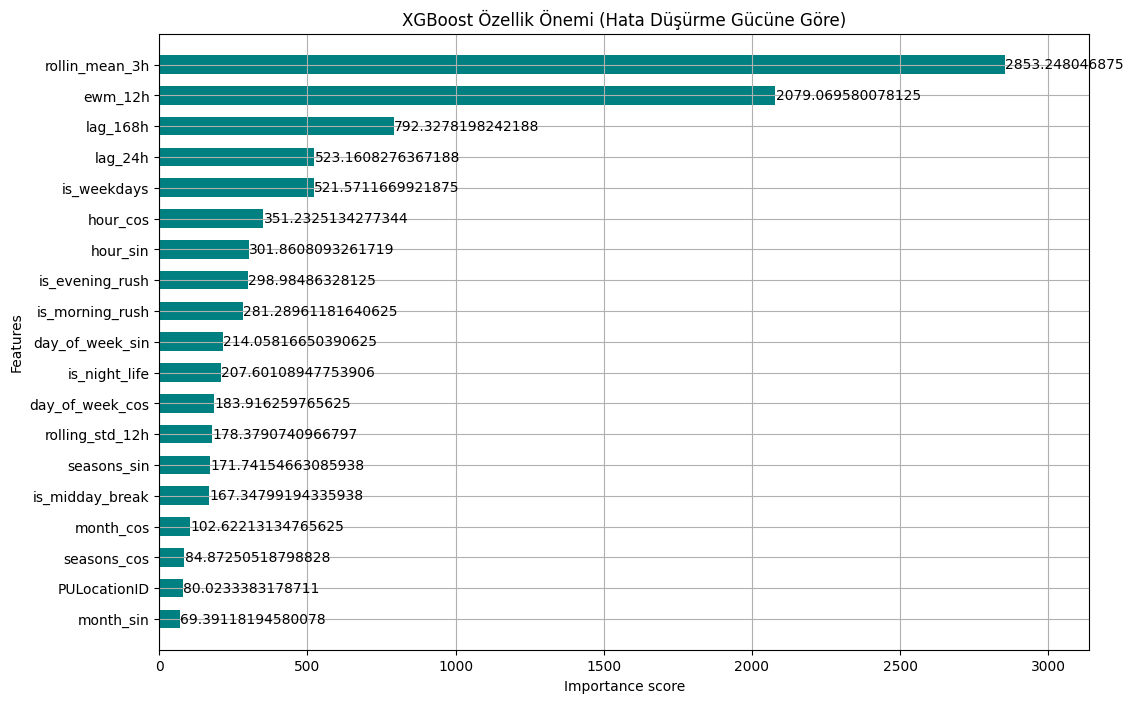

In [ ]:
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 8)

xgb.plot_importance(reg, importance_type='gain', max_num_features=20, height=0.6,   # XGBoost built-in grafik
                    title="XGBoost Özellik Önemi (Hata Düşürme Gücüne Göre)", 
                    color="teal")
plt.show()

Lag ve Roll yapmanın önemi ortaya çıktı!

Son 4 satırdaki veriler silinebilir. Modelin işine fazla yaramamış.

In [76]:
df.columns

Index(['pickup_hour', 'PULocationID', 'trip_count', 'hour', 'day_of_week',
       'month', 'is_weekdays', 'is_weekend', 'is_working_hours',
       'is_business_hour', 'is_night_life', 'seasons', 'is_morning_rush',
       'is_evening_rush', 'is_midday_break', 'hour_sin', 'hour_cos',
       'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos',
       'seasons_sin', 'seasons_cos', 'rollin_mean_3h', 'rolling_std_12h',
       'lag_24h', 'lag_168h', 'ewm_12h', 'month_index'],
      dtype='object')

In [77]:
df.drop(columns=["month_cos", "seasons_cos", "PULocationID", "month_sin"], inplace=True)

- Final Training

In [78]:
FEATURES = ["is_weekdays", 
            "is_weekend", 
            "is_night_life", 
            "is_morning_rush", 
            "is_evening_rush", 
            "is_midday_break", 
            "hour_sin", 
            "hour_cos", 
            "day_of_week_sin", 
            "day_of_week_cos",
            "seasons_sin", 
            "rollin_mean_3h", 
            "rolling_std_12h", 
            "lag_24h", 
            "lag_168h", 
            "ewm_12h", 
            ]

TARGET = "trip_count"

X_train = df[FEATURES].copy().astype("float32") # Artık her şey eğitim için
Y_train = df[TARGET].copy().astype("float32")

#! XGBoost Modeli
reg = xgb.XGBRegressor(
    booster ='gbtree', 
    n_estimators=1500, 
    objective='reg:absoluteerror', 
    eval_metric='mae',
    max_depth=6,
    learning_rate=0.02, 
    tree_method='hist', 
    device='cuda', 
    random_state=42 # rastgele kararlar alıyor olabilirsin ama hep aynı rastgelellik ile devam et!
)

reg.fit(
    X_train, Y_train, 
    verbose=100
)

,objective,'reg:absoluteerror'
,base_score,None
,booster,'gbtree'
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,'cuda'
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mae'


"reg" bizim son kez eğitilmiş modelimiz

In [79]:
scores

[6.6925554275512695,
 5.271616458892822,
 6.882317066192627,
 6.153665065765381,
 7.070106029510498,
 7.529755115509033]

In [80]:
print(f"2016 Temmuz Ne kadar farkla tahmin etti: {scores[0]}")
print(f"2016 Ağustos Ne kadar farkla tahmin etti: {scores[1]}")
print(f"2016 Eylül Ne kadar farkla tahmin etti: {scores[2]}")
print(f"2016 Ekim Ne kadar farkla tahmin etti: {scores[3]}")
print(f"2016 Kasım Ne kadar farkla tahmin etti: {scores[4]}")
print(f"2016 Aralık Ne kadar farkla tahmin etti: {scores[5]}")

2016 Temmuz Ne kadar farkla tahmin etti: 6.6925554275512695
2016 Ağustos Ne kadar farkla tahmin etti: 5.271616458892822
2016 Eylül Ne kadar farkla tahmin etti: 6.882317066192627
2016 Ekim Ne kadar farkla tahmin etti: 6.153665065765381
2016 Kasım Ne kadar farkla tahmin etti: 7.070106029510498
2016 Aralık Ne kadar farkla tahmin etti: 7.529755115509033


In [81]:
# Modeli kaydedelim
reg.save_model("NYC_taxi_count_model.json")

### LightGBM

In [ ]:
import lightgbm as lgb

lgb_scores = []

for last_month_index in range(18, 24):
    train_set = df[df["month_index"] <= last_month_index]
    test_set = df[df["month_index"] == last_month_index + 1]

    x_train = train_set[FEATURES].copy().astype("float32")
    y_train = train_set[TARGET].copy().astype("float32")

    x_test = test_set[FEATURES].copy().astype("float32")
    y_test = test_set[TARGET].copy().astype("float32")

    lgb_model = lgb.LGBMRegressor(
        n_estimators=5000,
        learning_rate=0.01,
        max_depth=6,
        device_type='gpu',
        random_state=42
    )

    lgb_model.fit(
        x_train, y_train,
        eval_set=[(x_test, y_test)],
        callbacks=[lgb.early_stopping(stopping_rounds=50)]
    )

    predict = lgb_model.predict(x_test)
    mistake = mean_absolute_error(y_test, predict)
    lgb_scores.append(mistake)

    print(f"Ay {last_month_index + 1} İçin Başarı Skoru (MAE): {mistake:.2f} Taksi")

print("=" * 20)
print(f"Tüm ayların ortalama hatası: {np.mean(lgb_scores):.2f} Taksi")

[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 1332
[LightGBM] [Info] Number of data points in the train set: 3434400, number of used features: 16
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 3050 Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 11 dense feature groups (39.30 MB) transferred to GPU in 0.057673 secs. 1 sparse feature groups
[LightGBM] [Info] Start training from score 61.261019
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[5000]	valid_0's l2: 442.173
Ay 19 İçin Başarı Skoru (MAE): 6.68 Taksi
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 1332
[LightGBM] [Info] Number of data points in the train set: 3631560, number of used features: 16
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce R

LightGBM, XGBoost'a göre daha hızlı çalıştı ve yakın sonuç verdi.

- Final Training for LightGBM

In [84]:
X_train = df[FEATURES].copy().astype("float32")
Y_train = df[TARGET].copy().astype("float32")

lgb_model.fit(
    X_train, Y_train,
)

print("Final lgb model is ready!")

[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 1332
[LightGBM] [Info] Number of data points in the train set: 4604640, number of used features: 16
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 3050 Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 11 dense feature groups (52.70 MB) transferred to GPU in 0.062795 secs. 1 sparse feature groups
[LightGBM] [Info] Start training from score 58.901827
Final lgb model is ready!


In [85]:
# lgb modeli kalıcı hale getirelim
lgb_model.booster_.save_model("NYC_taxi_count_lgb.txt")

### CatBoost

CatBoost MAE desteği olmadığu için (kötü sonuç verdi), RMSE (Root Mean Suared Error) kullanacağız. Böylece ekran kartı mutlak değer işlmeinden (MAE) kurtulacak!

In [88]:
import catboost as cb

cb_scores = []

for last_month_index in range(18, 24):
    train_set = df[df["month_index"] <= last_month_index]
    test_set = df[df["month_index"] == last_month_index + 1]

    x_train = train_set[FEATURES].copy().astype("float32")
    y_train = train_set[TARGET].copy().astype("float32")

    x_test = test_set[FEATURES].copy().astype("float32")
    y_test = test_set[TARGET].copy().astype("float32")

    cat_model = cb.CatBoostRegressor(
        iterations=5000,
        learning_rate=0.01,
        depth=6,
        loss_function="RMSE",
        eval_metric="MAE",
        task_type="GPU",
        random_seed=42,
        verbose=False
    )

    cat_model.fit(
        x_train, y_train,
        eval_set=(x_test, y_test),
        early_stopping_rounds=50
    )

    predict = cat_model.predict(x_test)
    mistake = mean_absolute_error(y_test, predict)
    cb_scores.append(mistake)

    print(f"Ay {last_month_index + 1} İçin Başarı Skoru (MAE): {mistake:.2f} Taksi")

print("=" * 20)
print(f"Tüm ayların ortalama hatası: {np.mean(cb_scores):.2f} Taksi")

Default metric period is 5 because MAE is/are not implemented for GPU


Ay 19 İçin Başarı Skoru (MAE): 6.97 Taksi


Default metric period is 5 because MAE is/are not implemented for GPU


KeyboardInterrupt: 

19.ay 15 dk da hesaplandı, tüm süreç 1,5 saat süreceğinden yarıda bıraktım. CatBoost çok yavaş bir performans gösterdi.

### Hyperparameter Tuning

- LightGBM GridSearch

In [72]:
df.columns

Index(['pickup_hour', 'PULocationID', 'trip_count', 'hour', 'day_of_week',
       'month', 'is_weekdays', 'is_weekend', 'is_working_hours',
       'is_business_hour', 'is_night_life', 'seasons', 'is_morning_rush',
       'is_evening_rush', 'is_midday_break', 'hour_sin', 'hour_cos',
       'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos',
       'seasons_sin', 'seasons_cos', 'rollin_mean_3h', 'rolling_std_12h',
       'lag_24h', 'lag_168h', 'ewm_12h', 'month_index'],
      dtype='object')

In [74]:
import lightgbm as lgb
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

FEATURES = ["is_weekdays", 
            "is_weekend", 
            "is_night_life", 
            "is_morning_rush", 
            "is_evening_rush", 
            "is_midday_break", 
            "hour_sin", 
            "hour_cos", 
            "day_of_week_sin", 
            "day_of_week_cos",
            "seasons_sin", 
            "rollin_mean_3h", 
            "rolling_std_12h", 
            "lag_24h", 
            "lag_168h", 
            "ewm_12h", 
            "PULocationID"
            ]

TARGET = "trip_count"

x_train = df[FEATURES].copy().astype("float32")
y_train = df[TARGET].copy().astype("float32")

tscv = TimeSeriesSplit(n_splits=2)

LGBmodel = lgb.LGBMRegressor(
    device_type="gpu",
    random_state=42
)

#! Grid Search için kullanacağım matrix
param_grid = {
    "learning_rate": [0.01, 0.03, 0.05],
    "max_depth": [4, 6, 8],
    "n_estimators": [800, 1200, 1800]
}

grid_search = GridSearchCV(
    estimator=LGBmodel,
    param_grid=param_grid,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    verbose=2,
    n_jobs=1   # modelleri GPU'ya birer birer girmesi için sıraya koydum, yoksa "CUDA Out of Memory" yerim.
)

print("Grid Search ile model eğitimi...")
grid_search.fit(x_train, y_train)

print("Grid Search tamamlandi!")
print(f"En iyi parametreler: {grid_search.best_params_}")
print(f"En iyi skor (MAE): {-grid_search.best_score_:.2f} Taxi")

final_best_model = grid_search.best_estimator_  # en iyi modeli saklarım.

Grid Search ile model eğitimi...
Fitting 2 folds for each of 27 candidates, totalling 54 fits
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 1422
[LightGBM] [Info] Number of data points in the train set: 1534880, number of used features: 17
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 3050 Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 12 dense feature groups (17.57 MB) transferred to GPU in 0.023367 secs. 1 sparse feature groups
[LightGBM] [Info] Start training from score 29.782652
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] 

İzlenim: LightGBM GridSearchCV sonucu 10.8 taksi. Daha önce eğittiğim XGBoost modeline göre daha kötü sonuç verdi.

- LightGBM RandomizedSearchCV

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

tscv = TimeSeriesSplit(n_splits=2)
LGBmodel_random = lgb.LGBMRegressor(
    device_type="gpu",
    random_state=42
)

param_dist = {
    "learning_rate": uniform(0.01, 0.09),   # learning_rate bu aralıktan seçilecek
    "max_depth": randint(4,10), # max_depth bu aralıktan seçilecek
    "n_estimators": randint(500,2500)   # tree sayısı bu aralıktan seçilecek
}

random_search = RandomizedSearchCV(
    estimator=LGBmodel_random,
    param_distributions=param_dist,
    n_iter=30,  # sadece 30 deneme yap
    cv=tscv,
    scoring="neg_mean_absolute_error",
    verbose=2,
    random_state=42,
    n_jobs=1
)

print("Random Search başliyor...")
random_search.fit(x_train, y_train)

print("Random Search Tamamlandi.")
print(f"En iyi parametreler: {random_search.best_params_}")
print(f"En iyi MAE skor: {-random_search.best_score_:.2f} Taksi")

best_random_model = random_search.best_estimator_

İzlenim: LightGBM RandomizedSearchCV sonucu 10.78 taksi. Daha önce eğittiğim XGBoost modeline göre daha kötü sonuç verdi.

Randomized Search farkı: verdiği optimal parametre değerlerine bakarsak randomized search insan eliyle girilemeyecek değerleri bulmada gayet başarılı.

### OPTUNA

Bayesian optimization ile optimum MAE bulmaya çalışacağım.

In [ ]:
import optuna
from sklearn.metrics import mean_absolute_error

def objective(trial):

    param = {
        "device_type": "gpu",
        "random_state": 42,
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.05, log=True),
        "max_depth": trial.suggest_int("max_depth", 5, 8),
        "n_estimators": trial.suggest_int("n_estimators", 2000, 6000),
        "num_leaves": trial.suggest_int("num_leaves", 31, 128)
    }

    tscv = TimeSeriesSplit(n_splits=2)
    optuna_scores = []

    for train_idx, val_idx in tscv.split(x_train):
        x_tr = x_train.iloc[train_idx]
        x_val = x_train.iloc[val_idx]
        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        LGB_optuna_model = lgb.LGBMRegressor(**param)   # lgb modeli
        callbacks = [lgb.early_stopping(stopping_rounds=10, verbose=False)]

        LGB_optuna_model.fit(   # modeli eğittik
            x_tr, y_tr,
            eval_set=[(x_val, y_val)],
            callbacks=callbacks
        )

        # Tahmin yapıp MAE hesabı
        predictions = LGB_optuna_model.predict(x_val)
        mae = mean_absolute_error(y_val, predictions)
        optuna_scores.append(mae)
    
    return np.mean(optuna_scores)

print("Optuna çalişiyor...")
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=20)

print("=" * 50)
print(f"Optuna en iyi MAE Skoru: {study.best_value:.2f} Taksi")
print(f"En optimal değer veren parametreler: {study.best_params}")

### Ablation Studies

Bu kısımda 4 farklı deney yapacağım. ("rollin_mean_3h", "ewm_12h", "lag_168h", "lag_24h") hem korelasyon olarak hem de Feature Importance olarak birbirine yakın değerler. Her birini modele yalnız vererek tahminleme deneyleri yapacağım.

In [72]:
df.columns

Index(['pickup_hour', 'PULocationID', 'trip_count', 'hour', 'day_of_week',
       'month', 'is_weekdays', 'is_weekend', 'is_working_hours',
       'is_business_hour', 'is_night_life', 'seasons', 'is_morning_rush',
       'is_evening_rush', 'is_midday_break', 'hour_sin', 'hour_cos',
       'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos',
       'seasons_sin', 'seasons_cos', 'rollin_mean_3h', 'rolling_std_12h',
       'lag_24h', 'lag_168h', 'ewm_12h', 'month_index'],
      dtype='object')

In [73]:
df.dtypes

pickup_hour         datetime64[ns]
PULocationID                 int64
trip_count                   int64
hour                         int32
day_of_week                  int32
month                        int32
is_weekdays                  int64
is_weekend                   int64
is_working_hours             int64
is_business_hour             int64
is_night_life                int64
seasons                      int64
is_morning_rush              int64
is_evening_rush              int64
is_midday_break              int64
hour_sin                   float64
hour_cos                   float64
day_of_week_sin            float64
day_of_week_cos            float64
month_sin                  float64
month_cos                  float64
seasons_sin                float64
seasons_cos                float64
rollin_mean_3h             float64
rolling_std_12h            float64
lag_24h                    float64
lag_168h                   float64
ewm_12h                    float64
month_index         

- rollin_mean_3h

In [72]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error
import numpy as np
import pandas as pd

FEATURES = ["is_weekdays", 
            "is_weekend", 
            "is_night_life", 
            "is_morning_rush", 
            "is_evening_rush", 
            "is_midday_break", 
            "hour_sin", 
            "hour_cos", 
            "day_of_week_sin", 
            "day_of_week_cos",
            "seasons_sin", 
            "rollin_mean_3h",   # esas deney odağı
            "rolling_std_12h",
            "PULocationID"
            ]

TARGET = "trip_count"

lgb_scores_rollin_mean_3h = [] # modelin yaptığı tahminlere göre mae değerleri burada tutulacak
all_predictions = []    # modelin yaptığı saf tahminleri burada biriktireceğim
all_real_values = []    # Bu tahminlere karşılık gerçek değerler burada olacak

for last_month_index in range(18, 24):  # Expanding Window
    train_set = df[df["month_index"] <= last_month_index]
    test_set = df[df["month_index"] == last_month_index + 1]

    x_train = train_set[FEATURES].copy().astype("float32")
    x_train["PULocationID"] = x_train["PULocationID"].astype("int32")
    x_train.loc[x_train["PULocationID"] >= 250, "PULocationID"] = 250   # LocationID 250'den sonrasını tek bir label yaptım yoksa bin sayısı GPU'ya sığmıyor.
    y_train = train_set[TARGET].copy().astype("float32")

    x_test = test_set[FEATURES].copy().astype("float32")
    x_test["PULocationID"] = x_test["PULocationID"].astype("int32")
    x_test.loc[x_test["PULocationID"] >= 250, "PULocationID"] = 250 # LocationID 250'den sonrasını tek bir label yaptım yoksa bin sayısı GPU'ya sığmıyor.
    y_test = test_set[TARGET].copy().astype("float32")

    # LightGBM histogramlar kurarak çalışır. O yüzden bin sayısının GPU'ya sığacak şekilde ayarlanması önemlidir!

    lgb_model = lgb.LGBMRegressor(
        n_estimators=5000,
        learning_rate=0.01,
        max_depth=6,
        device_type='gpu',
        random_state=42,
    )

    lgb_model.fit(
        x_train, y_train,
        eval_set=[(x_test, y_test)],
        callbacks=[lgb.early_stopping(stopping_rounds=25)],
        categorical_feature=["PULocationID"]    # Location ID ler aslında bir büyüklük değil, etiket. ID 200, ID 100'ün 2 katı değil!
    )

    current_estimations = lgb_model.predict(x_test)
    mistake = mean_absolute_error(y_test, current_estimations)
    lgb_scores_rollin_mean_3h.append(mistake)

    all_predictions.extend(current_estimations)
    all_real_values.extend(y_test.values)

    print(f"Ay {last_month_index + 1} İçin Başarı Skoru (MAE): {mistake:.2f} Taksi")

print("=" * 20)
print(f"Tüm ayların ortalama hatası: {np.mean(lgb_scores_rollin_mean_3h):.2f} Taksi")

predictions_rollin_mean_3h = np.array(all_predictions)
real_values_rollin_mean_3h = np.array(all_real_values)

print(f"Model tahminleri predictions_rollin_mean_3h içersinde (Toplam {len(predictions_rollin_mean_3h)} satır veri korundu!)")

[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 817
[LightGBM] [Info] Number of data points in the train set: 3434400, number of used features: 14
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 3050 Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 9 dense feature groups (39.30 MB) transferred to GPU in 0.110028 secs. 1 sparse feature groups
[LightGBM] [Info] Start training from score 61.261019
Training until validation scores don't improve for 25 rounds
Did not meet early stopping. Best iteration is:
[5000]	valid_0's l2: 421.29
Ay 19 İçin Başarı Skoru (MAE): 6.75 Taksi
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 817
[LightGBM] [Info] Number of data points in the train set: 3631560, number of used features: 14
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 3

In [80]:
predictions_rollin_mean_3h[predictions_rollin_mean_3h < 0] = 0
predictions_rollin_mean_3h

array([ 0.40945556,  0.0405718 ,  0.        , ...,  5.61898599,
        6.35833699, 11.05642971], shape=(1170240,))

In [78]:
real_values_rollin_mean_3h

array([0., 0., 0., ..., 2., 2., 2.], shape=(1170240,), dtype=float32)

- standart deviation

In [73]:
np.std(lgb_scores_rollin_mean_3h)

np.float64(0.39949081527741437)

MAE sonucu taksi sayısı bakımından modelin ne kadar yakın tahmin yaptığını gösterir lakin sadece MAE sonucuna bakıp gerçek veriyi incelemez isek, hata yapabiliriz. Gerçek 5 iken 6 fark başka, gerçek veri 1000 iken 6 fark başka. Bunun için WAPE kullanıp bir de yüzdelik bakımından hata payı ölçeceğim.

In [75]:
numerator = np.sum(np.abs(real_values_rollin_mean_3h - predictions_rollin_mean_3h))
denominator = np.sum(np.abs(real_values_rollin_mean_3h))

WAPE = numerator / denominator
print(f"WAPE score for rollin_mean_3h is: %{WAPE * 100}")

WAPE score for rollin_mean_3h is: %13.118618255335054


In [205]:
#! root_mean_squared_error
from sklearn.metrics import root_mean_squared_error
RMSE = root_mean_squared_error(real_values_rollin_mean_3h, predictions_rollin_mean_3h)
RMSE

20.828593303232545

In [206]:
#! R^2
from sklearn.metrics import r2_score
R2 = r2_score(real_values_rollin_mean_3h, predictions_rollin_mean_3h)
R2

0.9774097948854682

Çıkarım: R^2 modelin zekasını gösteren 0 ve 1 arasında bir ölçüttür. Modelin gerçek hayat kaoslarına karşı ne kadar dayanıklı olduğunu ölçen bir metrik idir. 1 e yakın olması tercih edilir.

In [81]:
#! Visualization

from sklearn.metrics import PredictionErrorDisplay  # sklearn built-in graph plotting

def scatter_plot(real, prediction):
    display = PredictionErrorDisplay.from_predictions(
        y_true=real,
        y_pred=prediction,
        kind="actual_vs_predicted"
    )
    display.plot()

# scatter_plot(real_values_rollin_mean_3h, predictions_rollin_mean_3h)

Çıkarım: scatter plotlardan anlaşılacağı üzere model "Heteroscedasticity" bir yaklaşım sergilemiştir. Yani tahmin etmemiz gerek değer arttıkça modelin sapma miktarı artmıştır. Küçük değerler kolaylıkla tahmin edilebilirken, büyük değerler için model aralık belirlemede zorlanmıştır. Bu modelin verinin doğasına göre hareket ettiğini ve overfit olmadığını bize kanıtlar. Eğer çok büyük değerleri, çok küçük farklar ile tahmin edebilse idi, overfit şüphesi oluşurdu.

- Ortalama ile grafik çıkarımı

In [83]:
import numpy as np
import matplotlib.pyplot as plt

def real_vs_prediction_plot(real, prediction):
    real_average_per_month = real.reshape(6,-1).mean(axis=1)    # 6 ay için 6 ya böl
    predicted_average_per_month = prediction.reshape(6,-1).mean(axis=1)

    months = ["July", "August", "September", "October", "November", "December"]

    plt.figure(figsize=(10,6))

    plt.plot(months, real_average_per_month, marker='o', markersize=8, linewidth=2, label='Real Taxi Amount (Blue)', color='blue', alpha=0.8)
    plt.plot(months, predicted_average_per_month, marker='s', markersize=8, linewidth=2, linestyle='--', label='Predicitions (Red)', color='red', alpha=0.8)

    for i in range(6):
        plt.annotate(f"{real_average_per_month[i]:.1f}", 
                    (months[i], real_average_per_month[i]), 
                    textcoords="offset points", xytext=(0,10), ha='center', color='blue', fontweight='bold')
        
        plt.annotate(f"{predicted_average_per_month[i]:.1f}", 
                    (months[i], predicted_average_per_month[i]), 
                    textcoords="offset points", xytext=(0,-15), ha='center', color='red', fontweight='bold')

    plt.title("6 Aylık Makro Trend: Gerçek vs Model Tahmini (Aylık Ortalamalar)", fontsize=14, fontweight="bold")
    plt.xlabel("Test Edilen Aylar", fontsize=12)
    plt.ylabel("Aylık Ortalama Taksi Talebi", fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

# real_vs_prediction_plot(real_values_rollin_mean_3h, predictions_rollin_mean_3h)

Çıkarım: Model trendi yakalayabilmiş ama küçük farklar ile fazladan tahminlerde bulunmuş.

In [86]:
import numpy as np
import matplotlib.pyplot as plt

def real_vs_prediction_stdPlot(real, prediction):
    real_matrix = real.reshape(6, -1)
    prediction_matrix = prediction.reshape(6, -1)

    real_average_per_month = real_matrix.mean(axis=1) # ortalama değerler
    prediction_average_per_month = prediction_matrix.mean(axis=1)

    real_std_per_month = real_matrix.std(axis=1)  # standard sapma
    prediction_std_per_month = prediction_matrix.std(axis=1)

    months = ["July", "August", "September", "October", "November", "December"]

    plt.figure(figsize=(12, 7))

    plt.plot(months, real_average_per_month, marker='o', markersize=8, linewidth=2, label='Gerçek Ortalama', color="blue")
    plt.fill_between(months, 
                    real_average_per_month - real_std_per_month, 
                    real_average_per_month + real_std_per_month, 
                    color="blue", alpha=0.2, label='Gerçek Veri Dalgalanması (±1 Std)')

    plt.plot(months, prediction_average_per_month, marker='s', markersize=8, linewidth=2, linestyle='--', label='Model Tahmini', color="red")
    plt.fill_between(months, 
                    prediction_average_per_month - prediction_std_per_month, 
                    prediction_average_per_month + prediction_std_per_month, 
                    color="red", alpha=0.1, label='Modelin Tahmin Yayılımı (±1 Std)')


    plt.ylim(bottom=0)  # taksi sayısı 0 olamaz, alt sınır 0

    plt.title("6 Aylık Taksi Talebi: Ortalamalar ve Standart Sapma (Veri Ölçeği)", fontsize=15, fontweight="bold")
    plt.xlabel("Test Edilen months", fontsize=12)
    plt.ylabel("Taksi Sayısı (Ortalama ve Dalgalanma Aralığı)", fontsize=12)
    plt.legend(loc="upper right", fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

    print("6 AYLIK VERİ ÖLÇEĞİ VE STANDART SAPMA ANALİZİ: REAL")
    for i in range(6):
        print(f"{months[i]}: Ortalama {real_average_per_month[i]:.1f} Taksi | Standart Sapma: ±{real_std_per_month[i]:.1f} Taksi")

    print("6 AYLIK VERİ ÖLÇEĞİ VE STANDART SAPMA ANALİZİ: PREDICTED")
    for i in range(6):
        print(f"{months[i]}: Ortalama {prediction_average_per_month[i]:.1f} Taksi | Standart Sapma: ±{prediction_std_per_month[i]:.1f} Taksi")

# real_vs_prediction_stdPlot(real_values_rollin_mean_3h, predictions_rollin_mean_3h)

İzlenim: Modelin tahminleri sonucu oluşan standard sapma, gerçek standard sapmaya yakın!

Final çıkarım: Bu özellik modelin final eğitiminde mutlaka kullanılmalıdır, decision tree ler dallanma yaparken bu if-else bloklarından faydalanmışlar ve sonuçlar güzel gelmiş.

- rollin_mean_3h haftalık inceleme

In [88]:
import pandas as pd
import matplotlib.pyplot as plt

def weekly_trend_plot(real, prediction):
    # 1 Hafta = 250 lokasyon * 24 saat * 7 gün = 42.000 satır
    ROWS_PER_WEEK = 42000   # her 42000 satırda bütün lokasyonlar için 1 hafta bitmiş oluyor.

    df = pd.DataFrame({
        "Real": real,
        "Prediction": prediction    # gerçek ve tahmin değerleri yan yana olacak şekilde data frame oluştur.
    })

    df["Week_ID"] = (df.index // ROWS_PER_WEEK) + 1 # +1 diyerek 1. Haftadan başlatalım
    weekly_trend = df.groupby("Week_ID").mean() # aynı hafta içinde olanların ortlamasını alıp grupluyoruz.

    weeks = weekly_trend.index.astype(str) + ". Hafta"
    # 1. weekly_trend.index ile hafta sayısını alacağım ve bunu stringe çevireceğim.
    # sonuna hafta kelimesini de ekleyince x ekseni hazır

    plt.figure(figsize=(16, 6))

    plt.plot(weeks, weekly_trend["Real"], marker='o', markersize=6, linewidth=2, label='Gerçek Taksi (Blue)', color='blue', alpha=0.8)
    plt.plot(weeks, weekly_trend["Prediction"], marker='s', markersize=6, linewidth=2, linestyle='--', label='Model Tahmini (Red)', color='red', alpha=0.8)
    
    plt.title("Haftalık Makro Trend: Gerçek vs Model Tahmini (28 Haftalık Seyir)", fontsize=14, fontweight="bold")
    plt.xlabel("Test Edilen Haftalar (Baştan Sona Doğru)", fontsize=12)
    plt.ylabel("Haftalık Ortalama Taksi Talebi", fontsize=12)
    plt.legend(fontsize=11)
    
    # X eksenindeki yazıların birbirine girmemesi için dik (90 derece) yazdırıyoruz
    plt.xticks(rotation=45, ha='right')
    
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# weekly_trend_plot(real_values_rollin_mean_3h, predictions_rollin_mean_3h)

Modelin over estimate yaptığını önceki grafiklerde görmüştük. Burada da pattern yakaladığını ve over estimate yaptığını görebiliriz.

- rollin_mean_3h günlük inceleme (ortalama)

In [160]:
df.columns

Index(['pickup_hour', 'PULocationID', 'trip_count', 'hour', 'day_of_week',
       'month', 'is_weekdays', 'is_weekend', 'is_working_hours',
       'is_business_hour', 'is_night_life', 'seasons', 'is_morning_rush',
       'is_evening_rush', 'is_midday_break', 'hour_sin', 'hour_cos',
       'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos',
       'seasons_sin', 'seasons_cos', 'rollin_mean_3h', 'rolling_std_12h',
       'lag_24h', 'lag_168h', 'ewm_12h', 'month_index'],
      dtype='object')

In [161]:
df

,pickup_hour,PULocationID,trip_count,hour,day_of_week,month,is_weekdays,is_weekend,is_working_hours,is_business_hour,...,month_sin,month_cos,seasons_sin,seasons_cos,rollin_mean_3h,rolling_std_12h,lag_24h,lag_168h,ewm_12h,month_index
0,2015-01-08 00:00:00,1,0,0,3,1,1,0,0,0,...,5.000000e-01,0.866025,-1.0,-1.836970e-16,0.000000,0.288675,0.0,0.0,0.076671,1
1,2015-01-08 01:00:00,1,0,1,3,1,1,0,0,0,...,5.000000e-01,0.866025,-1.0,-1.836970e-16,0.000000,0.288675,0.0,0.0,0.064875,1
2,2015-01-08 02:00:00,1,0,2,3,1,1,0,0,0,...,5.000000e-01,0.866025,-1.0,-1.836970e-16,0.000000,0.288675,0.0,0.0,0.054894,1
3,2015-01-08 03:00:00,1,0,3,3,1,1,0,0,0,...,5.000000e-01,0.866025,-1.0,-1.836970e-16,0.000000,0.288675,1.0,0.0,0.046449,1
4,2015-01-08 04:00:00,1,0,4,3,1,1,0,0,0,...,5.000000e-01,0.866025,-1.0,-1.836970e-16,0.000000,0.000000,0.0,0.0,0.039303,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4604635,2016-12-31 19:00:00,265,4,19,5,12,0,1,0,0,...,-2.449294e-16,1.000000,-1.0,-1.836970e-16,2.333333,1.055290,2.0,0.0,2.122501,24
4604636,2016-12-31 20:00:00,265,5,20,5,12,0,1,0,0,...,-2.449294e-16,1.000000,-1.0,-1.836970e-16,3.000000,1.087115,0.0,1.0,2.411347,24
4604637,2016-12-31 21:00:00,265,2,21,5,12,0,1,0,0,...,-2.449294e-16,1.000000,-1.0,-1.836970e-16,4.000000,1.240112,2.0,4.0,2.809601,24
4604638,2016-12-31 22:00:00,265,2,22,5,12,0,1,0,0,...,-2.449294e-16,1.000000,-1.0,-1.836970e-16,3.666667,1.240112,2.0,2.0,2.685047,24


In [163]:
df["day_of_week"].min()

np.int32(0)

In [164]:
df["day_of_week"].max()

np.int32(6)

In [90]:
import pandas as pd
import matplotlib.pyplot as plt

def bulletproof_daily_trend(X_test_df, real, prediction):
    df = X_test_df.copy()   # orijinal veri bozulmasın diye testin kopyasını aldım.
    
    df["Real"] = real
    df["Prediction"] = prediction

    daily_trend = df.groupby("day_of_week")[["Real", "Prediction"]].mean()
    days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
    
    plt.figure(figsize=(10, 6))
    plt.plot(days, daily_trend["Real"], marker='o', markersize=8, linewidth=2, label='Gerçek Taksi (Blue)', color='blue', alpha=0.8)
    plt.plot(days, daily_trend["Prediction"], marker='s', markersize=8, linewidth=2, linestyle='--', label='Model Tahmini (Red)', color='red', alpha=0.8)
    
    plt.title("Orijinal Veriye Göre Haftalık Ritmin Gerçek Analizi", fontsize=14, fontweight="bold")
    plt.xlabel("Haftanın Günleri", fontsize=12)
    plt.ylabel("Günlük Ortalama Taksi Talebi", fontsize=12)
    plt.legend(fontsize=11)
    
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.ylim(50, 55) # bunu ekleyince aradaki fark çok fazla imiş gibi gözükmeyecek
    plt.show()  

x_test = df[df["month_index"] > 18]
# bulletproof_daily_trend(x_test, real_values_rollin_mean_3h, predictions_rollin_mean_3h)

- ewm_12h

In [168]:
import lightgbm as lgb
import webbrowser
from sklearn.metrics import mean_absolute_error
import numpy as np
import pandas as pd

FEATURES = ["is_weekdays", 
            "is_weekend", 
            "is_night_life", 
            "is_morning_rush", 
            "is_evening_rush", 
            "is_midday_break", 
            "hour_sin", 
            "hour_cos", 
            "day_of_week_sin", 
            "day_of_week_cos",
            "seasons_sin", 
            "ewm_12h",   # esas deney odağı
            "rolling_std_12h",
            "PULocationID"
            ]

TARGET = "trip_count"

lgb_scores_ewm_12h = [] # modelin yaptığı tahminlere göre mae değerleri burada tutulacak
all_predictions = []    # modelin yaptığı saf tahminleri burada biriktireceğim
all_real_values = []    # Bu tahminlere karşılık gerçek değerler burada olacak

for last_month_index in range(18, 24):  # Expanding Window
    train_set = df[df["month_index"] <= last_month_index]
    test_set = df[df["month_index"] == last_month_index + 1]

    x_train = train_set[FEATURES].copy().astype("float32")
    x_train["PULocationID"] = x_train["PULocationID"].astype("int32")
    x_train.loc[x_train["PULocationID"] >= 250, "PULocationID"] = 250   # LocationID 250'den sonrasını tek bir label yaptım yoksa bin sayısı GPU'ya sığmıyor.
    y_train = train_set[TARGET].copy().astype("float32")

    x_test = test_set[FEATURES].copy().astype("float32")
    x_test["PULocationID"] = x_test["PULocationID"].astype("int32")
    x_test.loc[x_test["PULocationID"] >= 250, "PULocationID"] = 250 # LocationID 250'den sonrasını tek bir label yaptım yoksa bin sayısı GPU'ya sığmıyor.
    y_test = test_set[TARGET].copy().astype("float32")

    lgb_model_ewm = lgb.LGBMRegressor(
        n_estimators=5000,
        learning_rate=0.01,
        max_depth=6,
        device_type='gpu',
        random_state=42,
    )

    lgb_model_ewm.fit(
        x_train, y_train,
        eval_set=[(x_test, y_test)],
        callbacks=[lgb.early_stopping(stopping_rounds=25)],
        categorical_feature=["PULocationID"]    # Location ID ler aslında bir büyüklük değil, etiket. ID 200, ID 100'ün 2 katı değil!
    )

    current_estimations = lgb_model_ewm.predict(x_test)
    current_estimations[current_estimations < 0] = 0    # negaitfleri sıfırladim
    mistake = mean_absolute_error(y_test, current_estimations)
    lgb_scores_ewm_12h.append(mistake)

    all_predictions.extend(current_estimations)
    all_real_values.extend(y_test.values)

    print(f"Ay {last_month_index + 1} İçin Başarı Skoru (MAE): {mistake:.2f} Taksi")

print("=" * 20)
print(f"Tüm ayların ortalama hatası: {np.mean(lgb_scores_ewm_12h):.2f} Taksi")

predictions_ewm12h = np.array(all_predictions)
real_values_ewm12h = np.array(all_real_values)

print(f"Model tahminleri predictions_ewm12h içersinde (Toplam {len(predictions_ewm12h)} satır veri korundu!)")

# webbrowser.open("https://www.youtube.com/watch?v=Fs7FIJHLD48&list=RDFs7FIJHLD48&start_radio=1") # uyanmak için

[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 817
[LightGBM] [Info] Number of data points in the train set: 3434400, number of used features: 14
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 3050 Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 9 dense feature groups (39.30 MB) transferred to GPU in 0.048206 secs. 1 sparse feature groups
[LightGBM] [Info] Start training from score 61.261019
Training until validation scores don't improve for 25 rounds
Did not meet early stopping. Best iteration is:
[5000]	valid_0's l2: 453.507
Ay 19 İçin Başarı Skoru (MAE): 7.01 Taksi
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 817
[LightGBM] [Info] Number of data points in the train set: 3631560, number of used features: 14
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 

- standard deviation

In [177]:
np.std(lgb_scores_ewm_12h)

np.float64(0.46684051122830067)

In [178]:
numerator = np.sum(np.abs(real_values_ewm12h - predictions_ewm12h))
denominator = np.sum(np.abs(real_values_ewm12h))

WAPE = numerator / denominator
print(f"WAPE score for ewm_12h is: %{WAPE * 100}")

WAPE score for ewm_12h is: %13.811524188726262


In [207]:
print(f"ewm_12h RMSE: {root_mean_squared_error(real_values_ewm12h, predictions_ewm12h)}")   #* RMSE

ewm_12h RMSE: 21.89587638242901


In [208]:
print(f"ewm_12h R^2: {r2_score(real_values_ewm12h, predictions_ewm12h)}")   #* R^2

ewm_12h R^2: 0.9750353800395596


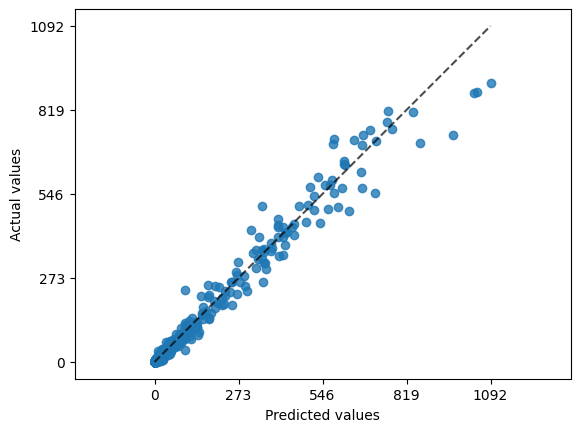

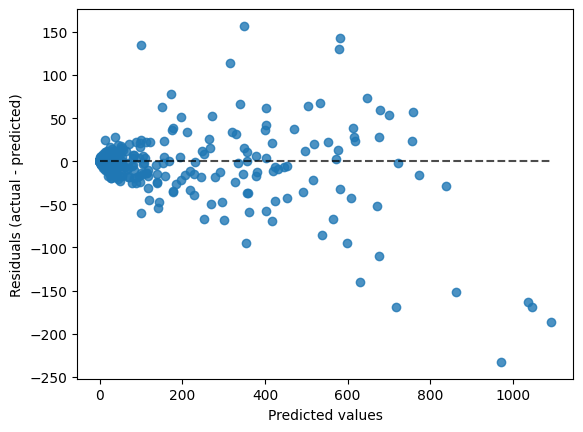

In [179]:
scatter_plot(real_values_ewm12h, predictions_ewm12h)

Çıkarım: "rollin_mean_3h" deneyinde karşılaştığımız "Heteroscedacity" burada da karşımıza çıktı. Scatter plot koni şeklinde bir dağılım göstermekte, yani tahmin etmemiz gereken değer büyüdükçe modelin hatası da büyüyor.

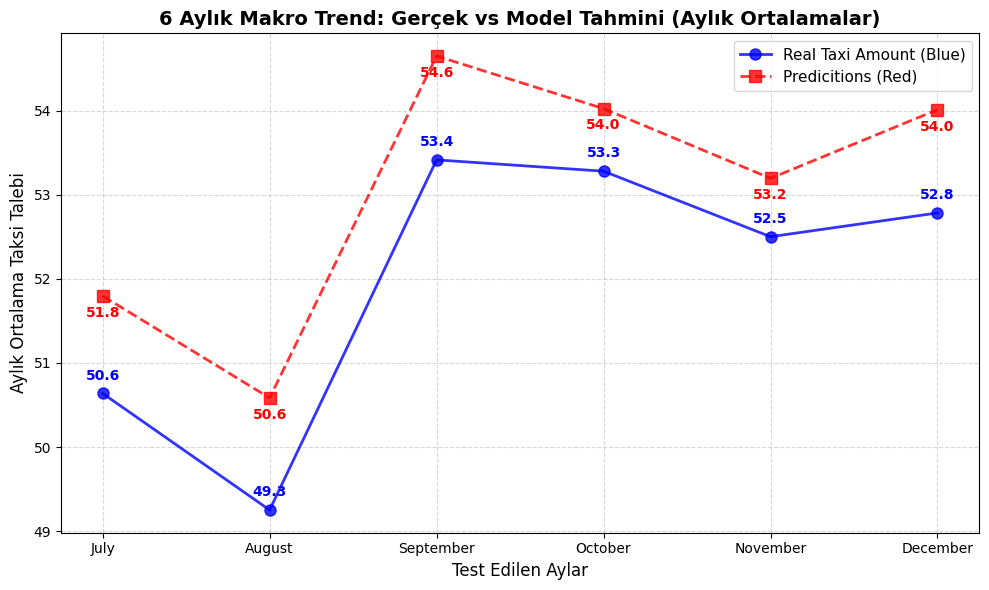

In [180]:
real_vs_prediction_plot(real_values_ewm12h, predictions_ewm12h)

Çıkarım: Model trend/pattern yakalamada yine gayet başarılı idi. "rollin_mean_3h" deneyinde karşılaştığımız overestimation burada da geçerli.

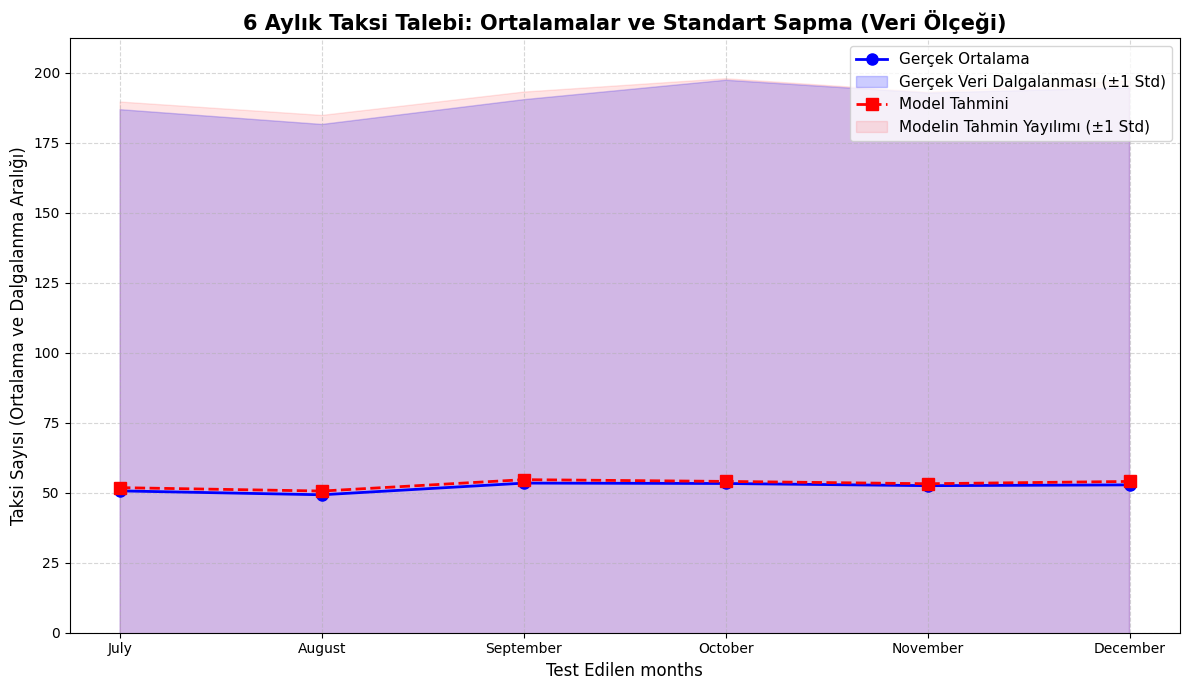

6 AYLIK VERİ ÖLÇEĞİ VE STANDART SAPMA ANALİZİ: REAL
July: Ortalama 50.6 Taksi | Standart Sapma: ±136.1 Taksi
August: Ortalama 49.3 Taksi | Standart Sapma: ±132.2 Taksi
September: Ortalama 53.4 Taksi | Standart Sapma: ±136.9 Taksi
October: Ortalama 53.3 Taksi | Standart Sapma: ±144.0 Taksi
November: Ortalama 52.5 Taksi | Standart Sapma: ±140.2 Taksi
December: Ortalama 52.8 Taksi | Standart Sapma: ±141.7 Taksi
6 AYLIK VERİ ÖLÇEĞİ VE STANDART SAPMA ANALİZİ: PREDICTED
July: Ortalama 51.8 Taksi | Standart Sapma: ±137.7 Taksi
August: Ortalama 50.6 Taksi | Standart Sapma: ±134.1 Taksi
September: Ortalama 54.6 Taksi | Standart Sapma: ±138.4 Taksi
October: Ortalama 54.0 Taksi | Standart Sapma: ±143.8 Taksi
November: Ortalama 53.2 Taksi | Standart Sapma: ±139.8 Taksi
December: Ortalama 54.0 Taksi | Standart Sapma: ±143.0 Taksi


In [181]:
real_vs_prediction_stdPlot(real_values_ewm12h, predictions_ewm12h)

Çıkarım: Modelin tahminleri sonucu oluşan standard sapma, gerçek standard sapma değerlerine yakın.

Son olarak söylemek gerekirse, model bu veriden de iyi bir şekilde faydalanıp karar ağaçlarını doğru oluşturmuştur. Final training için kullanılabilir.

- ewm_12h haftalık inceleme

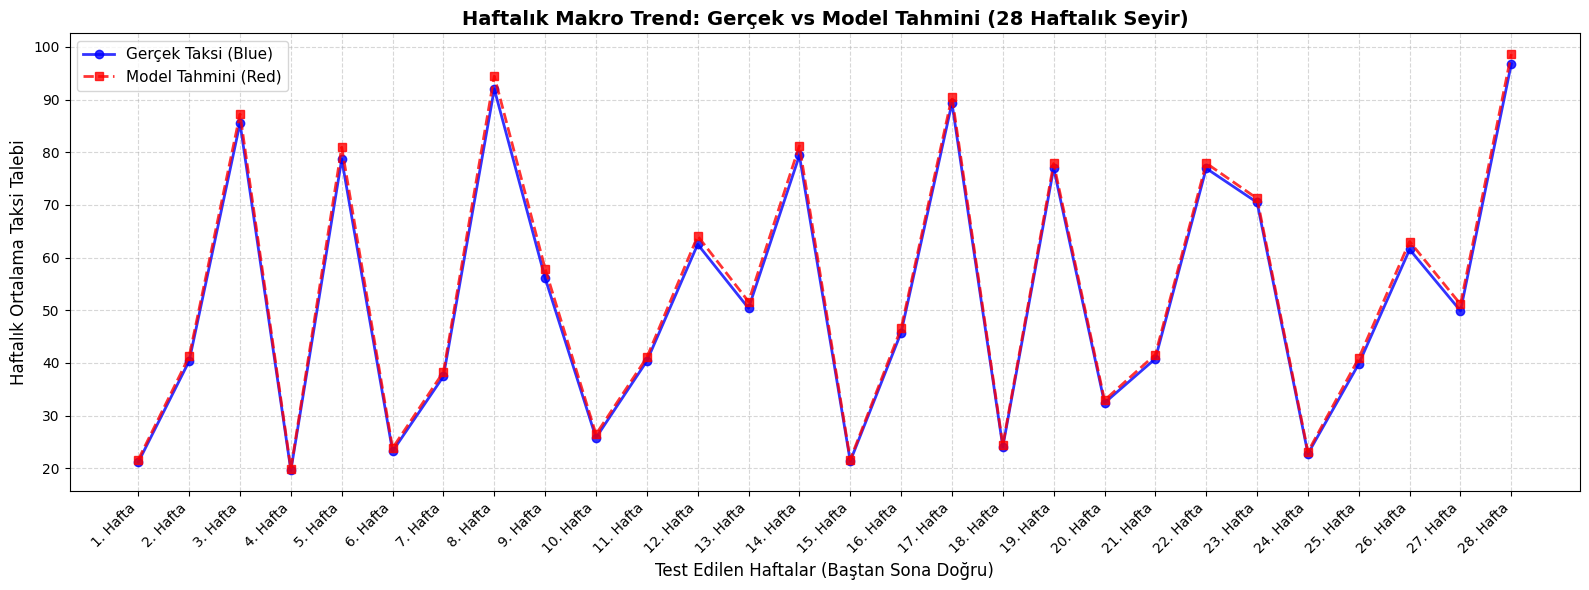

In [182]:
weekly_trend_plot(real_values_ewm12h, predictions_ewm12h)

rollin_mean_3h ile çok benzer bir grafik ortaya çıkardı.

- ewm_12h günlük inceleme (ortalama)

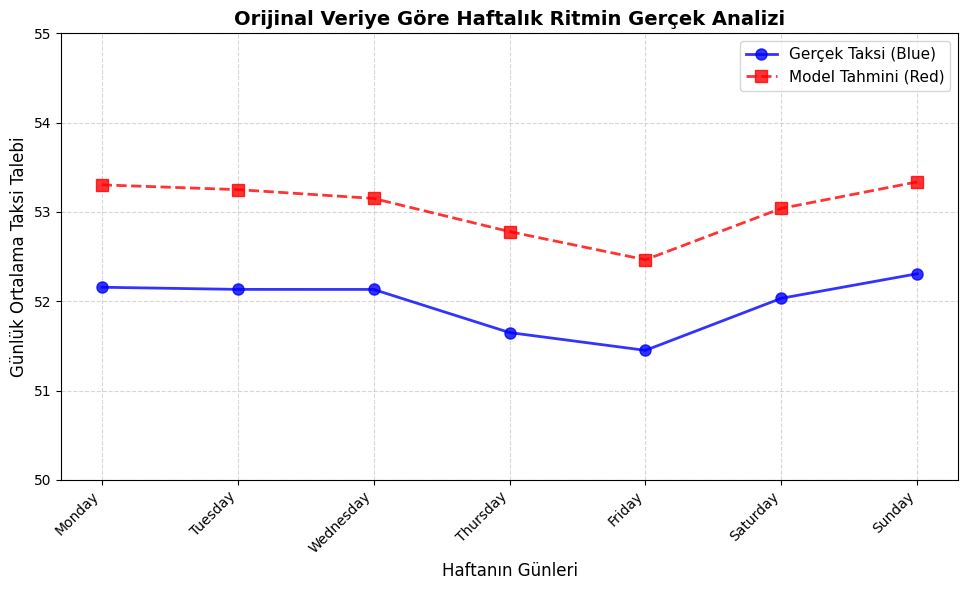

In [196]:
test_data = df[(df["month_index"] >= 19) & (df["month_index"] <= 24)].copy()
bulletproof_daily_trend(test_data, real_values_ewm12h, predictions_ewm12h)

- lag_168h

In [184]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error
import numpy as np
import pandas as pd

FEATURES = ["is_weekdays", 
            "is_weekend", 
            "is_night_life", 
            "is_morning_rush", 
            "is_evening_rush", 
            "is_midday_break", 
            "hour_sin", 
            "hour_cos", 
            "day_of_week_sin", 
            "day_of_week_cos",
            "seasons_sin", 
            "lag_168h",   # esas deney odağı
            "rolling_std_12h",
            "PULocationID"
            ]

TARGET = "trip_count"

lgb_scores_lag168h = [] # modelin yaptığı tahminlere göre mae değerleri burada tutulacak
all_predictions = []    # modelin yaptığı saf tahminleri burada biriktireceğim
all_real_values = []    # Bu tahminlere karşılık gerçek değerler burada olacak

for last_month_index in range(18, 24):  # Expanding Window
    train_set = df[df["month_index"] <= last_month_index]
    test_set = df[df["month_index"] == last_month_index + 1]

    x_train = train_set[FEATURES].copy().astype("float32")
    x_train["PULocationID"] = x_train["PULocationID"].astype("int32")
    x_train.loc[x_train["PULocationID"] >= 250, "PULocationID"] = 250   # LocationID 250'den sonrasını tek bir label yaptım yoksa bin sayısı GPU'ya sığmıyor.
    y_train = train_set[TARGET].copy().astype("float32")

    x_test = test_set[FEATURES].copy().astype("float32")
    x_test["PULocationID"] = x_test["PULocationID"].astype("int32")
    x_test.loc[x_test["PULocationID"] >= 250, "PULocationID"] = 250 # LocationID 250'den sonrasını tek bir label yaptım yoksa bin sayısı GPU'ya sığmıyor.
    y_test = test_set[TARGET].copy().astype("float32")

    lg_model_lag168h = lgb.LGBMRegressor(
        n_estimators=5000,
        learning_rate=0.01,
        max_depth=6,
        device_type='gpu',
        random_state=42,
    )

    lg_model_lag168h.fit(
        x_train, y_train,
        eval_set=[(x_test, y_test)],
        callbacks=[lgb.early_stopping(stopping_rounds=25)],
        categorical_feature=["PULocationID"]    # Location ID ler aslında bir büyüklük değil, etiket. ID 200, ID 100'ün 2 katı değil!
    )

    current_estimations = lg_model_lag168h.predict(x_test)
    current_estimations[current_estimations < 0] = 0    # negaitfleri sıfırladim
    mistake = mean_absolute_error(y_test, current_estimations)
    lgb_scores_lag168h.append(mistake)

    all_predictions.extend(current_estimations)
    all_real_values.extend(y_test.values)

    print(f"Ay {last_month_index + 1} İçin Başarı Skoru (MAE): {mistake:.2f} Taksi")

print("=" * 20)
print(f"Tüm ayların ortalama hatası: {np.mean(lgb_scores_lag168h):.2f} Taksi")

predictions_lag168h = np.array(all_predictions)
real_values_lag168h = np.array(all_real_values)

print(f"Model tahminleri predictions_lag168h içersinde (Toplam {len(predictions_lag168h)} satır veri korundu!)")

[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 817
[LightGBM] [Info] Number of data points in the train set: 3434400, number of used features: 14
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 3050 Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 9 dense feature groups (39.30 MB) transferred to GPU in 0.045344 secs. 1 sparse feature groups
[LightGBM] [Info] Start training from score 61.261019
Training until validation scores don't improve for 25 rounds
Did not meet early stopping. Best iteration is:
[5000]	valid_0's l2: 606.924
Ay 19 İçin Başarı Skoru (MAE): 7.70 Taksi
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 817
[LightGBM] [Info] Number of data points in the train set: 3631560, number of used features: 14
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 

Yaptığım deneyler arasından en kötü MAE bu oldu. Bunun nedeni modelin tam 1 hafta öncesini çok sert bir şekilde kullanması ve yakın zamanı görememesidir.

- standard deviation

In [185]:
np.std(lgb_scores_lag168h)

np.float64(0.9444452086244881)

In [209]:
print(f"lag_168h RMSE: {root_mean_squared_error(real_values_lag168h, predictions_lag168h)}")   #* RMSE

lag_168h RMSE: 25.123654354808885


In [210]:
print(f"lag_168h R^2: {r2_score(real_values_lag168h, predictions_lag168h)}")   #* R^2

lag_168h R^2: 0.9671325573503916


Çıkarım: standard sapma en kötü bu metrik için geldi, körlemesine sadece geçen haftaya odaklanmasından bu sonucu çıkarabiliriz.

In [186]:
numerator = np.sum(np.abs(real_values_lag168h - predictions_lag168h))
denominator = np.sum(np.abs(real_values_lag168h))

WAPE = numerator / denominator
print(f"WAPE score for lag_168h is: %{WAPE * 100}")

WAPE score for lag_168h is: %15.4010385353075


doğal olarak en kötü weighted average percentage error

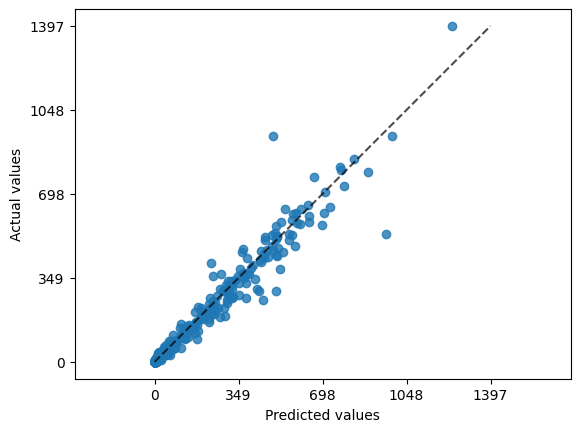

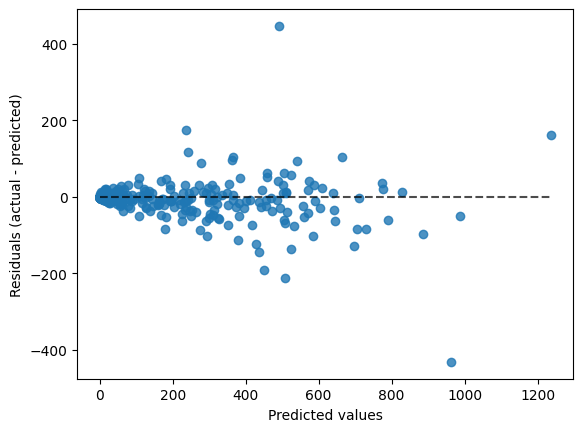

In [187]:
scatter_plot(real_values_lag168h, predictions_lag168h)

Çıkarım: Deneylerde hep korelasyonu birbirine yakın feature lar üzerinden deney yaptığımdan "Heteroscedatity" nin her seferinde karşımıza çıkması şaşırtıcı değil.

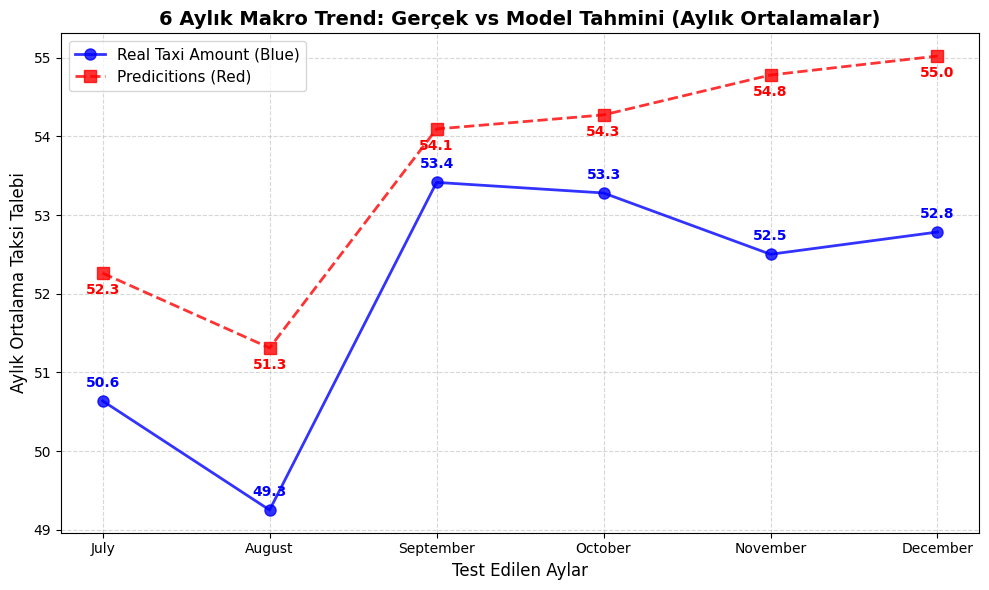

In [188]:
real_vs_prediction_plot(real_values_lag168h, predictions_lag168h)

Hata skoru en yüksek olan deney bu deney ve sonbahar ayında bir pattern kaybı görüyoruz. Bu kayıp MAE değerinin artmasına sebep olmuş olabilir.

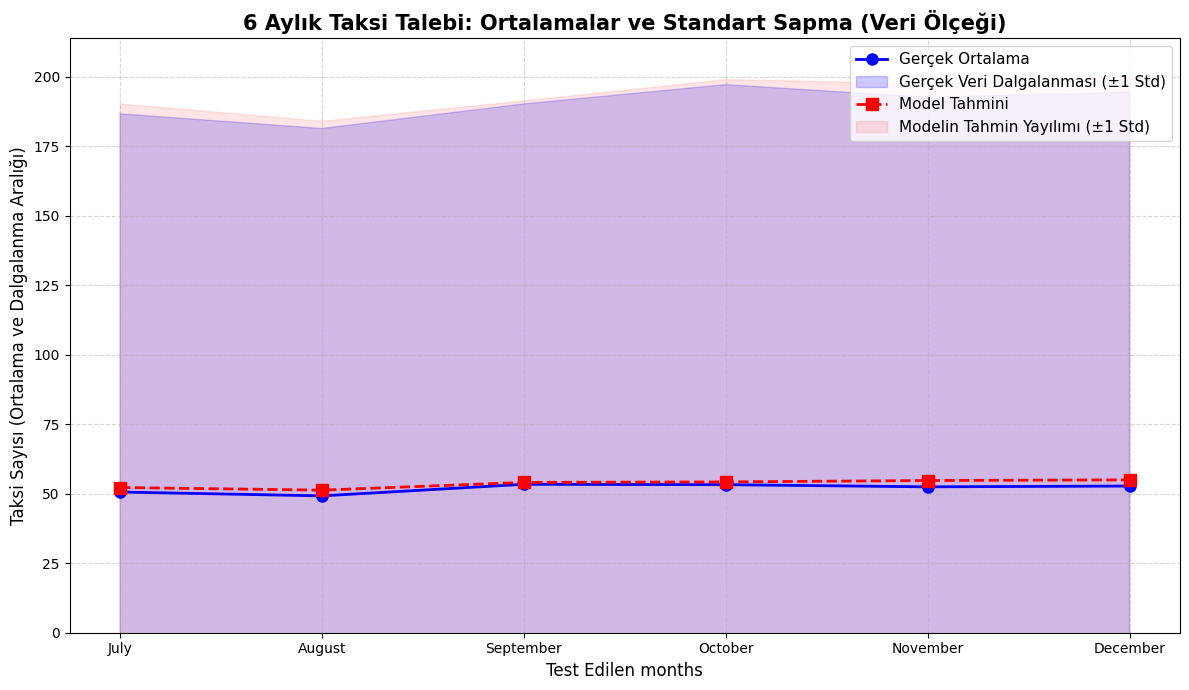

6 AYLIK VERİ ÖLÇEĞİ VE STANDART SAPMA ANALİZİ: REAL
July: Ortalama 50.6 Taksi | Standart Sapma: ±136.1 Taksi
August: Ortalama 49.3 Taksi | Standart Sapma: ±132.2 Taksi
September: Ortalama 53.4 Taksi | Standart Sapma: ±136.9 Taksi
October: Ortalama 53.3 Taksi | Standart Sapma: ±144.0 Taksi
November: Ortalama 52.5 Taksi | Standart Sapma: ±140.2 Taksi
December: Ortalama 52.8 Taksi | Standart Sapma: ±141.7 Taksi
6 AYLIK VERİ ÖLÇEĞİ VE STANDART SAPMA ANALİZİ: PREDICTED
July: Ortalama 52.3 Taksi | Standart Sapma: ±138.0 Taksi
August: Ortalama 51.3 Taksi | Standart Sapma: ±132.7 Taksi
September: Ortalama 54.1 Taksi | Standart Sapma: ±137.3 Taksi
October: Ortalama 54.3 Taksi | Standart Sapma: ±144.7 Taksi
November: Ortalama 54.8 Taksi | Standart Sapma: ±142.8 Taksi
December: Ortalama 55.0 Taksi | Standart Sapma: ±144.4 Taksi


In [189]:
real_vs_prediction_stdPlot(real_values_lag168h, predictions_lag168h)

Sonbaharda yaşanan pattern kaybı burada da karşımıza çıkıyor ama yine de satndard sapmalar yine birbirine yakın çıktı.

Final training için yine de bu özelliği kullanmak istiyorum. Bazı yerlerde pattern kaybı yaşansa da, model tahminleri le gerçek standard sapmaya yakın bir değer bulmuş ve gerçek değerlerden fazla uzaklaşmamış.

- lag_168h haftalık inceleme

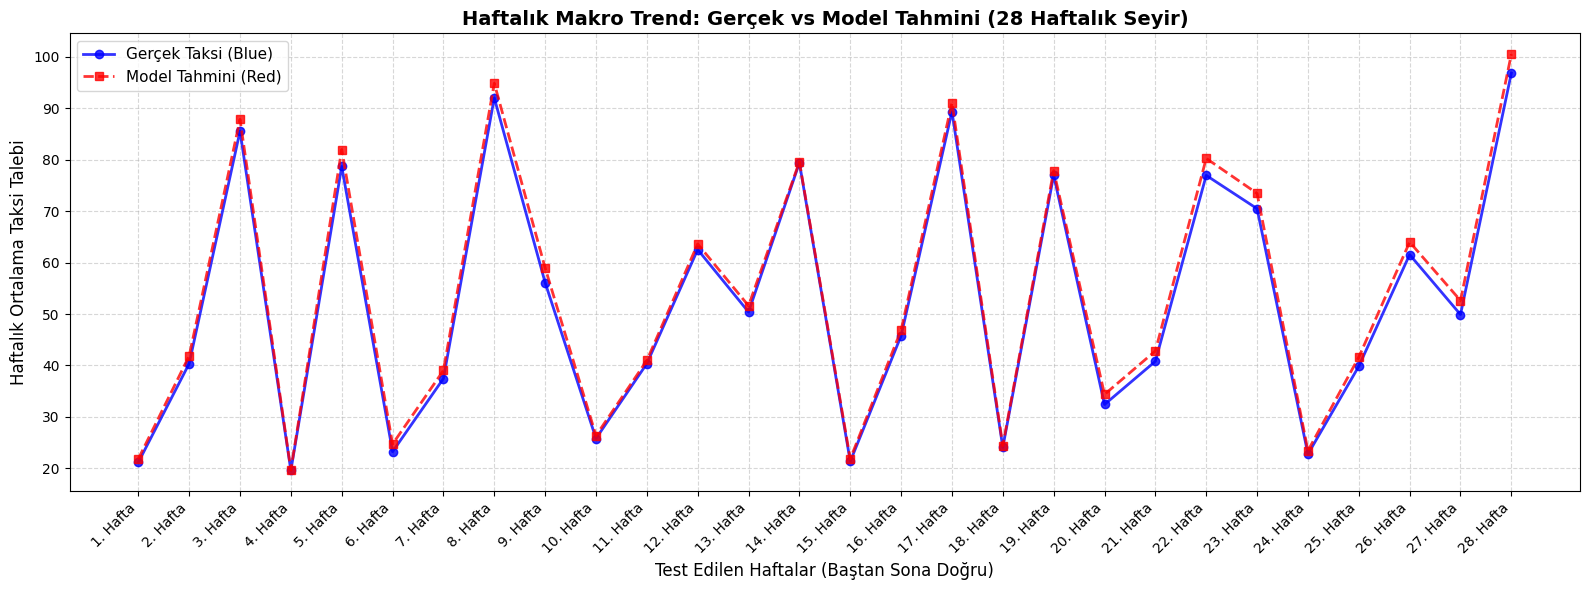

In [190]:
weekly_trend_plot(real_values_lag168h, predictions_lag168h)

çok küçük farklar ile aynı plot geldi.

- lag_168h günlük inceleme (ortalama)

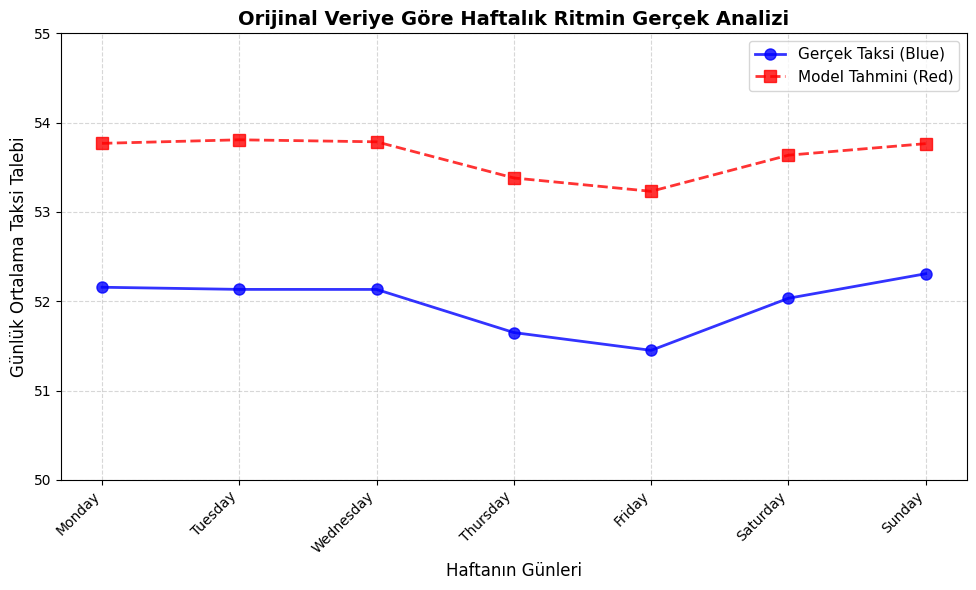

In [192]:
test_data = df[(df["month_index"] >= 19) & (df["month_index"] <= 24)].copy()
bulletproof_daily_trend(test_data, real_values_lag168h, predictions_lag168h)

- lag_24h

In [197]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error
import numpy as np
import pandas as pd

FEATURES = ["is_weekdays", 
            "is_weekend", 
            "is_night_life", 
            "is_morning_rush", 
            "is_evening_rush", 
            "is_midday_break", 
            "hour_sin", 
            "hour_cos", 
            "day_of_week_sin", 
            "day_of_week_cos",
            "seasons_sin", 
            "lag_24h",   # esas deney odağı
            "rolling_std_12h",
            "PULocationID"
            ]

TARGET = "trip_count"

lgb_scores_lag24h = [] # modelin yaptığı tahminlere göre mae değerleri burada tutulacak
all_predictions = []    # modelin yaptığı saf tahminleri burada biriktireceğim
all_real_values = []    # Bu tahminlere karşılık gerçek değerler burada olacak

for last_month_index in range(18, 24):  # Expanding Window
    train_set = df[df["month_index"] <= last_month_index]
    test_set = df[df["month_index"] == last_month_index + 1]

    x_train = train_set[FEATURES].copy().astype("float32")
    x_train["PULocationID"] = x_train["PULocationID"].astype("int32")
    x_train.loc[x_train["PULocationID"] >= 250, "PULocationID"] = 250   # LocationID 250'den sonrasını tek bir label yaptım yoksa bin sayısı GPU'ya sığmıyor.
    y_train = train_set[TARGET].copy().astype("float32")

    x_test = test_set[FEATURES].copy().astype("float32")
    x_test["PULocationID"] = x_test["PULocationID"].astype("int32")
    x_test.loc[x_test["PULocationID"] >= 250, "PULocationID"] = 250 # LocationID 250'den sonrasını tek bir label yaptım yoksa bin sayısı GPU'ya sığmıyor.
    y_test = test_set[TARGET].copy().astype("float32")

    lg_model_lag24h = lgb.LGBMRegressor(
        n_estimators=5000,
        learning_rate=0.01,
        max_depth=6,
        device_type='gpu',
        random_state=42,
    )

    lg_model_lag24h.fit(
        x_train, y_train,
        eval_set=[(x_test, y_test)],
        callbacks=[lgb.early_stopping(stopping_rounds=25)],
        categorical_feature=["PULocationID"]    # Location ID ler aslında bir büyüklük değil, etiket. ID 200, ID 100'ün 2 katı değil!
    )

    current_estimations = lg_model_lag24h.predict(x_test)
    current_estimations[current_estimations < 0] = 0    # negaitfleri sıfırladim
    mistake = mean_absolute_error(y_test, current_estimations)
    lgb_scores_lag24h.append(mistake)

    all_predictions.extend(current_estimations)
    all_real_values.extend(y_test.values)

    print(f"Ay {last_month_index + 1} İçin Başarı Skoru (MAE): {mistake:.2f} Taksi")

print("=" * 20)
print(f"Tüm ayların ortalama hatası: {np.mean(lgb_scores_lag24h):.2f} Taksi")

predictions_lag24h = np.array(all_predictions)
real_values_lag24h = np.array(all_real_values)

print(f"Model tahminleri predictions_lag24h içersinde (Toplam {len(predictions_lag24h)} satır veri korundu!)")

[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 817
[LightGBM] [Info] Number of data points in the train set: 3434400, number of used features: 14
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 3050 Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 9 dense feature groups (39.30 MB) transferred to GPU in 0.049908 secs. 1 sparse feature groups
[LightGBM] [Info] Start training from score 61.261019
Training until validation scores don't improve for 25 rounds
Did not meet early stopping. Best iteration is:
[4999]	valid_0's l2: 525.04
Ay 19 İçin Başarı Skoru (MAE): 7.27 Taksi
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 817
[LightGBM] [Info] Number of data points in the train set: 3631560, number of used features: 14
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 3

- standard deviation

In [198]:
np.std(lgb_scores_lag24h)

np.float64(0.5938799111543506)

In [199]:
numerator = np.sum(np.abs(real_values_lag24h - predictions_lag24h))
denominator = np.sum(np.abs(real_values_lag24h))

WAPE = numerator / denominator
print(f"WAPE score for lag_24h is: %{WAPE * 100}")

WAPE score for lag_24h is: %14.139837999895994


In [211]:
print(f"lag_24h RMSE: {root_mean_squared_error(real_values_lag24h, predictions_lag24h)}")   #* RMSE

lag_24h RMSE: 22.92434592782683


In [212]:
print(f"lag_24h R^2: {r2_score(real_values_lag24h, predictions_lag24h)}")   #* R^2

lag_24h R^2: 0.9726350788713396


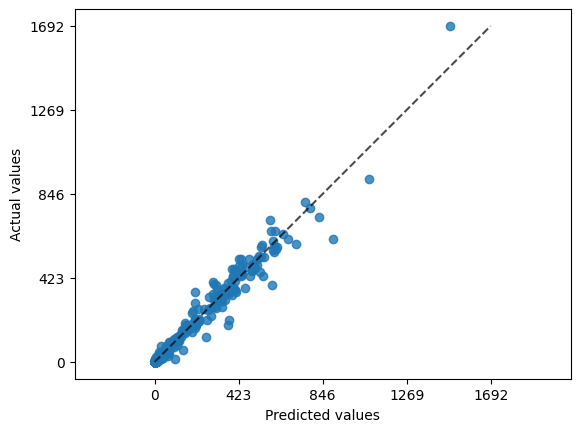

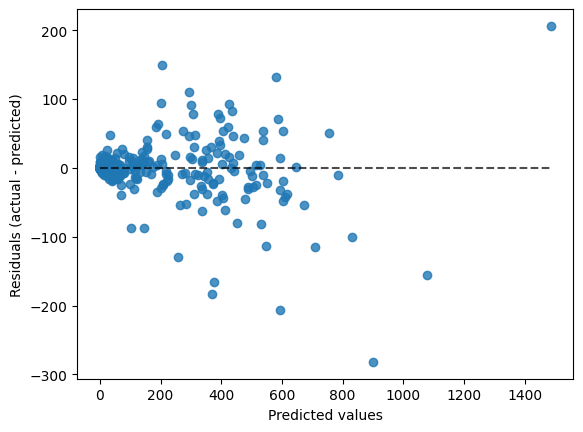

In [200]:
scatter_plot(real_values_lag24h, predictions_lag24h)

Buradan sadece düne bakmanın zararlarını görüyoruz. Haftanın günlerinde talep edilen taksi sayısı farklılık arz eder. Özellikle hafatiçi ve sonu geçişlerinde bu daha da serttir. Eğer model sadece dün verisine bakarak, hem yakın saat verisini hem de geçen hafta aynı gün ne olduğunun verisini göremezse hatalı tahminlere erken başlar.

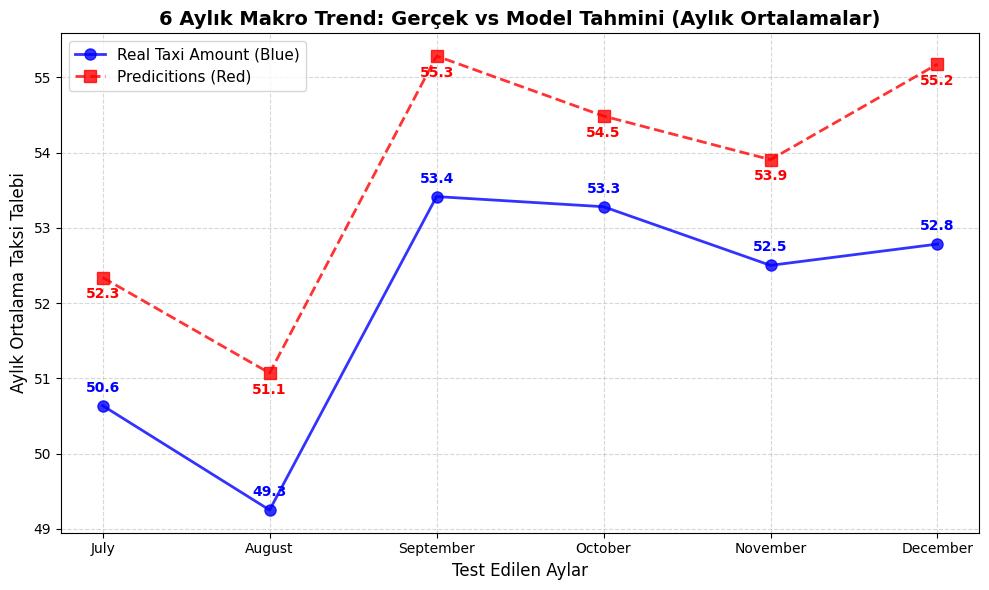

In [201]:
real_vs_prediction_plot(real_values_lag24h, predictions_lag24h)

Çıkarım: lag_24h, lag_168h'a göre pattern yakalamada daha iyi.

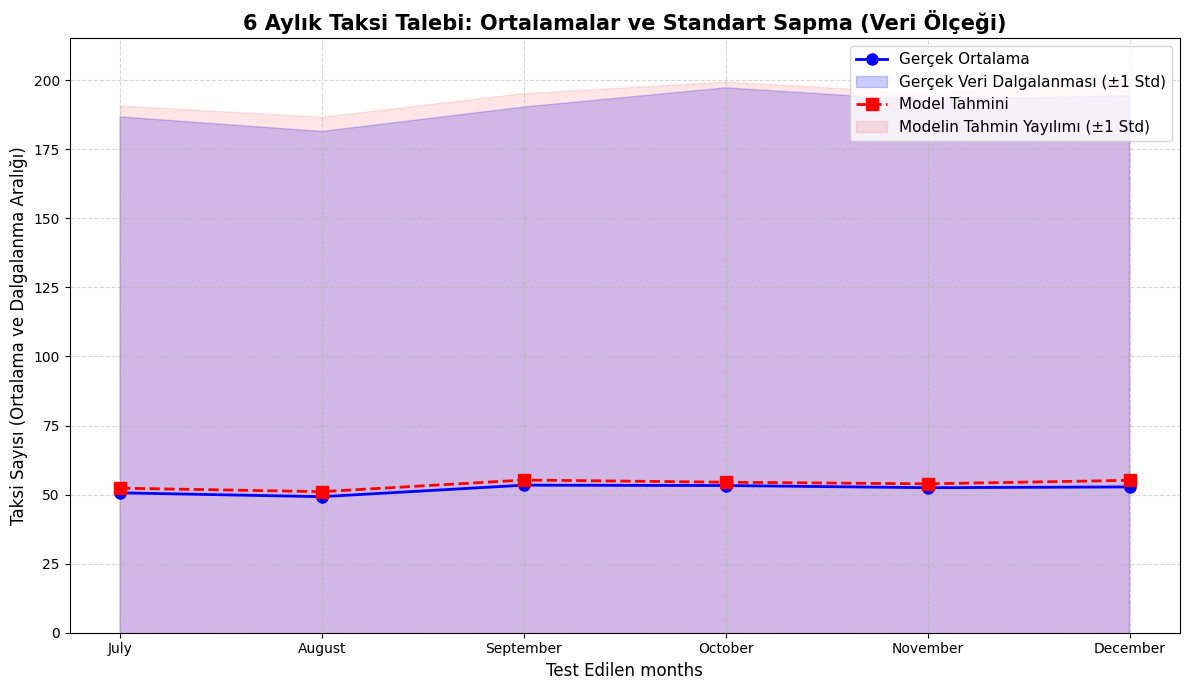

6 AYLIK VERİ ÖLÇEĞİ VE STANDART SAPMA ANALİZİ: REAL
July: Ortalama 50.6 Taksi | Standart Sapma: ±136.1 Taksi
August: Ortalama 49.3 Taksi | Standart Sapma: ±132.2 Taksi
September: Ortalama 53.4 Taksi | Standart Sapma: ±136.9 Taksi
October: Ortalama 53.3 Taksi | Standart Sapma: ±144.0 Taksi
November: Ortalama 52.5 Taksi | Standart Sapma: ±140.2 Taksi
December: Ortalama 52.8 Taksi | Standart Sapma: ±141.7 Taksi
6 AYLIK VERİ ÖLÇEĞİ VE STANDART SAPMA ANALİZİ: PREDICTED
July: Ortalama 52.3 Taksi | Standart Sapma: ±138.3 Taksi
August: Ortalama 51.1 Taksi | Standart Sapma: ±135.5 Taksi
September: Ortalama 55.3 Taksi | Standart Sapma: ±139.9 Taksi
October: Ortalama 54.5 Taksi | Standart Sapma: ±144.8 Taksi
November: Ortalama 53.9 Taksi | Standart Sapma: ±141.3 Taksi
December: Ortalama 55.2 Taksi | Standart Sapma: ±145.4 Taksi


In [202]:
real_vs_prediction_stdPlot(real_values_lag24h, predictions_lag24h)

Çıkarım: Model gerçek verilere yakın standard sapma ile tahminde bulunmuş ve final training için kullanacağım.

- lag_24h haftalık inceleme

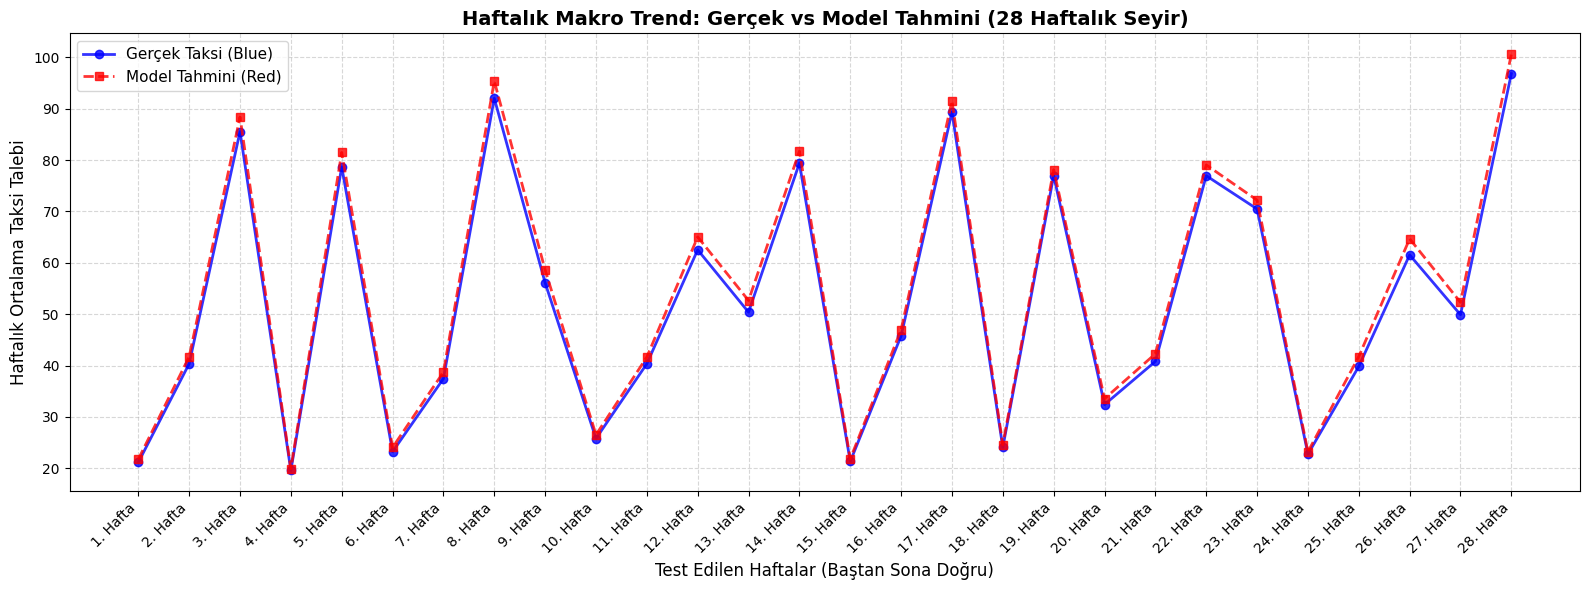

In [203]:
weekly_trend_plot(real_values_lag24h, predictions_lag24h)

çok küçük farklar ile aynı plot karşılıyor bizi.

- lag_24h günlük inceleme (ortalama)

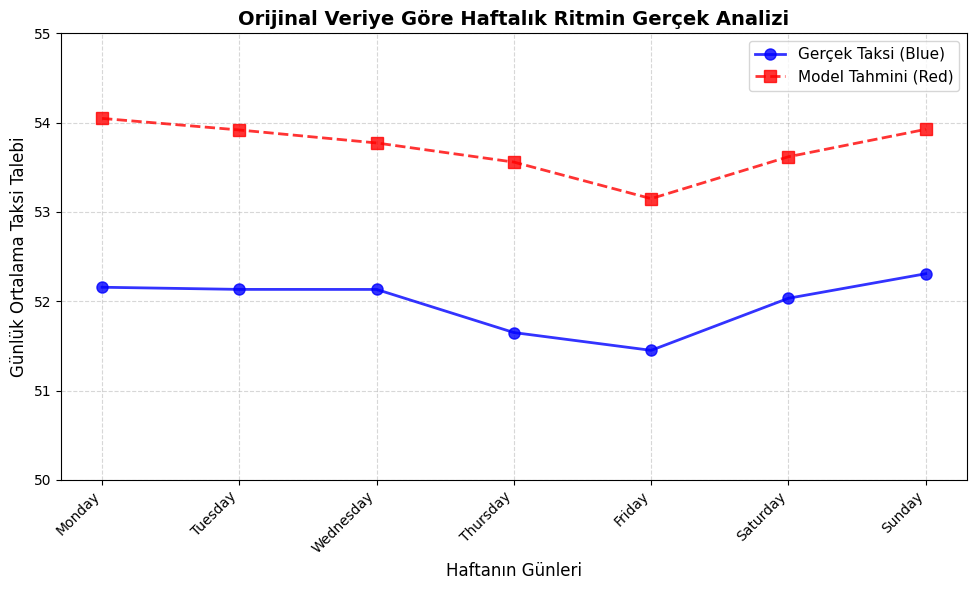

In [204]:
bulletproof_daily_trend(test_data, real_values_lag24h, predictions_lag24h)

### After Ablation Studies

In [107]:
df.columns

Index(['pickup_hour', 'PULocationID', 'trip_count', 'hour', 'day_of_week',
       'month', 'is_weekdays', 'is_weekend', 'is_working_hours',
       'is_business_hour', 'is_night_life', 'seasons', 'is_morning_rush',
       'is_evening_rush', 'is_midday_break', 'hour_sin', 'hour_cos',
       'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos',
       'seasons_sin', 'seasons_cos', 'rollin_mean_3h', 'rolling_std_12h',
       'lag_24h', 'lag_168h', 'ewm_12h', 'month_index'],
      dtype='object')

In [73]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error
import numpy as np
import pandas as pd

FEATURES = ["is_weekdays", 
            "is_weekend", 
            "is_night_life", 
            "is_morning_rush", 
            "is_evening_rush", 
            "is_midday_break", 
            "hour_sin", 
            "hour_cos", 
            "day_of_week_sin", 
            "day_of_week_cos",
            "seasons_sin", 
            "lag_24h",
            "rolling_std_12h",
            "PULocationID",
            "rollin_mean_3h",
            "lag_168h",
            "ewm_12h"
            ]

TARGET = "trip_count"

lgb_scores_all = [] # modelin yaptığı tahminlere göre mae değerleri burada tutulacak
all_predictions = []    # modelin yaptığı saf tahminleri burada biriktireceğim
all_real_values = []    # Bu tahminlere karşılık gerçek değerler burada olacak
train_r2_scores = []    # Train R^2 values

for last_month_index in range(18, 24):  # Expanding Window
    train_set = df[df["month_index"] <= last_month_index]
    test_set = df[df["month_index"] == last_month_index + 1]

    x_train = train_set[FEATURES].copy().astype("float32")
    x_train["PULocationID"] = x_train["PULocationID"].astype("int32")
    x_train.loc[x_train["PULocationID"] >= 250, "PULocationID"] = 250   # LocationID 250'den sonrasını tek bir label yaptım yoksa bin sayısı GPU'ya sığmıyor.
    y_train = train_set[TARGET].copy().astype("float32")

    x_test = test_set[FEATURES].copy().astype("float32")
    x_test["PULocationID"] = x_test["PULocationID"].astype("int32")
    x_test.loc[x_test["PULocationID"] >= 250, "PULocationID"] = 250 # LocationID 250'den sonrasını tek bir label yaptım yoksa bin sayısı GPU'ya sığmıyor.
    y_test = test_set[TARGET].copy().astype("float32")

    lgb_model_all = lgb.LGBMRegressor(
        n_estimators=5000,
        learning_rate=0.01,
        max_depth=6,
        device_type='gpu',
        random_state=42,
    )

    lgb_model_all.fit(
        x_train, y_train,
        eval_set=[(x_test, y_test)],
        callbacks=[lgb.early_stopping(stopping_rounds=25)],
        categorical_feature=["PULocationID"]    # Location ID ler aslında bir büyüklük değil, etiket. ID 200, ID 100'ün 2 katı değil!
    )

    current_estimations = lgb_model_all.predict(x_test)
    current_estimations[current_estimations < 0] = 0    # negaitfleri sıfırladim
    mistake = mean_absolute_error(y_test, current_estimations)
    lgb_scores_all.append(mistake)

    all_predictions.extend(current_estimations)
    all_real_values.extend(y_test.values)

    print(f"Ay {last_month_index + 1} İçin Başarı Skoru (MAE): {mistake:.2f} Taksi")

print("=" * 20)
print(f"Tüm ayların ortalama hatası: {np.mean(lgb_scores_all):.2f} Taksi")

predictions_all = np.array(all_predictions)
real_values_all = np.array(all_real_values)

print(f"Model tahminleri predictions_all içersinde (Toplam {len(predictions_all)} satır veri korundu!)")

[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 1582
[LightGBM] [Info] Number of data points in the train set: 3434400, number of used features: 17
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 3050 Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 12 dense feature groups (39.30 MB) transferred to GPU in 0.040826 secs. 1 sparse feature groups
[LightGBM] [Info] Start training from score 61.261019
Training until validation scores don't improve for 25 rounds
Did not meet early stopping. Best iteration is:
[5000]	valid_0's l2: 365.514
Ay 19 İçin Başarı Skoru (MAE): 6.18 Taksi
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 1582
[LightGBM] [Info] Number of data points in the train set: 3631560, number of used features: 17
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce R

In [74]:
np.std(lgb_scores_all)  #! STANDART SAPMA

np.float64(0.5878505196931947)

In [75]:
numerator = np.sum(np.abs(real_values_all - predictions_all))
denominator = np.sum(np.abs(real_values_all))

WAPE = numerator / denominator
print(f"WAPE score for all is: %{WAPE * 100}")

WAPE score for all is: %11.859303799649327


In [77]:
from sklearn.metrics import root_mean_squared_error
print(f"all RMSE: {root_mean_squared_error(real_values_all, predictions_all)}")   #* RMSE

all RMSE: 18.984552018388886


In [226]:
print(f"all R^2: {r2_score(real_values_all, predictions_all)}")   #* R^2

all R^2: 0.9811938447207351


Çıkarım: Deney feature lar beraber kullanıldığında en iyi MAE sonucu elde edildi.

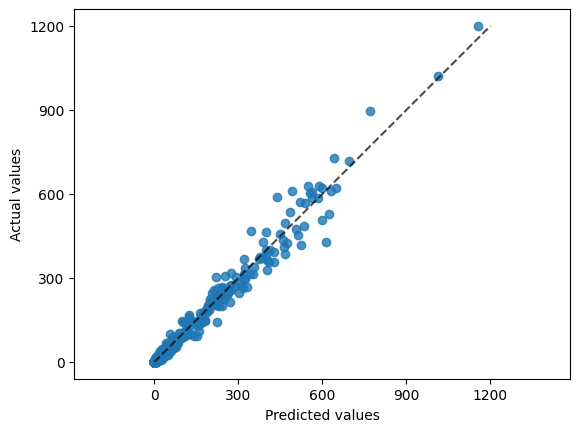

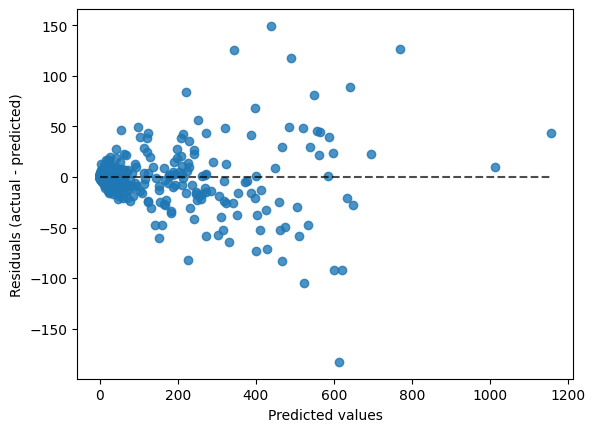

In [217]:
scatter_plot(real_values_all, predictions_all)

Heteroscedacity görüldü.

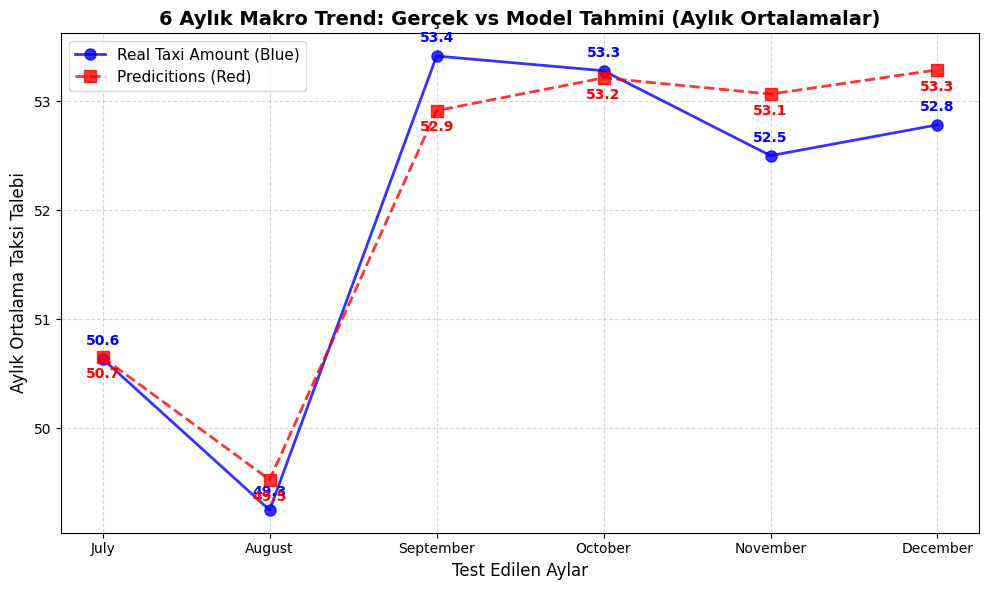

In [218]:
real_vs_prediction_plot(real_values_all, predictions_all)

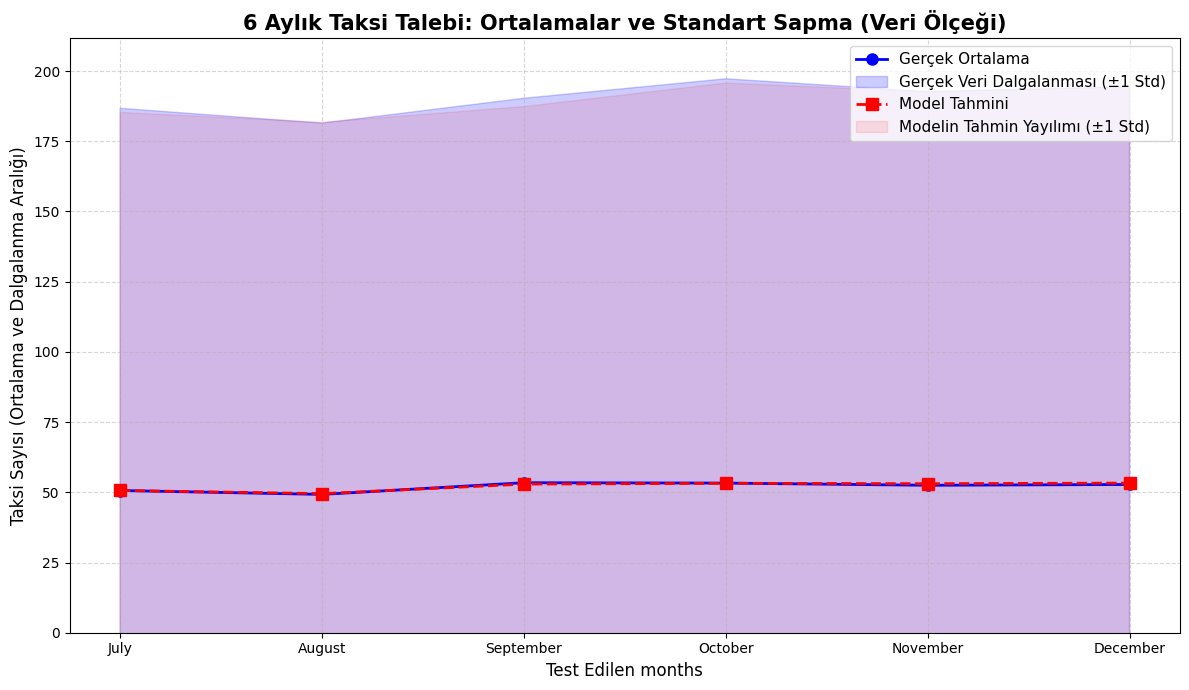

6 AYLIK VERİ ÖLÇEĞİ VE STANDART SAPMA ANALİZİ: REAL
July: Ortalama 50.6 Taksi | Standart Sapma: ±136.1 Taksi
August: Ortalama 49.3 Taksi | Standart Sapma: ±132.2 Taksi
September: Ortalama 53.4 Taksi | Standart Sapma: ±136.9 Taksi
October: Ortalama 53.3 Taksi | Standart Sapma: ±144.0 Taksi
November: Ortalama 52.5 Taksi | Standart Sapma: ±140.2 Taksi
December: Ortalama 52.8 Taksi | Standart Sapma: ±141.7 Taksi
6 AYLIK VERİ ÖLÇEĞİ VE STANDART SAPMA ANALİZİ: PREDICTED
July: Ortalama 50.7 Taksi | Standart Sapma: ±134.6 Taksi
August: Ortalama 49.5 Taksi | Standart Sapma: ±132.2 Taksi
September: Ortalama 52.9 Taksi | Standart Sapma: ±134.4 Taksi
October: Ortalama 53.2 Taksi | Standart Sapma: ±142.5 Taksi
November: Ortalama 53.1 Taksi | Standart Sapma: ±139.6 Taksi
December: Ortalama 53.3 Taksi | Standart Sapma: ±141.1 Taksi


In [219]:
real_vs_prediction_stdPlot(real_values_all, predictions_all)

Çıkarım: standart sapmalar birbirine yakın geldi.

- all haftalık inceleme

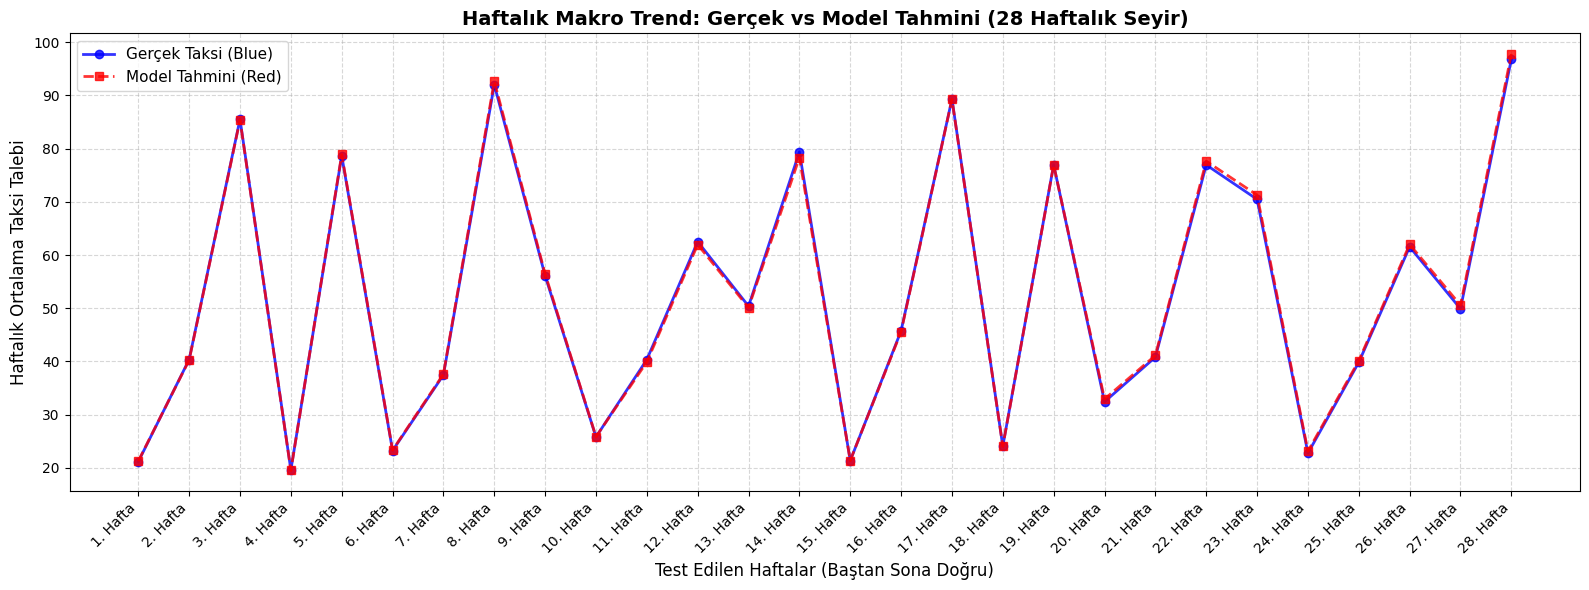

In [220]:
weekly_trend_plot(real_values_all, predictions_all)

değerler çok çok daha yakın.

- all günlük inceleme (ortalama)

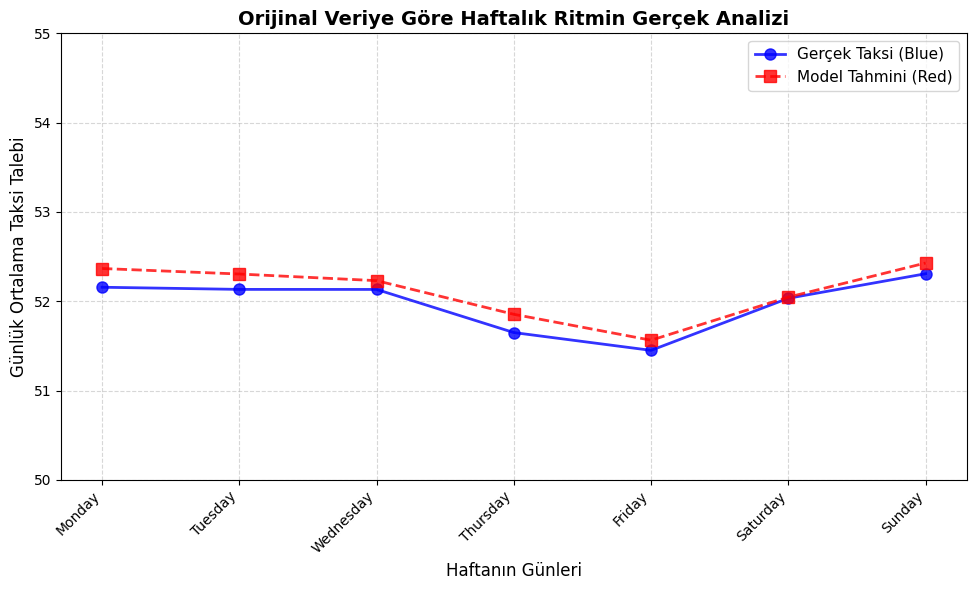

In [221]:
bulletproof_daily_trend(test_data, real_values_all, predictions_all)

Final: Gün bazında en yakın plot!

In [224]:
lgb_model_all.booster_.save_model("LightGBM_after_ablation.txt")
print("son model kaydedildi!")

son model kaydedildi!


### Feature Importance of LightGBM

- Plot feature importance using Gain

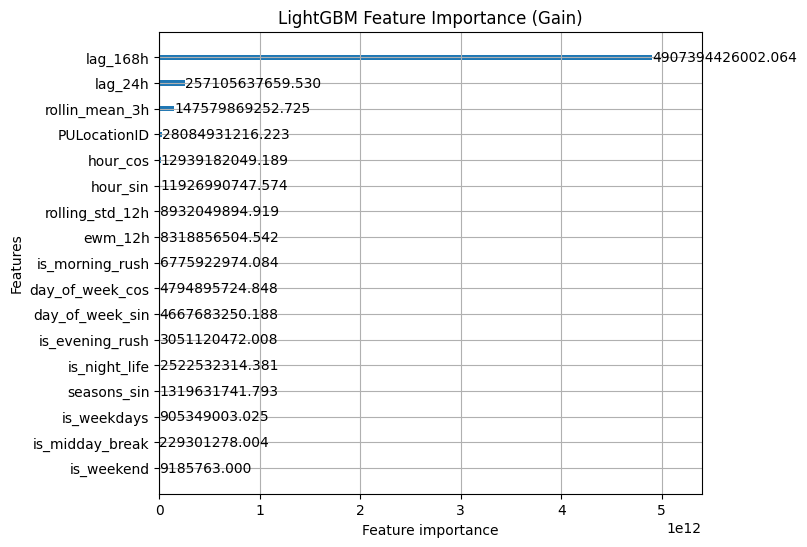

In [78]:
# Plot feature importance using Gain
lgb.plot_importance(lgb_model_all, importance_type="gain", figsize=(7,6), title="LightGBM Feature Importance (Gain)")
plt.show()

Çıkarım: Ablation deneylerinde sadece lag_168h kullandığımız deneyde iyi sonuçlar gelmemişti. Burada lag_168h "gain accuracy" açısından en önemli feature olarak gözükebilir ama modelin  başarısında diğer özelliklerin etkisi yadsınamaz.

- Plot feature importance using Split

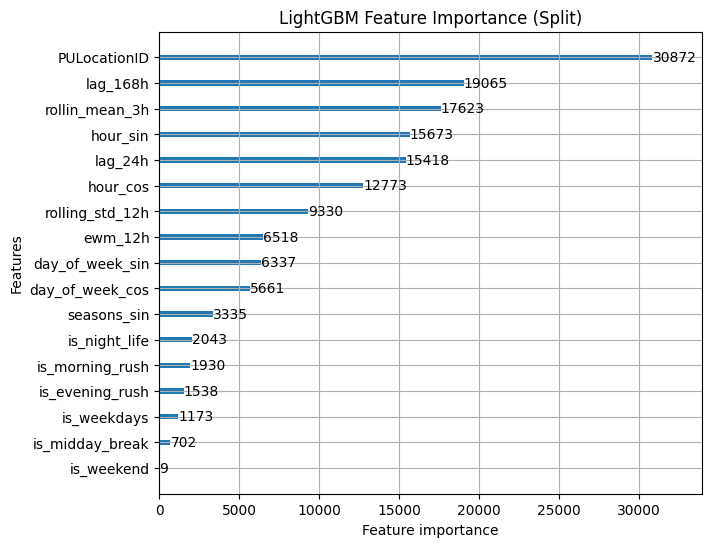

In [79]:
lgb.plot_importance(lgb_model_all, importance_type="split", figsize=(7,6), title="LightGBM Feature Importance (Split)")
plt.show()

LightGBM kategorik veri işlerken "Graph Coloring" algoritması kullanır. Her node bir lokasyon gibi düşünülebilir aslında. Bu grafikten de aslında model tahmin yaparken lokasyonları ne kadar ciddiye aldığını görebiliriz. "PULocationID" kategorik kabul edilmiş ve ona göre split işlemleri yapılmış.

### SHAP

SHAP game theory mantığı ile black box modellerin kaputun altında hangi metrikleri nasıl kullandığını verir. Feature Importance için kullanılır.

In [73]:
import lightgbm as lgb 
loaded_lgball_model = lgb.Booster(model_file="LightGBM_after_ablation.txt")
print("LGB modeli tamam!")

LGB modeli tamam!


In [76]:
FEATURES = ["is_weekdays", 
            "is_weekend", 
            "is_night_life", 
            "is_morning_rush", 
            "is_evening_rush", 
            "is_midday_break", 
            "hour_sin", 
            "hour_cos", 
            "day_of_week_sin", 
            "day_of_week_cos",
            "seasons_sin", 
            "lag_24h",
            "rolling_std_12h",
            "PULocationID",
            "rollin_mean_3h",
            "lag_168h",
            "ewm_12h"
            ]

import shap
x_test_sampled = df[df["month_index"] > 18][FEATURES].sample(n=10000, random_state=42).astype("float32")    # modeli eğitmiyoruz, Central Limit Theorem vasıtası ile sadece 10k satırda hangi tepkiyi verecek onu ölçmek istiyoruz.

explainer = shap.TreeExplainer(loaded_lgball_model)
shap_values = explainer(x_test_sampled) 

shap.initjs()
print("SHAP explainer hazır!")

SHAP explainer hazır!


- Waterfall Model

Test verisinde SADECE TEK BİR SATIRI açıklar. Mesela 0.index verdiğimizde 1M veri içinden ilk satırın tahmini için hangi değerlerin önemli olduğu plot edilir. Satır bazlı incelemelerde işe yarar.

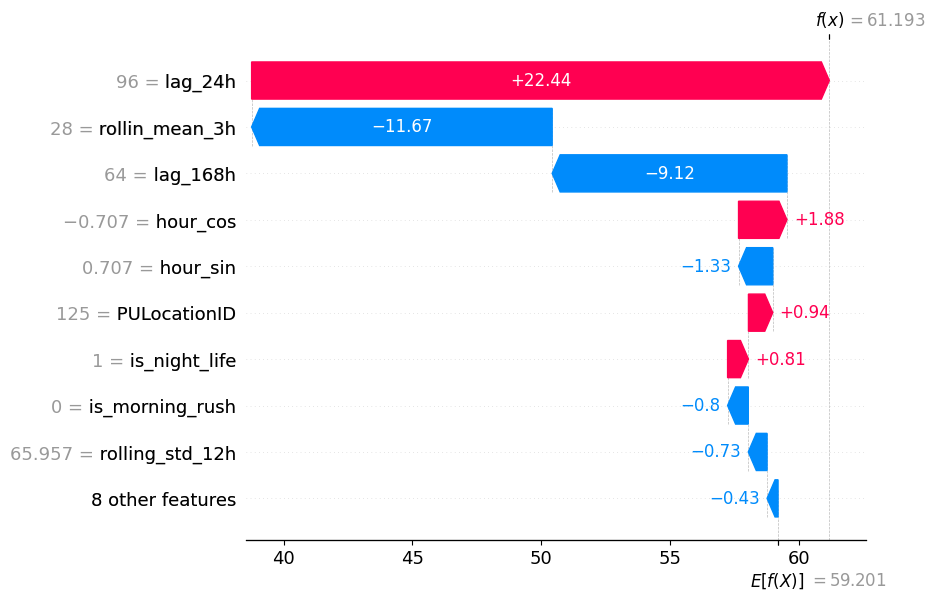

In [77]:
shap.waterfall_plot(shap_values[0])

- bar plot

GENEL YAKLAŞIM. LightGBM built-in feature importance plot ile aynıdır. Klasik Feature Importance Plot.

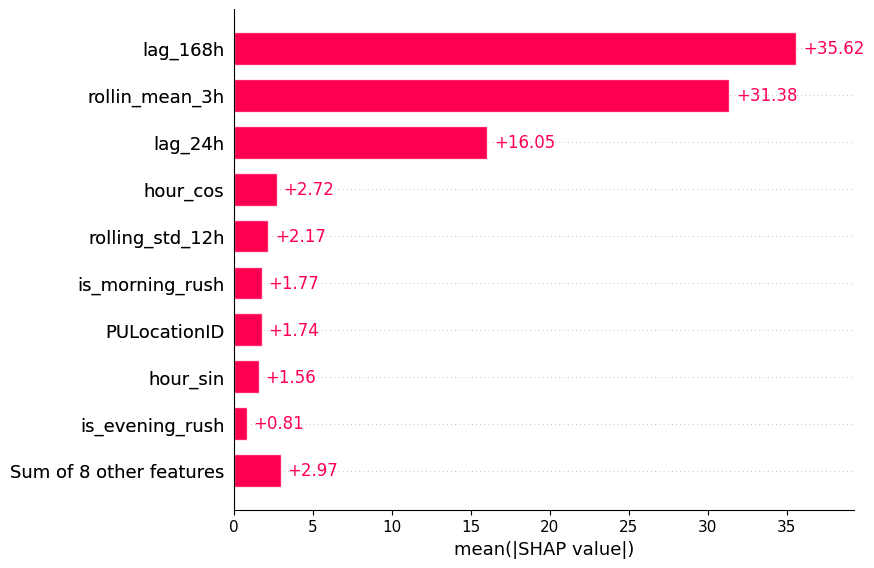

In [78]:
shap.plots.bar(shap_values)

- force plot

Waterfall modelin yatay hali.

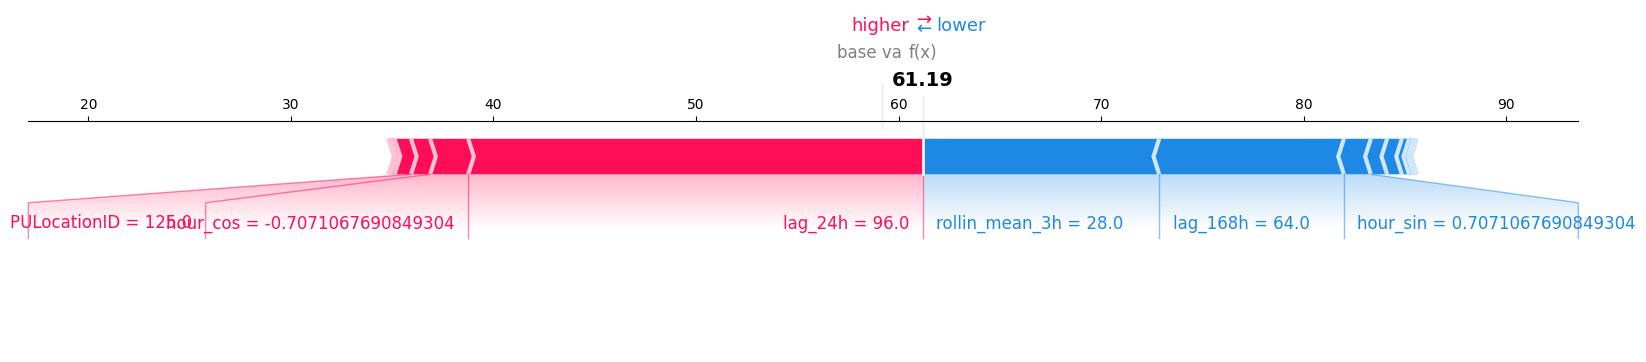

In [83]:
shap.force_plot(explainer.expected_value, shap_values[0].values, x_test_sampled.iloc[0, :], matplotlib=True)

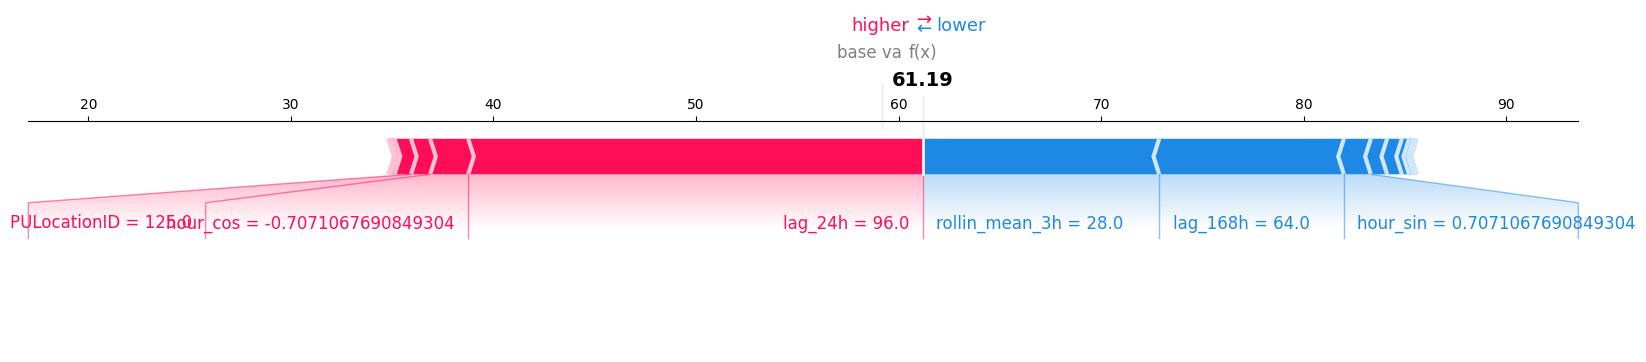

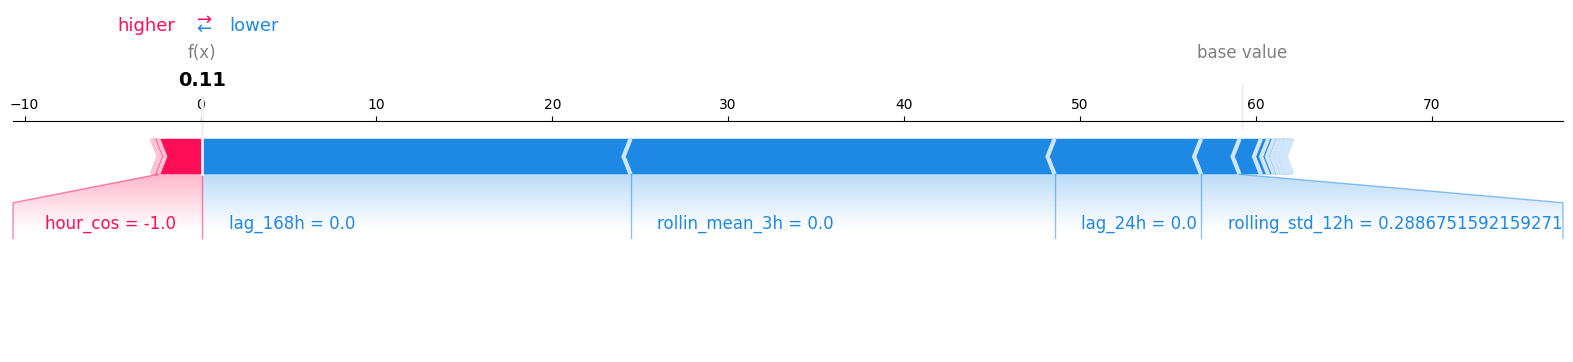

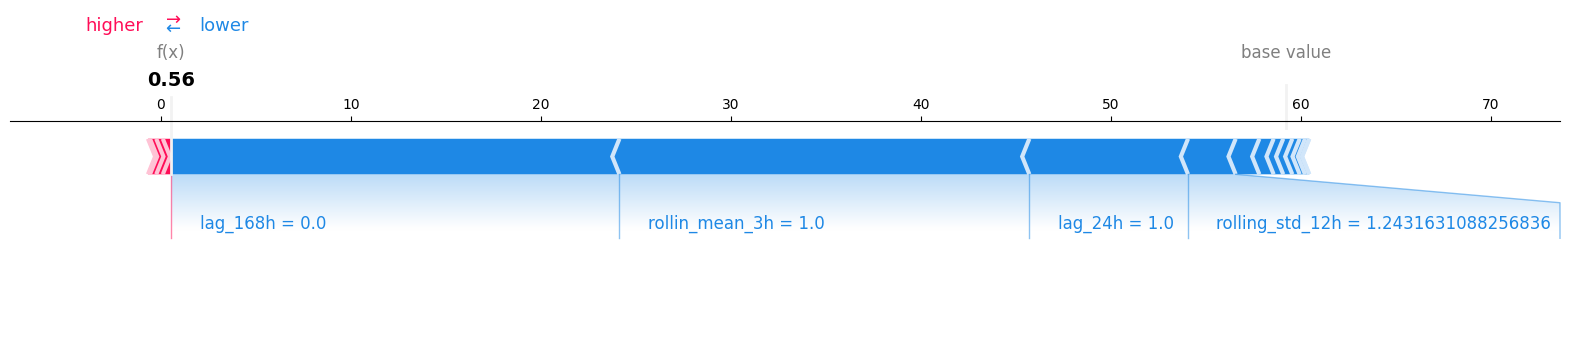

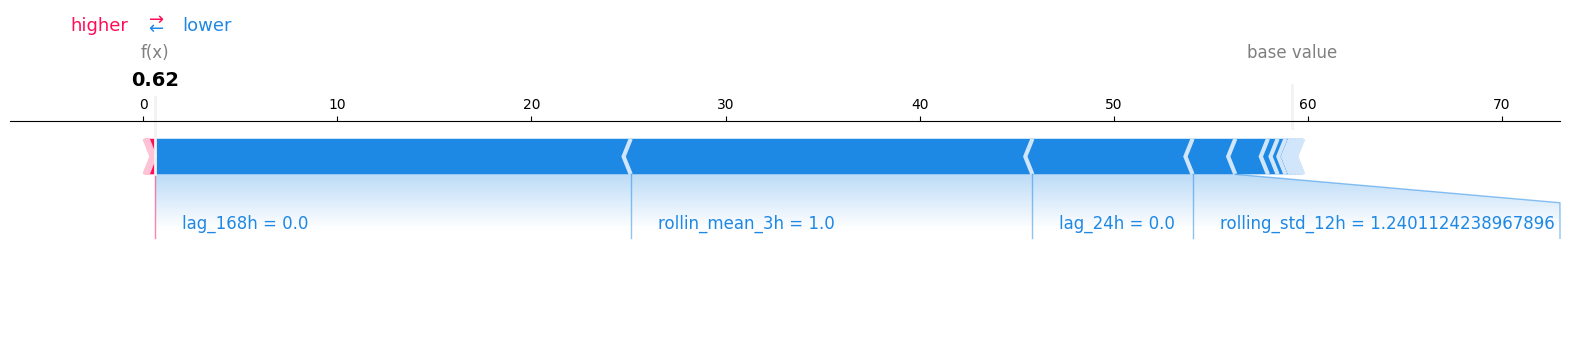

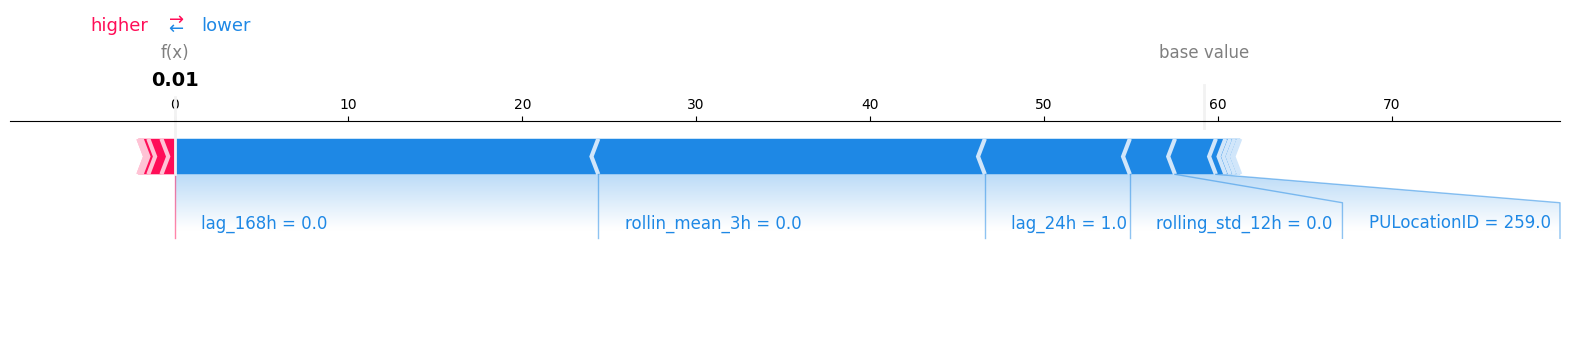

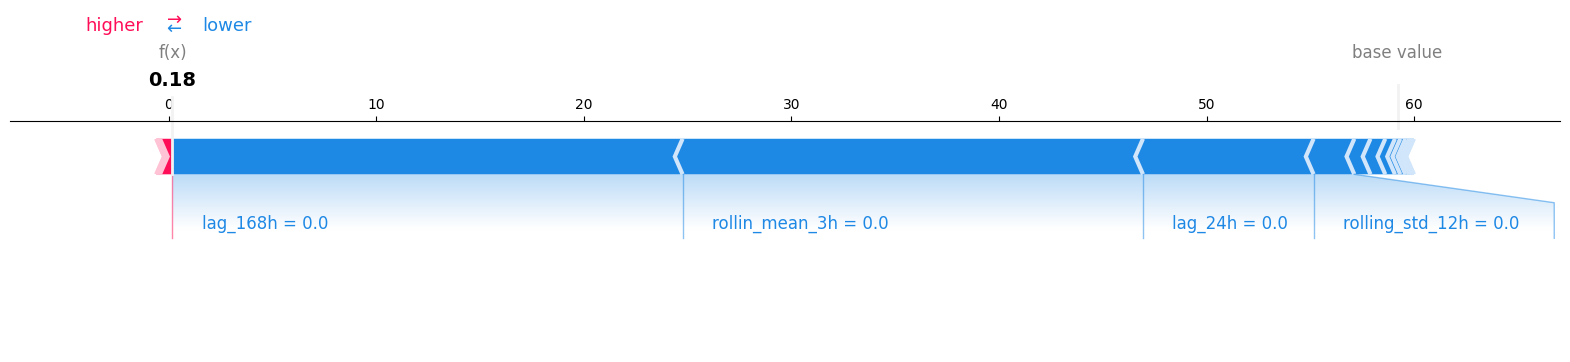

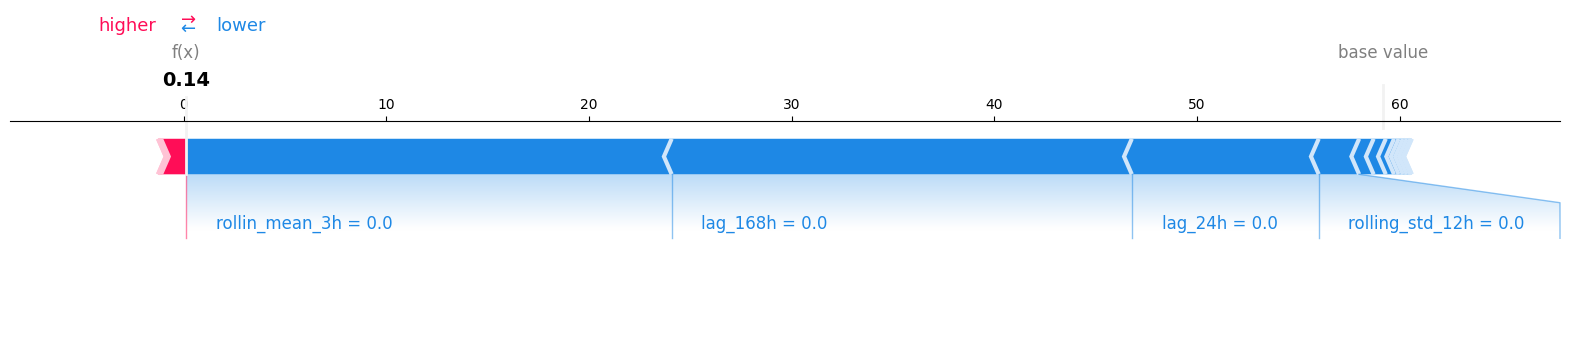

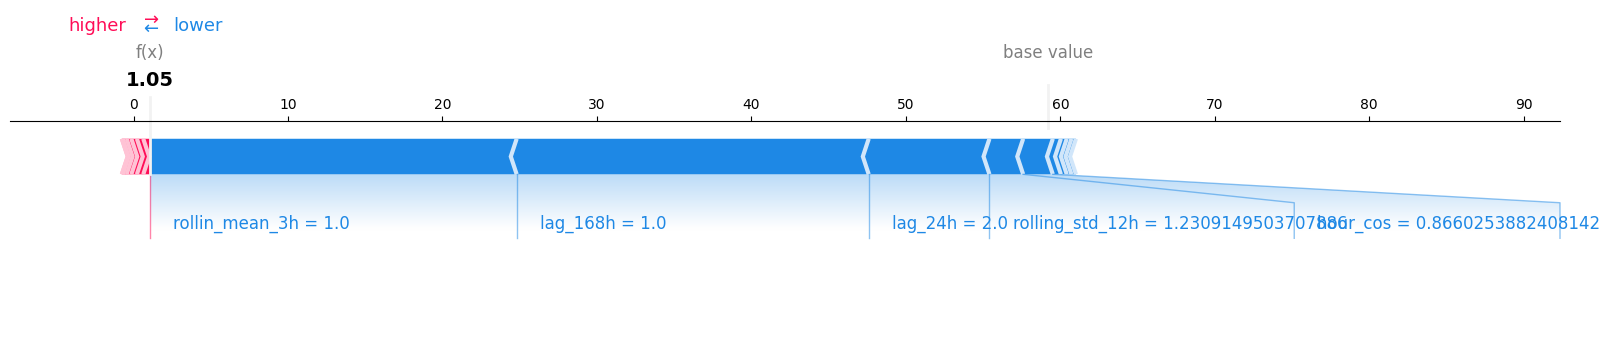

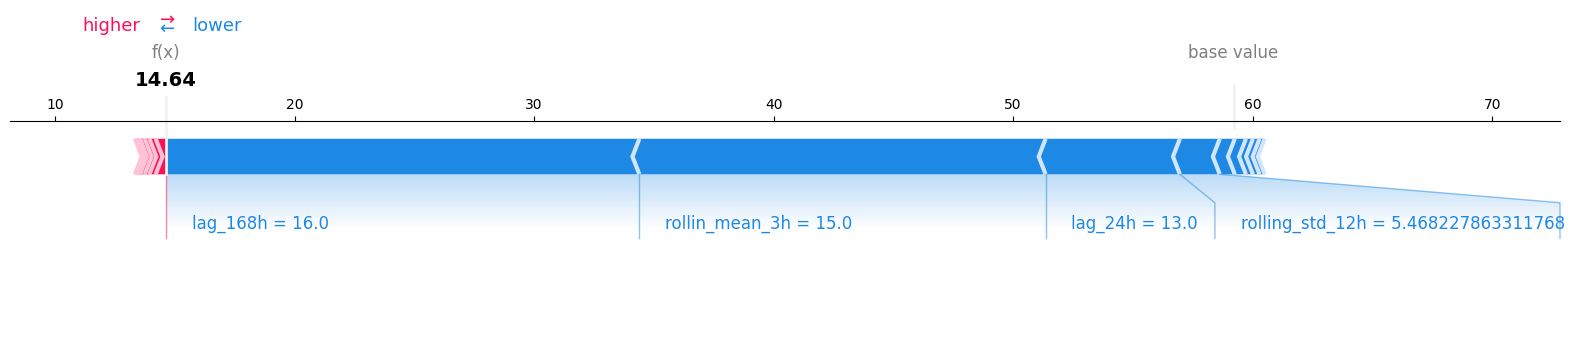

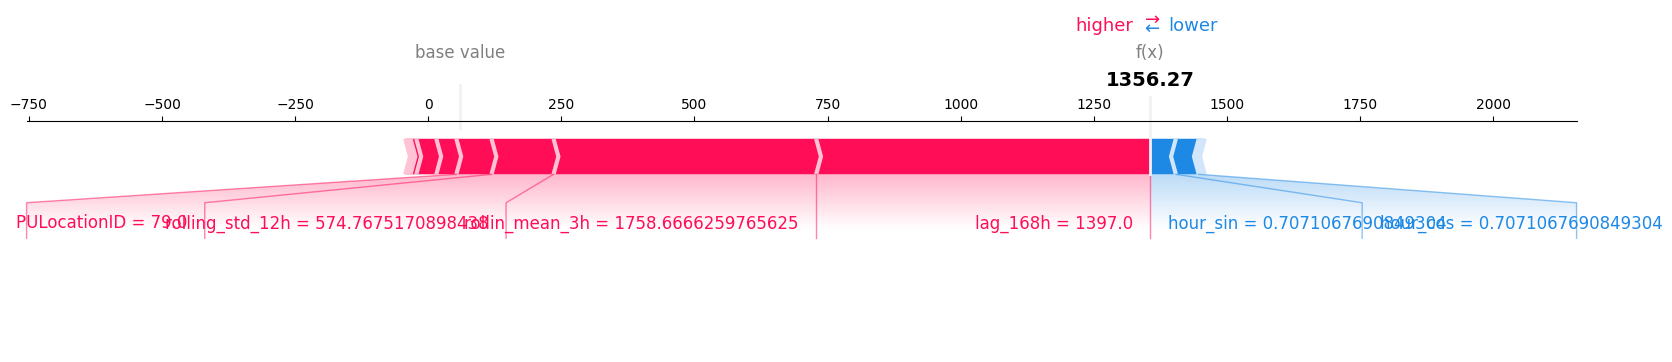

In [84]:
for i in range(10):
    shap.force_plot(explainer.expected_value, shap_values[i].values, x_test_sampled.iloc[i, :], matplotlib=True)

- summary plot

Gives a global view of feature importance and how values influence predictions.

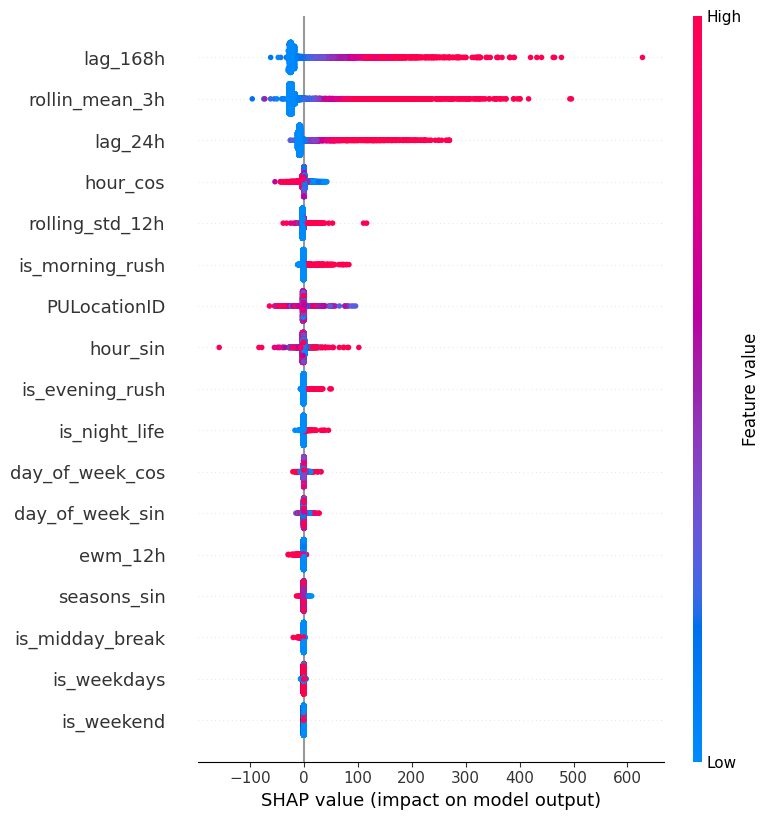

In [85]:
shap.summary_plot(shap_values, x_test_sampled)

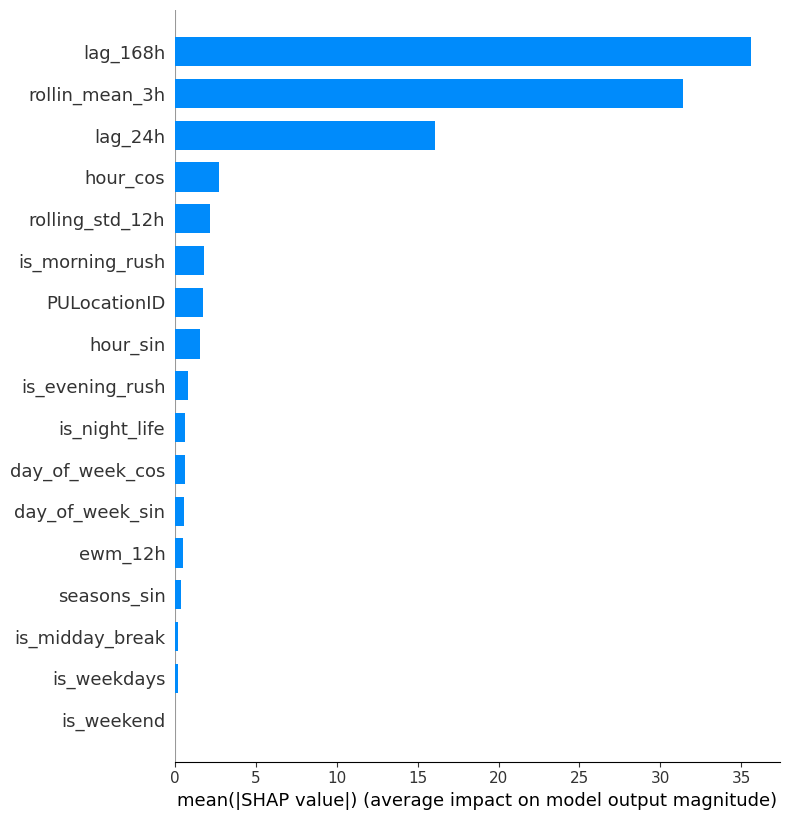

In [86]:
shap.summary_plot(shap_values, x_test_sampled, plot_type="bar")

### OptiLime

OptiLime, Lime'ın Bayesian Optimization kullanılmış halidir. En optimal "Kernel Width" bulabilmek için daha önce Optuna'da karşılaştığımız Bayesian Optimization kullanır. Amaç doğru kernel genişliğini ayarlayıp linear regression çizgisini doğru çizmektir.

Problem: PyPI tarafından onaylanmandığından ve hazır kullanılacak bir GitHub reposu olmadığından kullanamıyoruz :(

### LIME

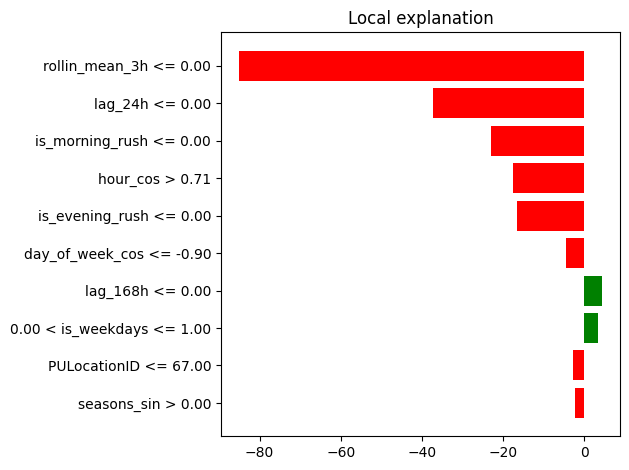

In [ ]:
import lime
import lime.lime_tabular

x_train = df[df["month_index"] <= 18][FEATURES].copy().astype("float32")

explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=x_train.values, # LIME train data görmek zorunda, rastgele nokta atıyor
    feature_names=FEATURES,
    mode='regression',
    kernel_width=1.5
)

exp = explainer_lime.explain_instance(
    data_row=x_test.iloc[0].values,     # ilk satır
    predict_fn=loaded_lgball_model.predict 
)

import matplotlib.pyplot as plt
fig = exp.as_pyplot_figure()
plt.tight_layout()
plt.show()

LIME, SHAP'a göre çok daha az tercih edilir ve kararlılığı çok daha düşüktür, kernel width genişliği sonucu değiştirdiğinden SHAP kadar adil değildir.

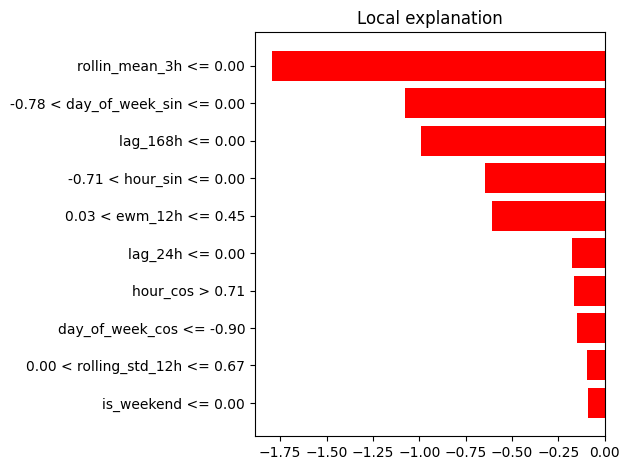

In [93]:
import lime
import lime.lime_tabular

x_train = df[df["month_index"] <= 18][FEATURES].copy().astype("float32")

explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=x_train.values, # LIME train data görmek zorunda, rastgele nokta atıyor
    feature_names=FEATURES,
    mode='regression',
    kernel_width=0.5
)

exp = explainer_lime.explain_instance(
    data_row=x_test.iloc[0].values, 
    predict_fn=loaded_lgball_model.predict 
)

import matplotlib.pyplot as plt
fig = exp.as_pyplot_figure()
plt.tight_layout()
plt.show()

kernel width plot ı çok etkiliyor, böyle bir durumda SHAP kadar güvenilir olamaz!

### Support Vector Machine

In [73]:
df

,pickup_hour,PULocationID,trip_count,hour,day_of_week,month,is_weekdays,is_weekend,is_working_hours,is_business_hour,...,month_sin,month_cos,seasons_sin,seasons_cos,rollin_mean_3h,rolling_std_12h,lag_24h,lag_168h,ewm_12h,month_index
0,2015-01-08 00:00:00,1,0,0,3,1,1,0,0,0,...,5.000000e-01,0.866025,-1.0,-1.836970e-16,0.000000,0.288675,0.0,0.0,0.076671,1
1,2015-01-08 01:00:00,1,0,1,3,1,1,0,0,0,...,5.000000e-01,0.866025,-1.0,-1.836970e-16,0.000000,0.288675,0.0,0.0,0.064875,1
2,2015-01-08 02:00:00,1,0,2,3,1,1,0,0,0,...,5.000000e-01,0.866025,-1.0,-1.836970e-16,0.000000,0.288675,0.0,0.0,0.054894,1
3,2015-01-08 03:00:00,1,0,3,3,1,1,0,0,0,...,5.000000e-01,0.866025,-1.0,-1.836970e-16,0.000000,0.288675,1.0,0.0,0.046449,1
4,2015-01-08 04:00:00,1,0,4,3,1,1,0,0,0,...,5.000000e-01,0.866025,-1.0,-1.836970e-16,0.000000,0.000000,0.0,0.0,0.039303,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4604635,2016-12-31 19:00:00,265,4,19,5,12,0,1,0,0,...,-2.449294e-16,1.000000,-1.0,-1.836970e-16,2.333333,1.055290,2.0,0.0,2.122501,24
4604636,2016-12-31 20:00:00,265,5,20,5,12,0,1,0,0,...,-2.449294e-16,1.000000,-1.0,-1.836970e-16,3.000000,1.087115,0.0,1.0,2.411347,24
4604637,2016-12-31 21:00:00,265,2,21,5,12,0,1,0,0,...,-2.449294e-16,1.000000,-1.0,-1.836970e-16,4.000000,1.240112,2.0,4.0,2.809601,24
4604638,2016-12-31 22:00:00,265,2,22,5,12,0,1,0,0,...,-2.449294e-16,1.000000,-1.0,-1.836970e-16,3.666667,1.240112,2.0,2.0,2.685047,24


In [ ]:
import numpy as np
import pandas as pd
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import make_scorer, mean_absolute_error
from sklearn.preprocessing import StandardScaler    # SVR sayıların büyüklüğünü önem derecesi gibi düşünebildiğinden önlem alacağım
from sklearn.pipeline import Pipeline   # StandardScaler ile SVR boru hattına girecek
from sklearnex import patch_sklearn
patch_sklearn() # Intel CPU Accelerator
scaler = StandardScaler()

FEATURES = ["is_weekdays", 
            "is_weekend", 
            "is_night_life", 
            "is_morning_rush", 
            "is_evening_rush", 
            "is_midday_break", 
            "hour_sin", 
            "hour_cos", 
            "day_of_week_sin", 
            "day_of_week_cos",
            "seasons_sin", 
            "lag_24h",
            "rolling_std_12h",
            "PULocationID",
            "rollin_mean_3h",
            "lag_168h",
            "ewm_12h"
            ]

TARGET = "trip_count"

df_sample = df[df["month_index"] == 10].head(5000).copy() # GPU kitlenmesin diye 4M satır içerisinden 5k satır seçeceğim.

x_tuning = df_sample[FEATURES].copy().astype("float32")
y_tuning = df_sample[TARGET].copy().astype("float32")

x_tuning["PULocationID"] = x_tuning["PULocationID"].astype("int32")
x_tuning.loc[x_tuning["PULocationID"] >= 250, "PULocationID"] = 250 # PULocation ID diğer training işlerinde de yaptığım gibi kategorik olmalı.
x_tuning = pd.get_dummies(x_tuning, columns=["PULocationID"], drop_first=True)  # One Hot Encoding
x_tuning = x_tuning.astype("float32")   # get_dummies işlemi olur da boolean döner diye float32 çevirmesi yapıyorum.

svr_model = SVR()   # support vector regression (machine)

pipe_line = Pipeline([  # data leakage önlemi
    ("scaler", StandardScaler()),
    ("svr", SVR())
])

# grid search tarafından kullanılacak grid
param_grid = {
    "svr__kernel": ["linear", "rbf", "poly"],
    "svr__C": [0.1, 1, 10],
    "svr__epsilon": [0.01, 0.1, 0.2]
}

tscv = TimeSeriesSplit(n_splits=3)  # zaman serisi

#! Grid Search verdiğimiz değişkenlere bağlı kalarak tüm kombinasyonları
#! dener ve bize en optimal sonucu döndürür.

grid_search = GridSearchCV(
    estimator=pipe_line,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    n_jobs=-1,  # Tüm CPU çekirdekleri kullanılacak
    verbose=2   # Gelişmeleri ekrana bas
)

print("GridSearchCV starts!")
grid_search.fit(x_tuning, y_tuning)

# Sonuç yazdırımı
print("=" * 50)
print(f"En iyi kernel ve parametreler: {grid_search.best_params_}")
print(f"Bu Parametrelerle Alinan En İyi CV MAE Skoru: {-grid_search.best_score_:.2f} Taksi")
print("=" * 50)

best_svr_model = grid_search.best_estimator_    # grid search sonucu en iyi model (kernel trick)

GridSearchCV starts!
Fitting 3 folds for each of 27 candidates, totalling 81 fits


Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


[CV] END ..svr__C=0.1, svr__epsilon=0.01, svr__kernel=linear; total time=   0.1s
[CV] END ...svr__C=0.1, svr__epsilon=0.1, svr__kernel=linear; total time=   0.1s
[CV] END .....svr__C=0.1, svr__epsilon=0.01, svr__kernel=rbf; total time=   0.2s
[CV] END ....svr__C=0.1, svr__epsilon=0.01, svr__kernel=poly; total time=   0.2s
[CV] END ......svr__C=0.1, svr__epsilon=0.1, svr__kernel=rbf; total time=   0.1s
[CV] END ...svr__C=0.1, svr__epsilon=0.1, svr__kernel=linear; total time=   0.3s
[CV] END ....svr__C=0.1, svr__epsilon=0.01, svr__kernel=poly; total time=   0.4s
[CV] END .....svr__C=0.1, svr__epsilon=0.1, svr__kernel=poly; total time=   0.1s
[CV] END ...svr__C=0.1, svr__epsilon=0.2, svr__kernel=linear; total time=   0.0s
[CV] END ......svr__C=0.1, svr__epsilon=0.1, svr__kernel=rbf; total time=   0.3s
[CV] END .....svr__C=0.1, svr__epsilon=0.01, svr__kernel=rbf; total time=   0.6s
[CV] END .....svr__C=0.1, svr__epsilon=0.1, svr__kernel=poly; total time=   0.3s
[CV] END ...svr__C=0.1, svr_

Şansımıza en iyi kernel trick "linear" model geldi. Bu yöntem diğerlerine göre daha hızlı çalışır.

In [76]:
df.columns

Index(['pickup_hour', 'PULocationID', 'trip_count', 'hour', 'day_of_week',
       'month', 'is_weekdays', 'is_weekend', 'is_working_hours',
       'is_business_hour', 'is_night_life', 'seasons', 'is_morning_rush',
       'is_evening_rush', 'is_midday_break', 'hour_sin', 'hour_cos',
       'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos',
       'seasons_sin', 'seasons_cos', 'rollin_mean_3h', 'rolling_std_12h',
       'lag_24h', 'lag_168h', 'ewm_12h', 'month_index'],
      dtype='object')

### Final Training with SVR

In [73]:
df_swm = df.copy()
df_swm["PULocationID"] = df_swm["PULocationID"].astype("int32") # categoric
df_swm.loc[df_swm["PULocationID"] >= 250, "PULocationID"] = 250 
df_swm = pd.get_dummies(df_swm, columns=["PULocationID"], drop_first=True)  # One Hot Encoding

#! eğer get_dummies bir yerde boolean döndü ise onu float32 yapmalıyım
for column in df_swm.columns:
    if df_swm[column].dtype == "bool":
        df_swm[column] = df_swm[column].astype("float32")

In [78]:
df_swm

,pickup_hour,trip_count,hour,day_of_week,month,is_weekdays,is_weekend,is_working_hours,is_business_hour,is_night_life,...,PULocationID_241,PULocationID_242,PULocationID_243,PULocationID_244,PULocationID_245,PULocationID_246,PULocationID_247,PULocationID_248,PULocationID_249,PULocationID_250
0,2015-01-08 00:00:00,0,0,3,1,1,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2015-01-08 01:00:00,0,1,3,1,1,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2015-01-08 02:00:00,0,2,3,1,1,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2015-01-08 03:00:00,0,3,3,1,1,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2015-01-08 04:00:00,0,4,3,1,1,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4604635,2016-12-31 19:00:00,4,19,5,12,0,1,0,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4604636,2016-12-31 20:00:00,5,20,5,12,0,1,0,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4604637,2016-12-31 21:00:00,2,21,5,12,0,1,0,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4604638,2016-12-31 22:00:00,2,22,5,12,0,1,0,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [79]:
df_swm.columns

Index(['pickup_hour', 'trip_count', 'hour', 'day_of_week', 'month',
       'is_weekdays', 'is_weekend', 'is_working_hours', 'is_business_hour',
       'is_night_life',
       ...
       'PULocationID_241', 'PULocationID_242', 'PULocationID_243',
       'PULocationID_244', 'PULocationID_245', 'PULocationID_246',
       'PULocationID_247', 'PULocationID_248', 'PULocationID_249',
       'PULocationID_250'],
      dtype='object', length=277)

In [86]:
df.columns

Index(['pickup_hour', 'PULocationID', 'trip_count', 'hour', 'day_of_week',
       'month', 'is_weekdays', 'is_weekend', 'is_working_hours',
       'is_business_hour', 'is_night_life', 'seasons', 'is_morning_rush',
       'is_evening_rush', 'is_midday_break', 'hour_sin', 'hour_cos',
       'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos',
       'seasons_sin', 'seasons_cos', 'rollin_mean_3h', 'rolling_std_12h',
       'lag_24h', 'lag_168h', 'ewm_12h', 'month_index'],
      dtype='object')

In [88]:
len(df.columns)

29

In [74]:
others = ["pickup_hour", "PULocationID", "trip_count", "hour", "day_of_week",
          "month", "seasons", "month_sin", "month_cos", "month_index", "seasons_cos", "is_working_hours"]

len(others)

12

In [75]:
SVR_FEATURES = []

for column in df_swm.columns:
    if not column in others:
        SVR_FEATURES.append(column)

SVR_FEATURES

['is_weekdays',
 'is_weekend',
 'is_business_hour',
 'is_night_life',
 'is_morning_rush',
 'is_evening_rush',
 'is_midday_break',
 'hour_sin',
 'hour_cos',
 'day_of_week_sin',
 'day_of_week_cos',
 'seasons_sin',
 'rollin_mean_3h',
 'rolling_std_12h',
 'lag_24h',
 'lag_168h',
 'ewm_12h',
 'PULocationID_2',
 'PULocationID_3',
 'PULocationID_4',
 'PULocationID_5',
 'PULocationID_6',
 'PULocationID_7',
 'PULocationID_8',
 'PULocationID_9',
 'PULocationID_10',
 'PULocationID_11',
 'PULocationID_12',
 'PULocationID_13',
 'PULocationID_14',
 'PULocationID_15',
 'PULocationID_16',
 'PULocationID_17',
 'PULocationID_18',
 'PULocationID_19',
 'PULocationID_20',
 'PULocationID_21',
 'PULocationID_22',
 'PULocationID_23',
 'PULocationID_24',
 'PULocationID_25',
 'PULocationID_26',
 'PULocationID_27',
 'PULocationID_28',
 'PULocationID_29',
 'PULocationID_30',
 'PULocationID_31',
 'PULocationID_32',
 'PULocationID_33',
 'PULocationID_34',
 'PULocationID_35',
 'PULocationID_36',
 'PULocationID_37',


In [ ]:
import gc  # Garbage Collector (Çöp Toplayıcı) kütüphanesi
from sklearn.svm import LinearSVR
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
import numpy as np
import pandas as pd

from sklearnex import patch_sklearn
# patch_sklearn() # Intel CPU Accelerator   # RAM tüketiyor

FEATURES = ["is_weekdays", 
            "is_weekend", 
            "is_night_life", 
            "is_morning_rush", 
            "is_evening_rush", 
            "is_midday_break", 
            "hour_sin", 
            "hour_cos", 
            "day_of_week_sin", 
            "day_of_week_cos",
            "seasons_sin", 
            "lag_24h",
            "rolling_std_12h",
            "PULocation_encoded",   #!
            "rollin_mean_3h",
            "lag_168h",
            "ewm_12h"
            ]

TARGET = "trip_count"

svr_mae = []
all_predictions = []    
all_real_values = []    

for last_month_index in range(21, 24):
    train_set = df[df["month_index"] <= last_month_index].copy()

    if (len(train_set) > 500000):
        train_set = train_set.sample(n=500000, random_state=42) # RAM Optimization

    test_set = df[df["month_index"] == last_month_index + 1].copy()

    #*   TARGET ENCODING
    location_means = train_set.groupby("PULocationID")[TARGET].mean()   # her location için ortalama değeri tutan array
    train_set["PULocation_encoded"] = train_set["PULocationID"].map(location_means)
    test_set["PULocation_encoded"] = test_set["PULocationID"].map(location_means)
    test_set["PULocation_encoded"] = test_set["PULocation_encoded"].fillna(train_set[TARGET].mean())    # eğer test setinde train setinde karşılaştığımız bir veri yoksa orayı genel ortalama ile doldur.
    train_set.drop('PULocationID', axis=1, inplace=True)    # PULocationID görevi bitti
    test_set.drop('PULocationID', axis=1, inplace=True)
    #*  TARGET ENCODING

    x_train = train_set[FEATURES].astype("float32")
    y_train = train_set[TARGET].astype("float32")

    x_test = test_set[FEATURES].astype("float32")
    y_test = test_set[TARGET].astype("float32")

    # X ve Y'leri ayırdık, artık o ağır train_set ve test_set'e ihtiyacımız yok!
    del train_set, test_set
    gc.collect()

    scaler = StandardScaler(copy=False) #!
    
    # Aşağıdaki işlem x_train'in üzerine yazar (x_train_scaled diye yeni değişken atamamıza gerek kalmadı)
    scaler.fit_transform(x_train) 
    scaler.transform(x_test)      

    #! önceki gridsearch sayesinde bulduğum modeli kullanacağım
    svr_model_final_training = LinearSVR(C=1, epsilon=0.01, max_iter=10000, random_state=42)

    print(f"{last_month_index + 1}. ay için training...")
    
    # x_train artık kendi içinde scale edilmiş durumda
    svr_model_final_training.fit(x_train, y_train)

    current_estimations = svr_model_final_training.predict(x_test)
    current_estimations[current_estimations < 0] = 0    

    mistake = mean_absolute_error(y_test, current_estimations)
    svr_mae.append(mistake)
    all_predictions.extend(current_estimations)
    all_real_values.extend(y_test.values)

    print(f"{last_month_index + 1}. ay için MAE skoru: {mistake:.2f} Taksi.")

    # DÖNGÜ SONU TEMİZLİĞİ: Bu aya ait tüm ağır değişkenleri silip yeni aya taze bir RAM ile giriyoruz.
    del x_train, y_train, x_test, y_test, svr_model_final_training, scaler, current_estimations
    gc.collect()

print("=" * 50)
print(f"Tüm ayların ortalama hatası: {np.mean(svr_mae):.2f} Taksi")

predictions_svr = np.array(all_predictions)
real_values_svr = np.array(all_real_values)

print(f"Model tahminleri predictions_all içersinde (Toplam {len(predictions_svr)} satır veri korundu!)")

22. ay için training...


/home/tahas44/Desktop/NYC-Taxi/.venv/lib64/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


22. ay için MAE skoru: 7.39 Taksi.
23. ay için training...


/home/tahas44/Desktop/NYC-Taxi/.venv/lib64/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


23. ay için MAE skoru: 9.38 Taksi.
24. ay için training...
24. ay için MAE skoru: 10.54 Taksi.
Tüm ayların ortalama hatası: 9.11 Taksi
Model tahminleri predictions_all içersinde (Toplam 585120 satır veri korundu!)


/home/tahas44/Desktop/NYC-Taxi/.venv/lib64/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [74]:
np.std(svr_mae) #! STANDART SAPMA

np.float64(1.2994349509728376)

In [76]:
numerator = np.sum(np.abs(real_values_svr - predictions_svr))
denominator = np.sum(np.abs(real_values_svr))

WAPE = numerator / denominator
print(f"WAPE score for svr is: %{WAPE * 100}")

WAPE score for svr is: %17.223089283987576


In [78]:
from sklearn.metrics import root_mean_squared_error
print(f"svr RMSE: {root_mean_squared_error(real_values_svr, predictions_svr)}")   #* RMSE

svr RMSE: 30.64735555671316


In [79]:
from sklearn.metrics import r2_score
print(f"all R^2: {r2_score(real_values_svr, predictions_svr)}")   #* R^2

all R^2: 0.9533965856771046


In [ ]:
scatter_plot(real_values_svr, predictions_svr)

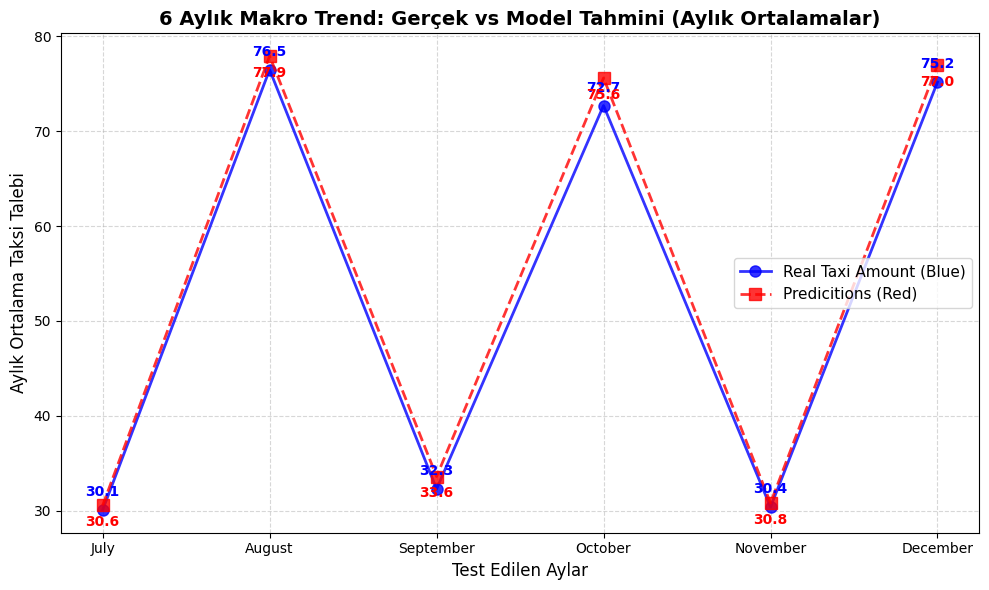

In [85]:
real_vs_prediction_plot(real_values_svr, predictions_svr)

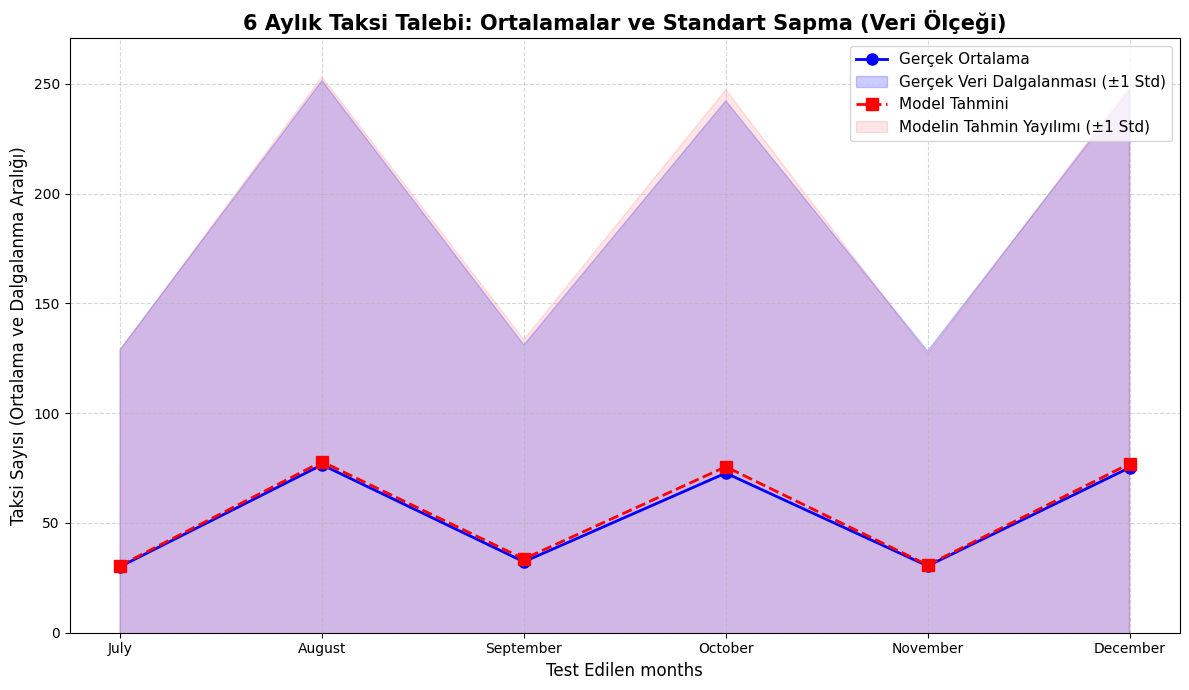

6 AYLIK VERİ ÖLÇEĞİ VE STANDART SAPMA ANALİZİ: REAL
July: Ortalama 30.1 Taksi | Standart Sapma: ±98.9 Taksi
August: Ortalama 76.5 Taksi | Standart Sapma: ±174.9 Taksi
September: Ortalama 32.3 Taksi | Standart Sapma: ±98.7 Taksi
October: Ortalama 72.7 Taksi | Standart Sapma: ±169.5 Taksi
November: Ortalama 30.4 Taksi | Standart Sapma: ±97.9 Taksi
December: Ortalama 75.2 Taksi | Standart Sapma: ±172.0 Taksi
6 AYLIK VERİ ÖLÇEĞİ VE STANDART SAPMA ANALİZİ: PREDICTED
July: Ortalama 30.6 Taksi | Standart Sapma: ±98.1 Taksi
August: Ortalama 77.9 Taksi | Standart Sapma: ±175.2 Taksi
September: Ortalama 33.6 Taksi | Standart Sapma: ±99.9 Taksi
October: Ortalama 75.6 Taksi | Standart Sapma: ±171.7 Taksi
November: Ortalama 30.8 Taksi | Standart Sapma: ±96.1 Taksi
December: Ortalama 77.0 Taksi | Standart Sapma: ±171.8 Taksi


In [88]:
real_vs_prediction_stdPlot(real_values_svr, predictions_svr)

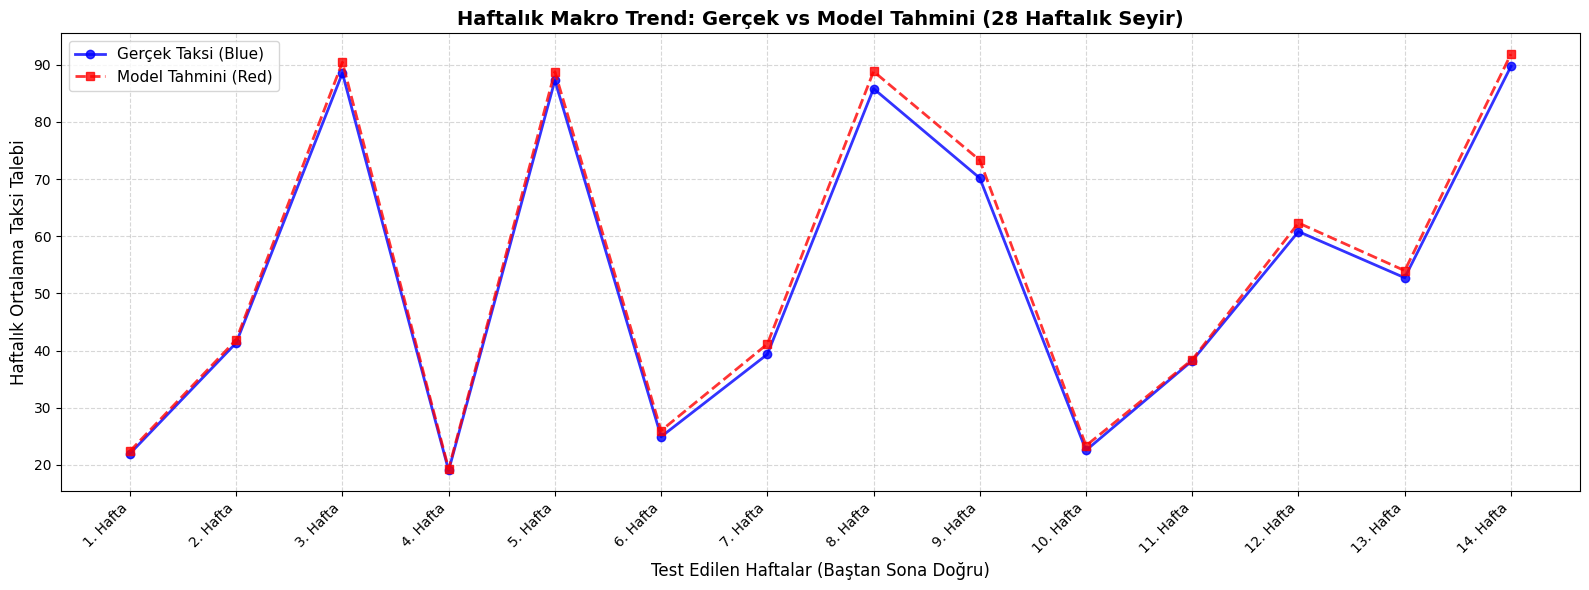

In [91]:
weekly_trend_plot(real_values_svr, predictions_svr)

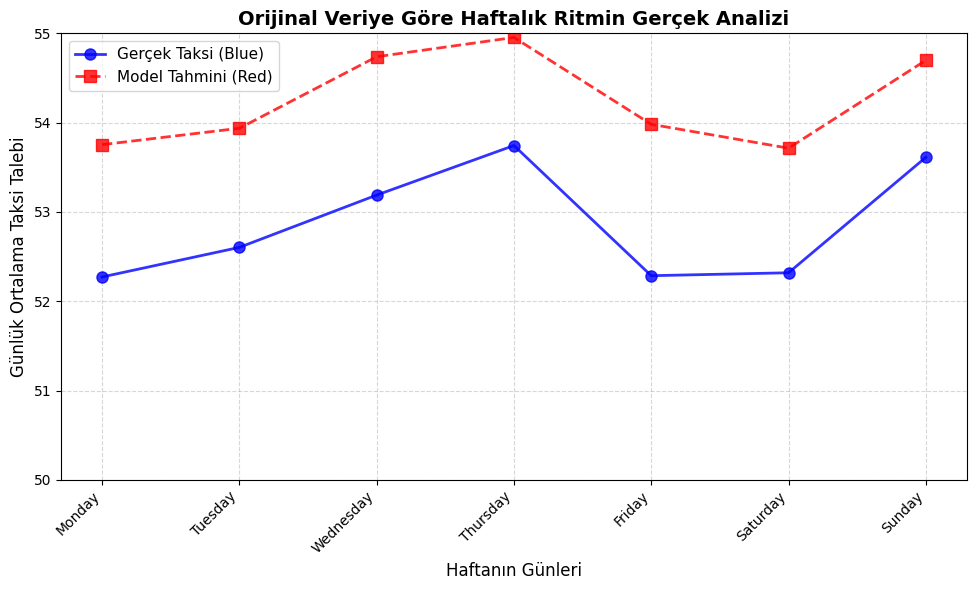

In [96]:
x_test = df[df["month_index"] > 21]
bulletproof_daily_trend(x_test ,real_values_svr, predictions_svr)

### Principal Component Anlaysis

copy
bool, default=True
If False, try to avoid a copy and do inplace scaling instead. This is not guaranteed to always work inplace; e.g. if the data is not a NumPy array or scipy.sparse CSR matrix, a copy may still be returned.
- copy=False

In [73]:
import gc  # Garbage Collector (Çöp Toplayıcı) kütüphanesi
from sklearn.svm import LinearSVR
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
import numpy as np
import pandas as pd

from sklearnex import patch_sklearn
# patch_sklearn() # Intel CPU Accelerator   # RAM tüketiyor

FEATURES = ["is_weekdays", 
            "is_weekend", 
            "is_night_life", 
            "is_morning_rush", 
            "is_evening_rush", 
            "is_midday_break", 
            "hour_sin", 
            "hour_cos", 
            "day_of_week_sin", 
            "day_of_week_cos",
            "seasons_sin", 
            "lag_24h",
            "rolling_std_12h",
            "PULocation_encoded",   #!
            "rollin_mean_3h",
            "lag_168h",
            "ewm_12h"
            ]

TARGET = "trip_count"

svr_mae = []
all_predictions = []    
all_real_values = []    

for last_month_index in range(21, 24):
    train_set = df[df["month_index"] <= last_month_index].copy()

    if (len(train_set) > 500000):
        train_set = train_set.sample(n=500000, random_state=42) # RAM Optimization

    test_set = df[df["month_index"] == last_month_index + 1].copy()

    #*   TARGET ENCODING
    location_means = train_set.groupby("PULocationID")[TARGET].mean()   # her location için ortalama değeri tutan array
    train_set["PULocation_encoded"] = train_set["PULocationID"].map(location_means)
    test_set["PULocation_encoded"] = test_set["PULocationID"].map(location_means)
    test_set["PULocation_encoded"] = test_set["PULocation_encoded"].fillna(train_set[TARGET].mean())    # eğer test setinde train setinde karşılaştığımız bir veri yoksa orayı genel ortalama ile doldur.
    train_set.drop('PULocationID', axis=1, inplace=True)    # PULocationID görevi bitti
    test_set.drop('PULocationID', axis=1, inplace=True)
    #*  TARGET ENCODING

    x_train = train_set[FEATURES].astype("float32")
    y_train = train_set[TARGET].astype("float32")

    x_test = test_set[FEATURES].astype("float32")
    y_test = test_set[TARGET].astype("float32")

    # X ve Y'leri ayırdık, artık o ağır train_set ve test_set'e ihtiyacımız yok!
    del train_set, test_set
    gc.collect()

    scaler = StandardScaler(copy=False) #! pandas serileri numpy array kullandığından çalışabilir
    
    # Aşağıdaki işlem x_train'in üzerine yazar (x_train_scaled diye yeni değişken atamamıza gerek kalmadı)
    scaler.fit_transform(x_train) 
    scaler.transform(x_test)   

    #! PRINCIPAL COMPONENT ANALYSIS
    from sklearn.decomposition import PCA
    print("PCA starts...")
    pca = PCA(n_components=0.95, random_state=42)   # verimin %95'ini koruyarak bana min sütun sayısını ver
    x_train_pca = pca.fit_transform(x_train).astype("float32")  # RAM'in şişmesini önlemek için!
    x_test_pca = pca.transform(x_test).astype("float32")
    print(f"Sütun sayısı {x_train.shape[1]} dan {x_train_pca.shape[1]} e düştü.")   

    del x_train, x_test
    gc.collect()    # elimizde yeni sıkıştırılmış veri var eskisini sileriz.

    #! önceki gridsearch sayesinde bulduğum modeli kullanacağım
    svr_model_final_training = LinearSVR(C=1, epsilon=0.01, max_iter=10000, random_state=42)

    print(f"{last_month_index + 1}. ay için training...")
    svr_model_final_training.fit(x_train_pca, y_train)

    current_estimations = svr_model_final_training.predict(x_test_pca)
    current_estimations[current_estimations < 0] = 0    

    mistake = mean_absolute_error(y_test, current_estimations)
    svr_mae.append(mistake)
    all_predictions.extend(current_estimations)
    all_real_values.extend(y_test.values)

    print(f"{last_month_index + 1}. ay için MAE skoru: {mistake:.2f} Taksi.")

    # DÖNGÜ SONU TEMİZLİĞİ: Bu aya ait tüm ağır değişkenleri silip yeni aya taze bir RAM ile giriyoruz.
    del x_train_pca, y_train, x_test_pca, y_test, svr_model_final_training, scaler, current_estimations
    gc.collect()

print("=" * 50)
print(f"Tüm ayların ortalama hatası: {np.mean(svr_mae):.2f} Taksi")

predictions_svr = np.array(all_predictions)
real_values_svr = np.array(all_real_values)

print(f"Model tahminleri predictions_all içersinde (Toplam {len(predictions_svr)} satır veri korundu!)")

PCA starts...
Sütun sayısı 17 dan 3 e düştü.
22. ay için training...


/home/tahas44/Desktop/NYC-Taxi/.venv/lib64/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


22. ay için MAE skoru: 8.77 Taksi.
PCA starts...
Sütun sayısı 17 dan 3 e düştü.
23. ay için training...


/home/tahas44/Desktop/NYC-Taxi/.venv/lib64/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


23. ay için MAE skoru: 9.46 Taksi.
PCA starts...
Sütun sayısı 17 dan 3 e düştü.
24. ay için training...
24. ay için MAE skoru: 9.89 Taksi.
Tüm ayların ortalama hatası: 9.37 Taksi
Model tahminleri predictions_all içersinde (Toplam 585120 satır veri korundu!)


/home/tahas44/Desktop/NYC-Taxi/.venv/lib64/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [97]:
type(x_train["PULocationID"])

pandas.core.series.Series

In [75]:
np.std(svr_mae) #! STANDART SAPMA

np.float64(0.46001725464603815)

In [76]:
numerator = np.sum(np.abs(real_values_svr - predictions_svr))
denominator = np.sum(np.abs(real_values_svr))

WAPE = numerator / denominator
print(f"WAPE score for svr is: %{WAPE * 100}")

WAPE score for svr is: %17.73184582754741


In [77]:
from sklearn.metrics import root_mean_squared_error
print(f"svr RMSE: {root_mean_squared_error(real_values_svr, predictions_svr)}")   #* RMSE

svr RMSE: 31.831230114205482


In [78]:
from sklearn.metrics import r2_score
print(f"all R^2: {r2_score(real_values_svr, predictions_svr)}")   #* R^2

all R^2: 0.9497265642559206


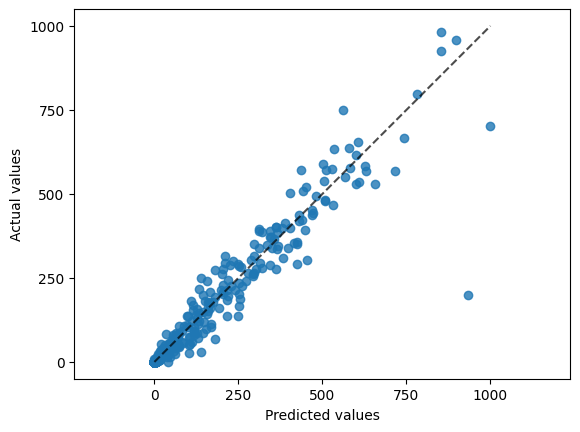

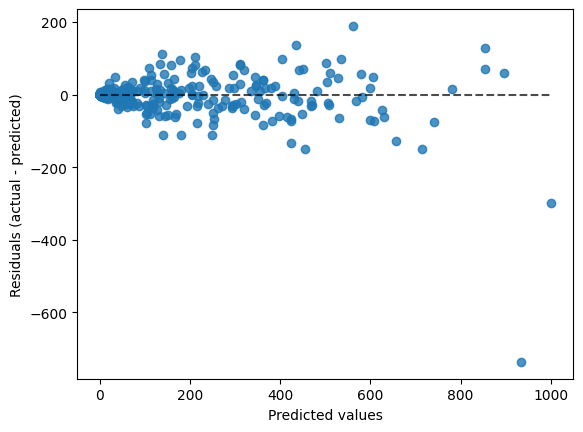

In [82]:
scatter_plot(real_values_svr, predictions_svr)

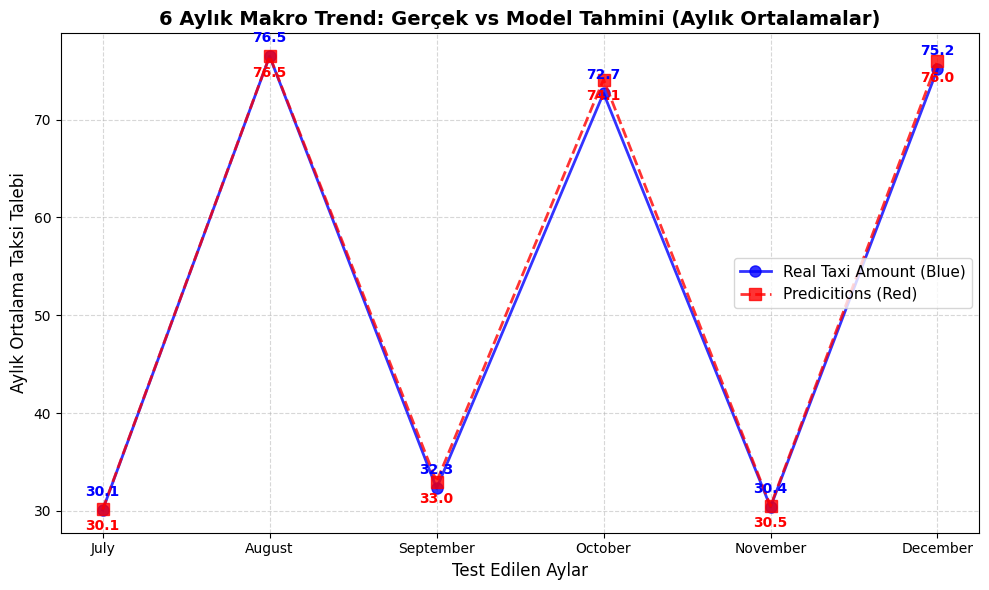

In [84]:
real_vs_prediction_plot(real_values_svr, predictions_svr)

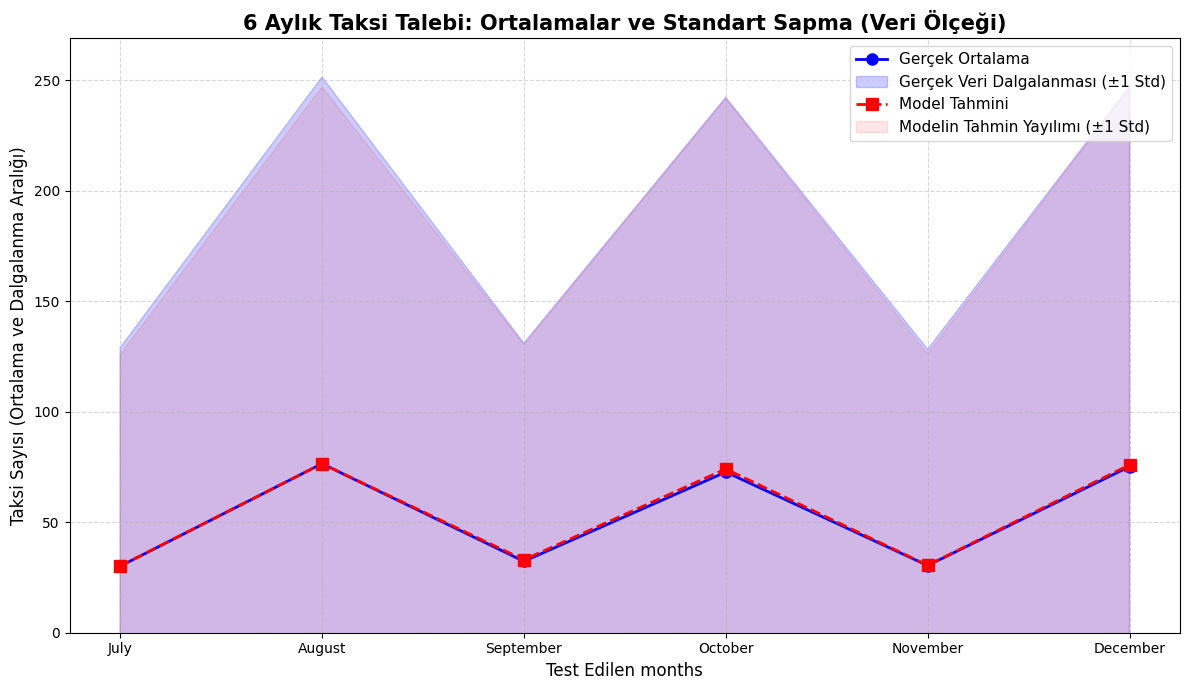

6 AYLIK VERİ ÖLÇEĞİ VE STANDART SAPMA ANALİZİ: REAL
July: Ortalama 30.1 Taksi | Standart Sapma: ±98.9 Taksi
August: Ortalama 76.5 Taksi | Standart Sapma: ±174.9 Taksi
September: Ortalama 32.3 Taksi | Standart Sapma: ±98.7 Taksi
October: Ortalama 72.7 Taksi | Standart Sapma: ±169.5 Taksi
November: Ortalama 30.4 Taksi | Standart Sapma: ±97.9 Taksi
December: Ortalama 75.2 Taksi | Standart Sapma: ±172.0 Taksi
6 AYLIK VERİ ÖLÇEĞİ VE STANDART SAPMA ANALİZİ: PREDICTED
July: Ortalama 30.1 Taksi | Standart Sapma: ±95.7 Taksi
August: Ortalama 76.5 Taksi | Standart Sapma: ±170.5 Taksi
September: Ortalama 33.0 Taksi | Standart Sapma: ±97.4 Taksi
October: Ortalama 74.1 Taksi | Standart Sapma: ±167.6 Taksi
November: Ortalama 30.5 Taksi | Standart Sapma: ±95.7 Taksi
December: Ortalama 76.0 Taksi | Standart Sapma: ±170.9 Taksi


In [87]:
real_vs_prediction_stdPlot(real_values_svr, predictions_svr)

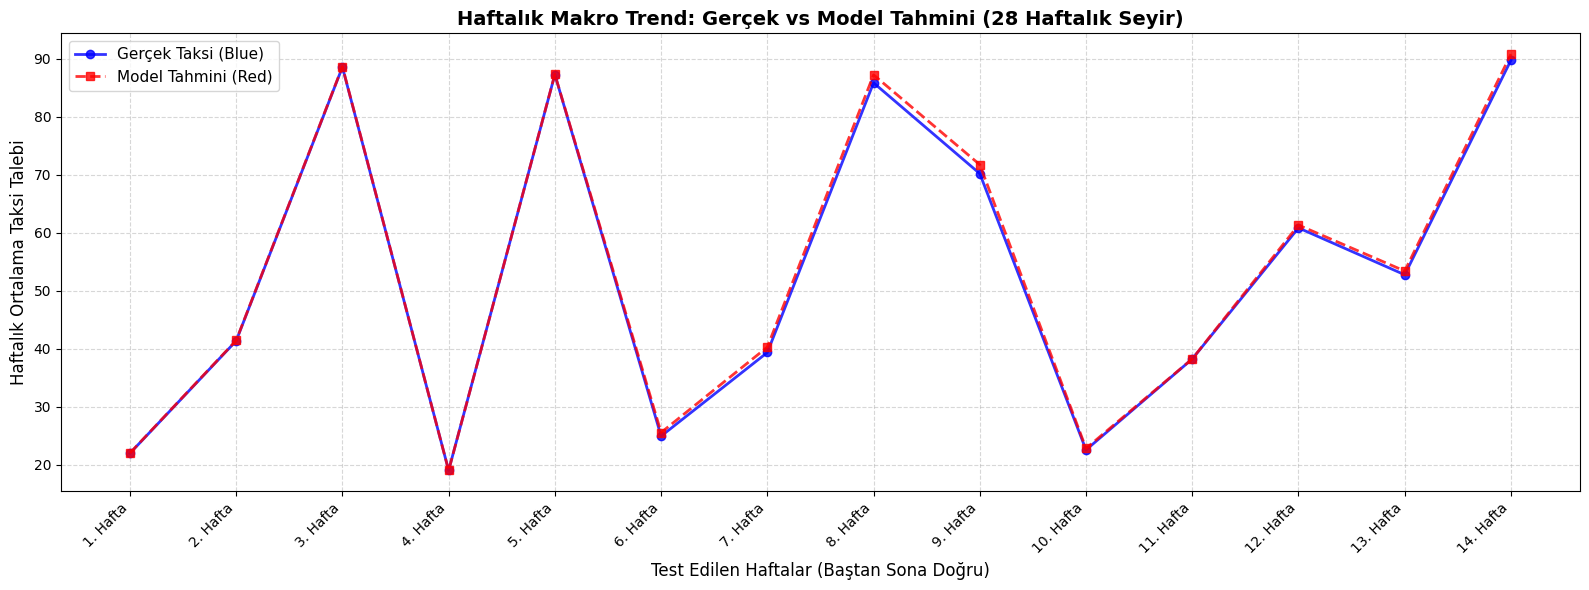

In [89]:
weekly_trend_plot(real_values_svr, predictions_svr)

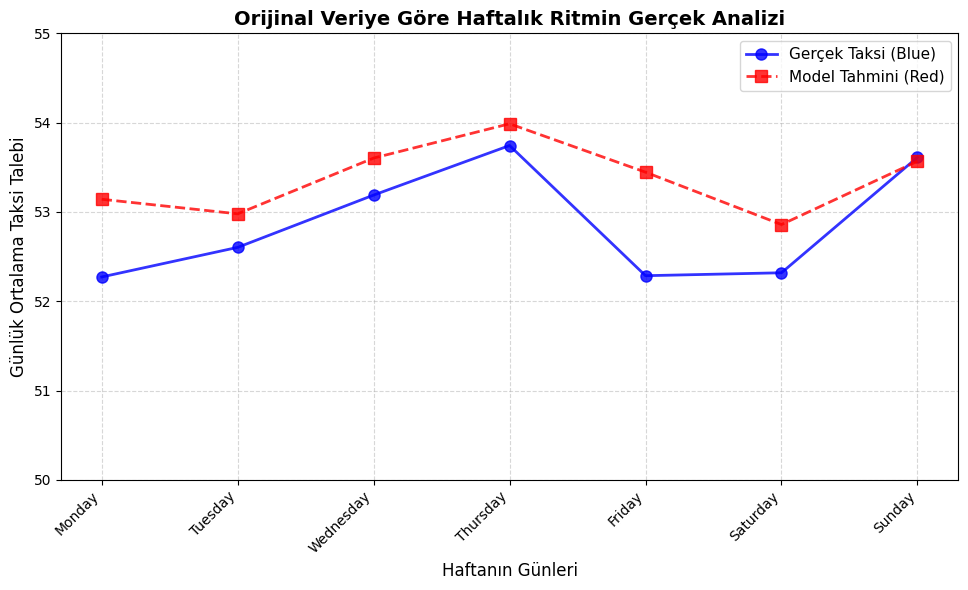

In [91]:
x_test = df[df["month_index"] > 21]
bulletproof_daily_trend(x_test ,real_values_svr, predictions_svr)